In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import ast
from networkx.algorithms import bipartite
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import spearmanr
from scipy.interpolate import UnivariateSpline

from utils import train_generator, generate_synthetic, projected_graph_custom, bipartite_graph, bipartite_projection, weighted_episode_rating, parse_list, plot_distribution, plot_rating_vs_metric, plot_metric_vs_metric


Primero se genera el grafo bipartito con 2 conjuntos, personas y episodios. Un link entre una persona y episodio existe solo si esta trabajo en la produccion del capitulo.

In [3]:
df = pd.read_csv("datasets/one_piece_merged.csv")
B = bipartite_graph(df)

Number of nodes: 1385, Number of edges: 5193


# Metricas y gráficos usando el grafo bipartito base

Componente gigante conexa

In [4]:
# Componentes conectadas

components = list(nx.connected_components(B))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)

Gcc = B.subgraph(largest_component).copy()

print("\nGiant Component")
print(f"Nodos: {Gcc.number_of_nodes()}")
print(f"Aristas: {Gcc.number_of_edges()}")

Componentes conectadas
Número de componentes: 1
Tamaño componente más grande: 1385

Giant Component
Nodos: 1385
Aristas: 5193


In [5]:
avg_path_length = nx.average_shortest_path_length(Gcc)

print("\nLargo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")


Largo de camino característico
Average shortest path length: 3.5634


Clustering coefficient
Average clustering coefficient: 0.0000
Top 10 clustering
ep_1: 0.0000
Junki Takegami: 0.0000
Tomoko Yoshida: 0.0000
Kazuya Hisada: 0.0000
Kōnosuke Uda: 0.0000
ep_2: 0.0000
Michiru Shimada: 0.0000
Miyuki Sato: 0.0000
Eisaku Inoue: 0.0000
Tetsuji Nakamura: 0.0000


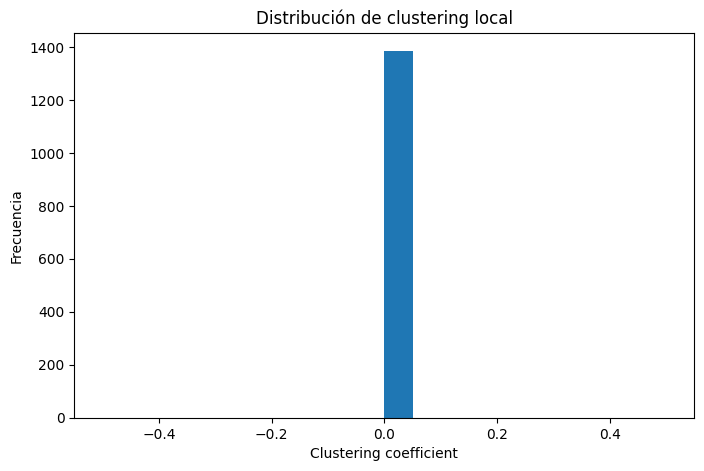

In [6]:
# Coeficiente de clustering

avg_clustering = nx.average_clustering(Gcc)

print("Clustering coefficient")
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# Clustering por nodo

clustering_per_node = nx.clustering(Gcc)

# top 10 directores
top_clustering = sorted(
    clustering_per_node.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 clustering")

for node, coeff in top_clustering:

    director_name = node.replace("director_", "")

    print(f"{director_name}: {coeff:.4f}")

# Distribucion

clustering_values = list(clustering_per_node.values())

plt.figure(figsize=(8,5))

plt.hist(clustering_values, bins=20)

plt.xlabel("Clustering coefficient")
plt.ylabel("Frecuencia")
plt.title("Distribución de clustering local")

plt.show()


Promedio de Degree Centrality por intervalos de rating de 0.5:
rating_bin
(5.5, 6.0]     5.2857
(6.0, 6.5]     4.7333
(6.5, 7.0]     4.6364
(7.0, 7.5]     4.6800
(7.5, 8.0]     4.3531
(8.0, 8.5]     4.4582
(8.5, 9.0]     4.4259
(9.0, 9.5]     4.5249
(9.5, 10.0]    5.3115
Name: metric, dtype: float64


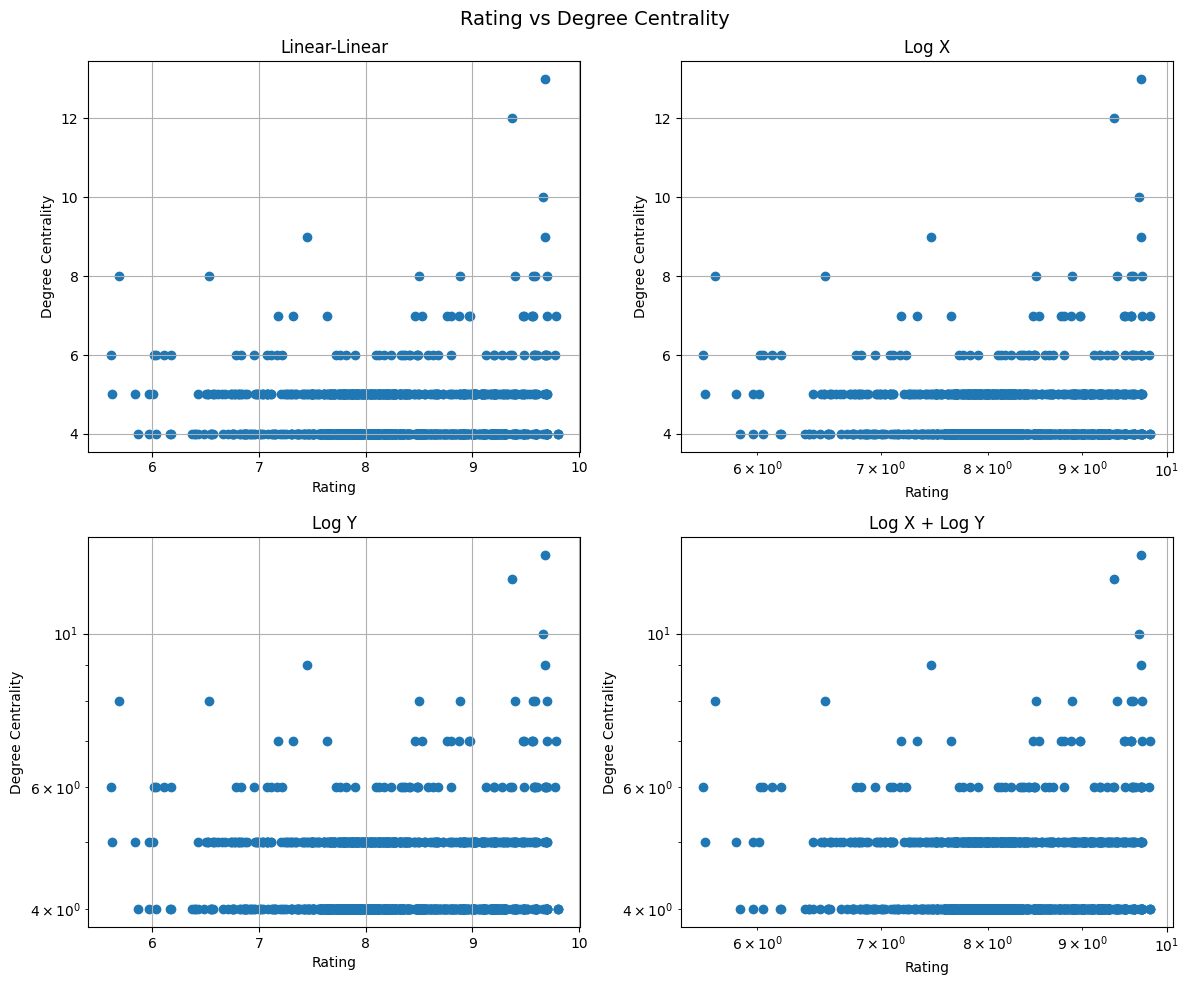

In [7]:
degree_centrality_bipartite = dict(B.degree())

plot_rating_vs_metric(
    B,
    degree_centrality_bipartite,
    metric_name="Degree Centrality"
)


Promedio de Eigenvector Centrality por intervalos de rating de 0.5:
rating_bin
(5.5, 6.0]     0.0212
(6.0, 6.5]     0.0226
(6.5, 7.0]     0.0230
(7.0, 7.5]     0.0222
(7.5, 8.0]     0.0196
(8.0, 8.5]     0.0196
(8.5, 9.0]     0.0148
(9.0, 9.5]     0.0170
(9.5, 10.0]    0.0127
Name: metric, dtype: float64


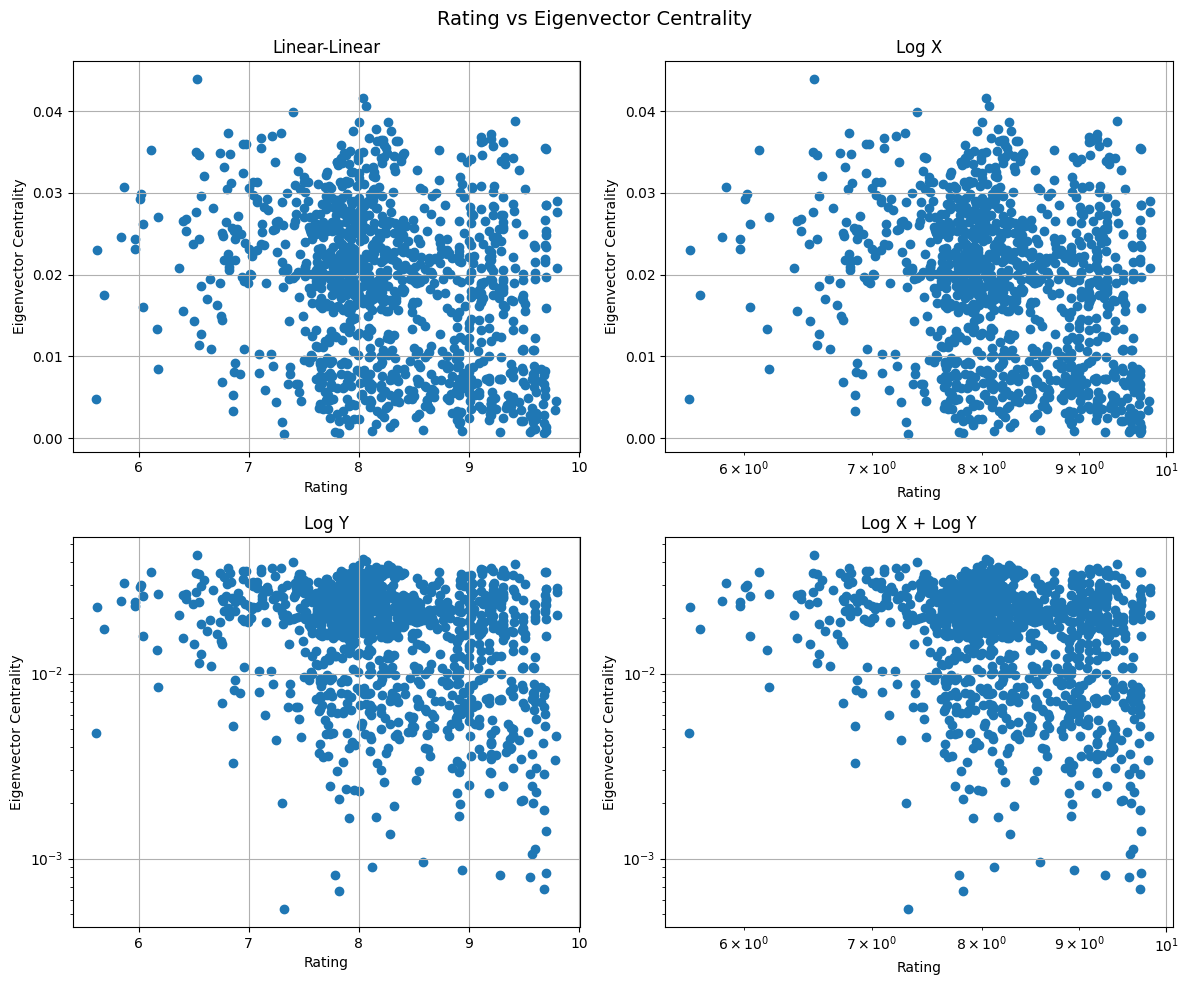

In [8]:
# Eigenvector centrality
eigenvector_centrality_bipartite = nx.eigenvector_centrality(B, max_iter=1000,  weight='weight')

plot_rating_vs_metric(
    B,
    eigenvector_centrality_bipartite,
    metric_name="Eigenvector Centrality"
)


Promedio de Betweenness Centrality por intervalos de rating de 0.5:
rating_bin
(5.5, 6.0]     0.0015
(6.0, 6.5]     0.0014
(6.5, 7.0]     0.0008
(7.0, 7.5]     0.0008
(7.5, 8.0]     0.0007
(8.0, 8.5]     0.0008
(8.5, 9.0]     0.0009
(9.0, 9.5]     0.0008
(9.5, 10.0]    0.0013
Name: metric, dtype: float64


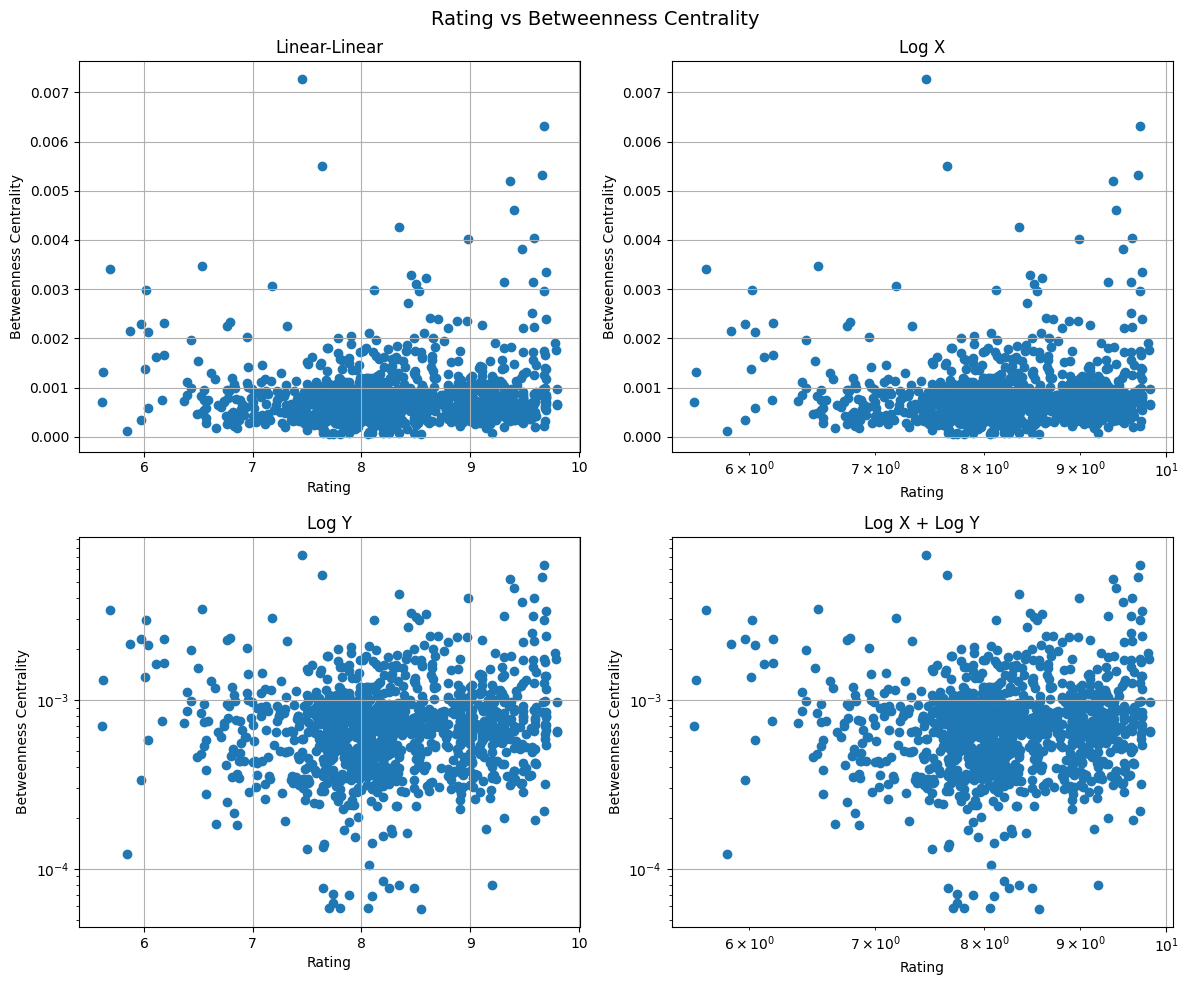

In [9]:
# Eigenvector centrality
betweenness_bipartite = nx.betweenness_centrality(B)

plot_rating_vs_metric(
    B,
    betweenness_bipartite,
    metric_name="Betweenness Centrality"
)


Promedio de Closeness Centrality por intervalos de rating de 0.5:
rating_bin
(5.5, 6.0]     0.2925
(6.0, 6.5]     0.3018
(6.5, 7.0]     0.2914
(7.0, 7.5]     0.2889
(7.5, 8.0]     0.2899
(8.0, 8.5]     0.2887
(8.5, 9.0]     0.2859
(9.0, 9.5]     0.2874
(9.5, 10.0]    0.2788
Name: metric, dtype: float64


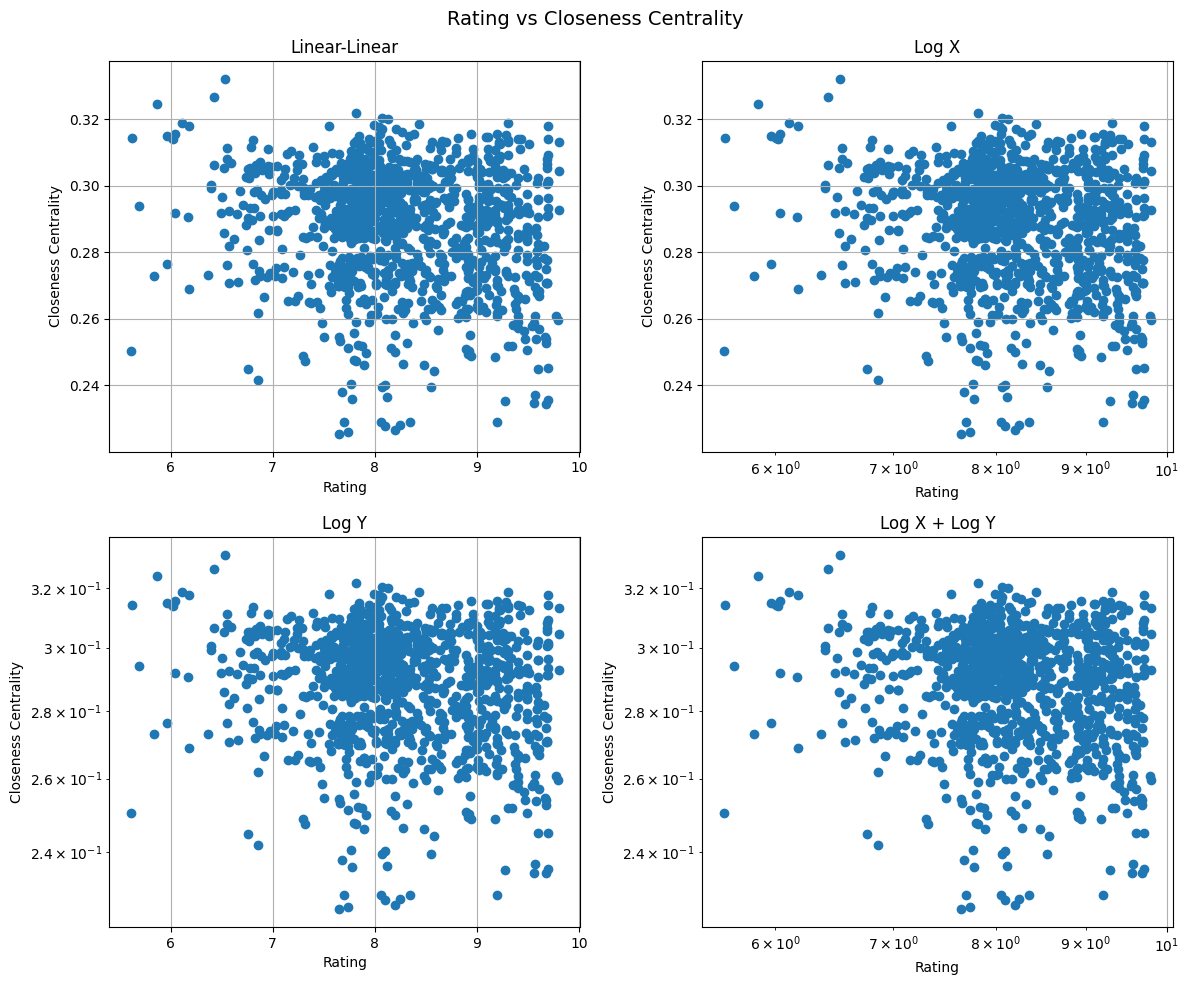

In [10]:
# Closeness centrality
closeness_bipartite = nx.closeness_centrality(B)

plot_rating_vs_metric(
    B,
    closeness_bipartite,
    metric_name="Closeness Centrality"
)

# Metricas sobre la proyección bipartita usando NetworkX vanilla

Se procede a sacar la proyeccion del grafo, haciendo que solo queden las personas del staff.

In [11]:
G_staff = bipartite_projection(B, "staff")

Number of nodes: 234, Number of edges: 2879


In [12]:
# Componentes conectadas

components = list(nx.connected_components(G_staff))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)


print("Giant Component")
print(f"Nodos: {G_staff.number_of_nodes()}")
print(f"Aristas: {G_staff.number_of_edges()}")

Componentes conectadas
Número de componentes: 1
Tamaño componente más grande: 234
Giant Component
Nodos: 234
Aristas: 2879


In [13]:
avg_path_length = nx.average_shortest_path_length(G_staff)

print("Largo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")

Largo de camino característico
Average shortest path length: 2.1648


Clustering coefficient
Average clustering coefficient: 0.6626
Top 10 clustering
Masahiko Inuzuka: 1.0000
Kim Yujin: 1.0000
Kim Juno: 1.0000
Shinichi Konno: 1.0000
Aimi Yamauchi: 1.0000
Kiichi Suzuno: 1.0000
Fumiharu Kamanaka: 1.0000
Evereux{Assistant}: 1.0000
Henry Thurlow[note 1]: 1.0000
Ryō Ōnishi: 1.0000


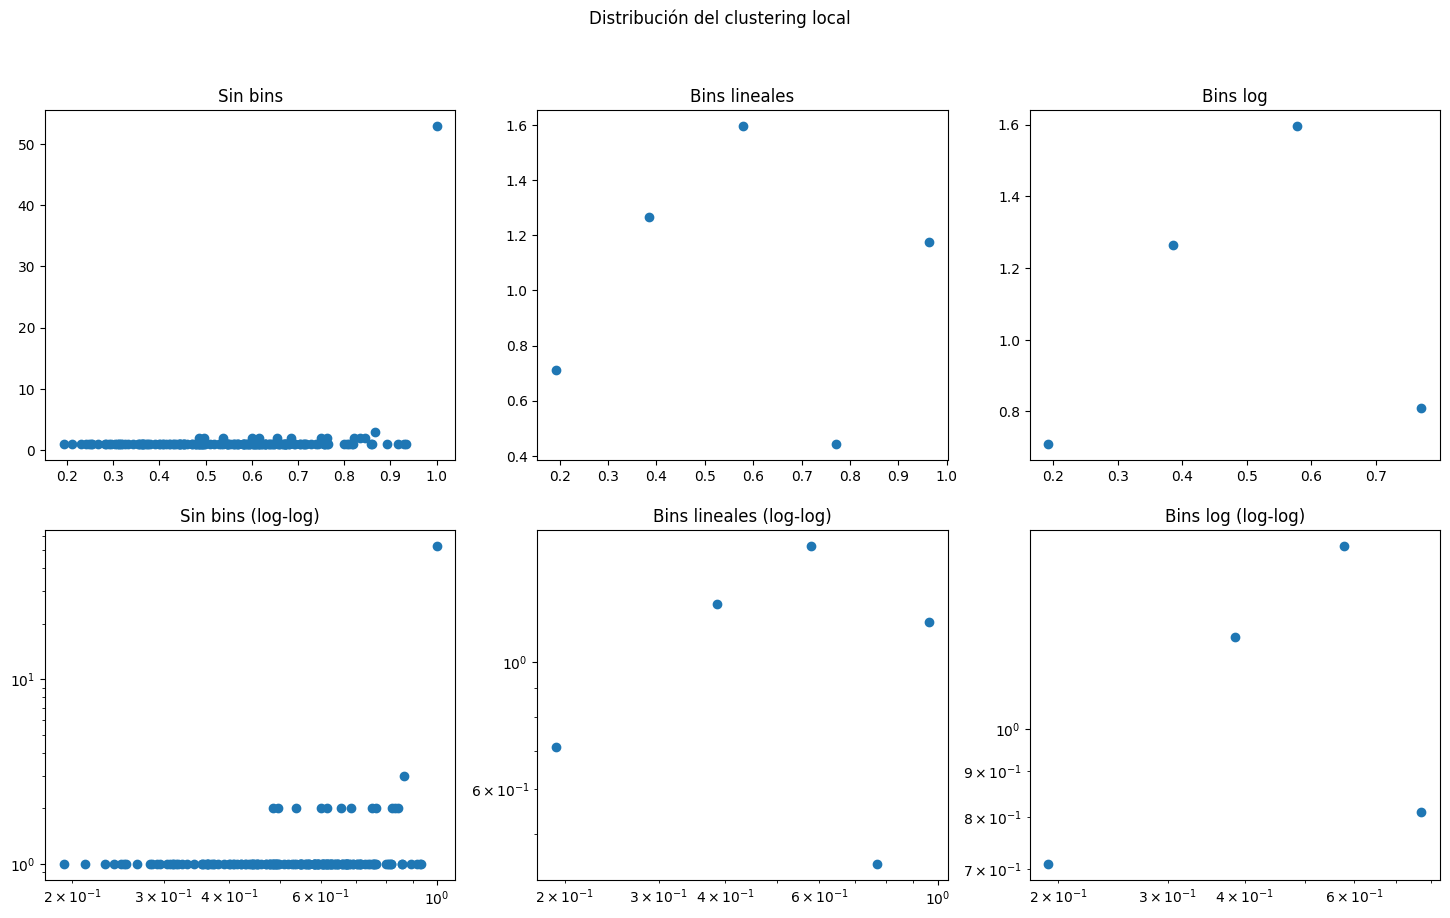

In [14]:
# coeficiente de clustering

avg_clustering = nx.average_clustering(G_staff)

print("Clustering coefficient")
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# por nodo

clustering_per_node = nx.clustering(G_staff)

# top 10 directores
top_clustering = sorted(
    clustering_per_node.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 clustering")

for node, coeff in top_clustering:

    director_name = node.replace("director_", "")

    print(f"{director_name}: {coeff:.4f}")

# Distribucion

clustering_values = list(clustering_per_node.values())

plot_distribution(clustering_values,
    "Distribución del clustering local"
)

plt.show()

Centralidad de grado

In [15]:
degree_centrality_nx = dict(G_staff.degree())

top = sorted(degree_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 110
Jin Tanaka 108
Kenji Yokoyama 101
Miyuki Sato 86
Masayuki Takagi 85
Atsuhiro Tomioka 85
Miho Shiraishi 80
Eisaku Inoue 79
Masahiro Shimanuki 78
Shōji Yonemura 77


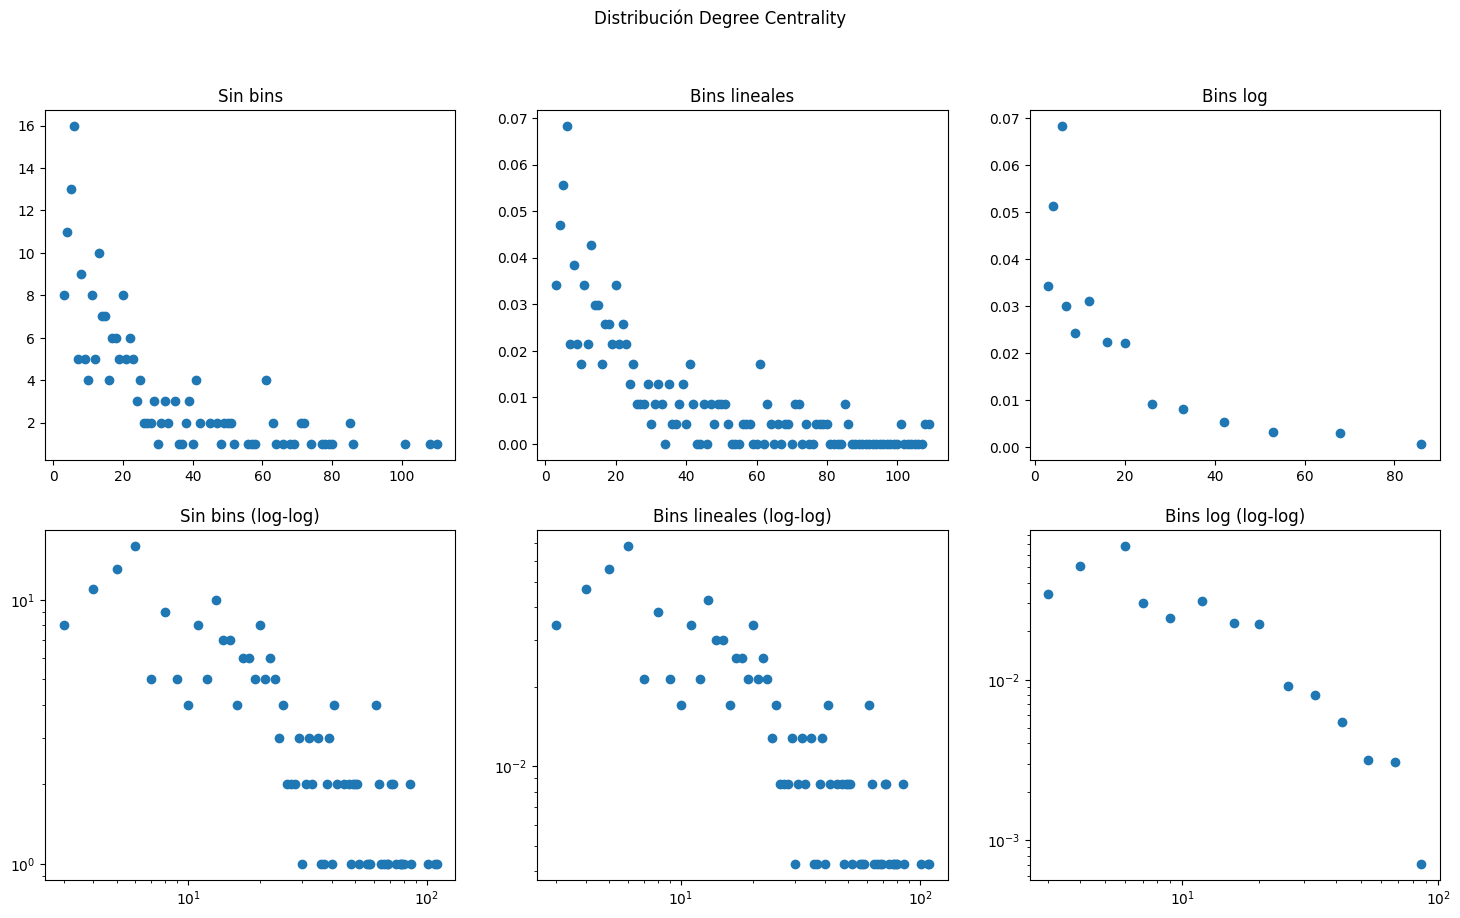

In [16]:
plot_distribution(list(degree_centrality_nx.values()),
                  "Distribución Degree Centrality")

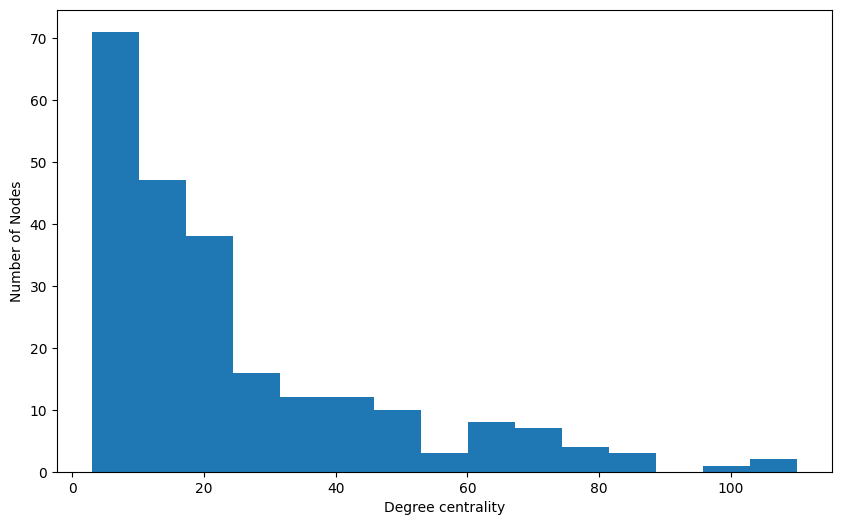

In [17]:
# Separar datos
personas = list(degree_centrality_nx.keys())
grados = list(degree_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Degree centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Centralidad de grado normalizada

In [18]:
degree = nx.degree_centrality(G_staff)

top = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 0.4721030042918455
Jin Tanaka 0.463519313304721
Kenji Yokoyama 0.4334763948497854
Miyuki Sato 0.36909871244635195
Masayuki Takagi 0.3648068669527897
Atsuhiro Tomioka 0.3648068669527897
Miho Shiraishi 0.34334763948497854
Eisaku Inoue 0.33905579399141633
Masahiro Shimanuki 0.33476394849785407
Shōji Yonemura 0.33047210300429186


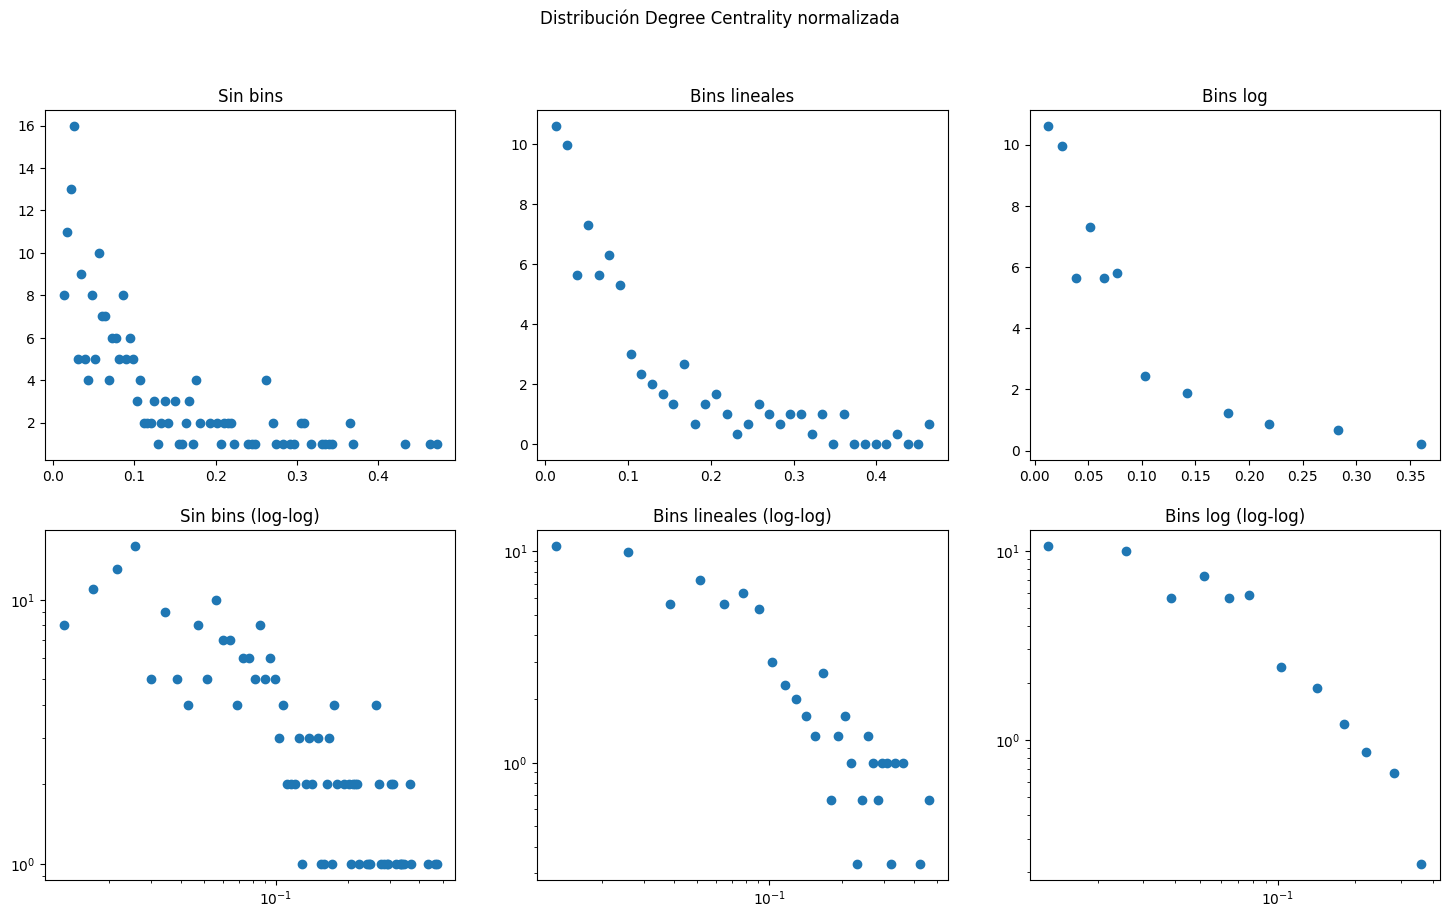

In [19]:
plot_distribution(list(degree.values()),
                  "Distribución Degree Centrality normalizada")

Eigenvector centrality sin considerar peso de la arista

In [20]:
eigen = nx.eigenvector_centrality(G_staff)

top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Kazuya Hisada 0.18525629742278404
Kenji Yokoyama 0.18202516289426704
Jin Tanaka 0.1741375222177056
Masahiro Shimanuki 0.15845695876056543
Toshio Deguchi 0.1541567824550746
Atsuhiro Tomioka 0.15203379399830094
Masayuki Takagi 0.1510550180078473
Miho Shiraishi 0.14623618428564725
Eisaku Inoue 0.14463468025797352
Tomohiro Nakayama 0.14433251849151463


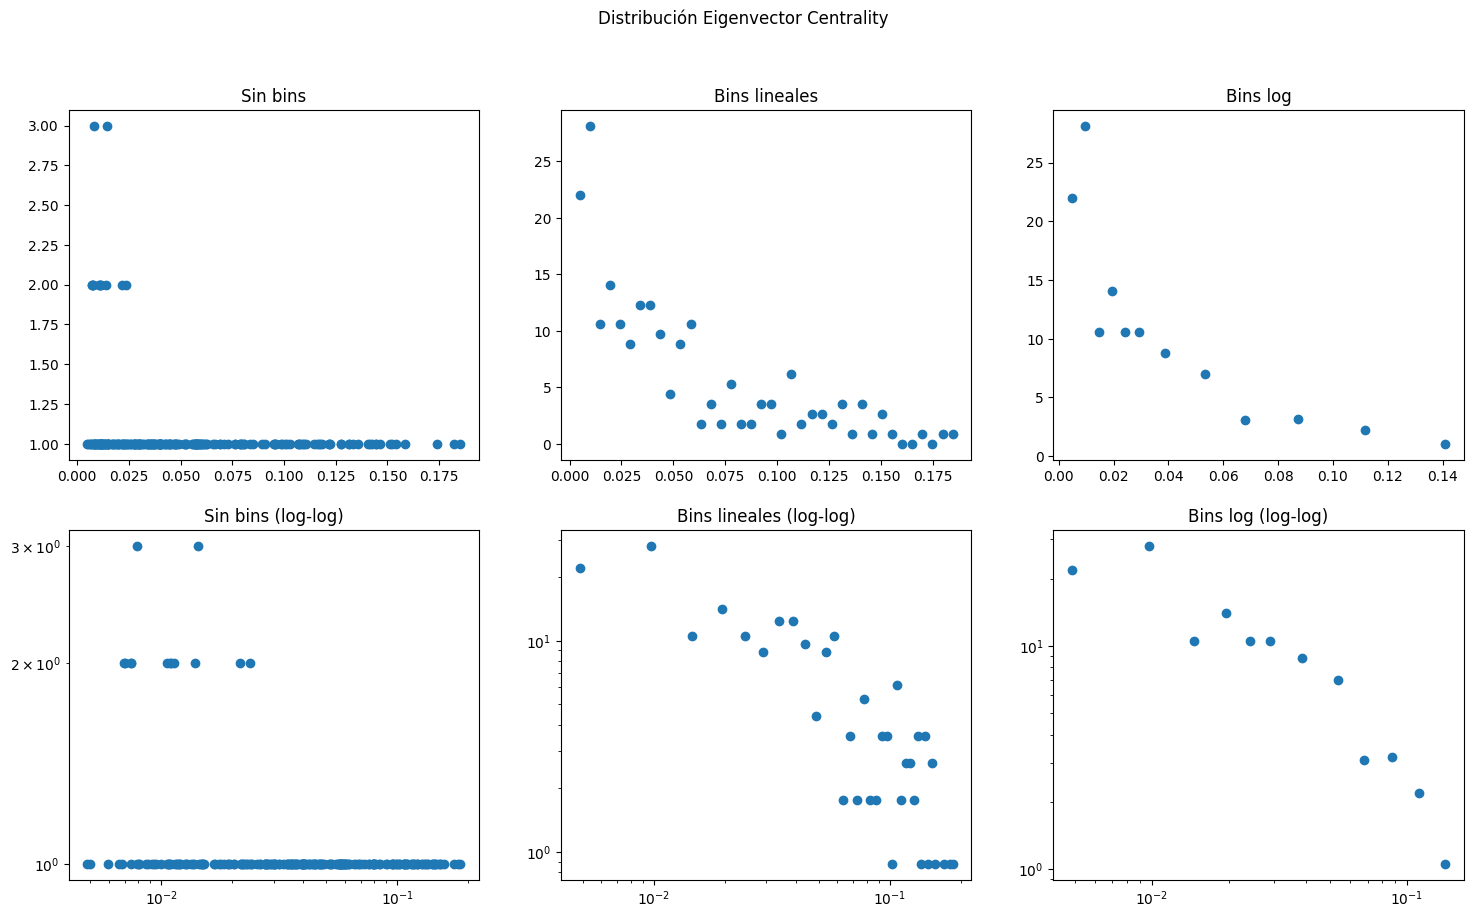

In [21]:
plot_distribution(list(eigen.values()),
                  "Distribución Eigenvector Centrality")

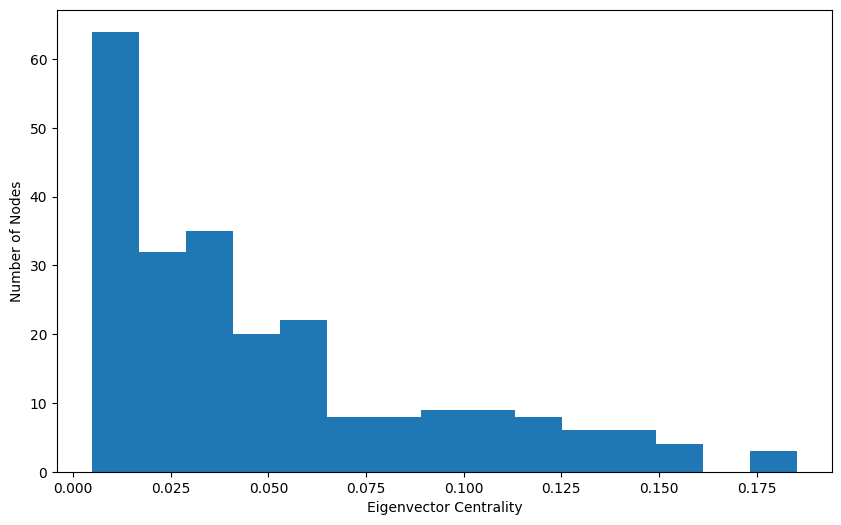

In [22]:
# Separar datos
personas = list(eigen.keys())
grados = list(eigen.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Eigenvector centrality considerando el peso de la arista

In [23]:
eigenvector_centrality_nx = nx.eigenvector_centrality(G_staff, weight='weight')

top_eigen = sorted(eigenvector_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Miyuki Sato 0.4018414078523281
Miho Shiraishi 0.3096059521239942
Hirohiko Kamisaka 0.30799513561676845
Ryūji Yoshiike 0.27448883176013766
Yoshiyuki Suga 0.24496777217433502
Kenji Yokoyama 0.2173535613847675
Jin Tanaka 0.19894807749938798
Masayuki Takagi 0.19811104261186582
Yoshihiro Ueda 0.18754084697348927
Michiyo Kawasaki 0.17528623016414174


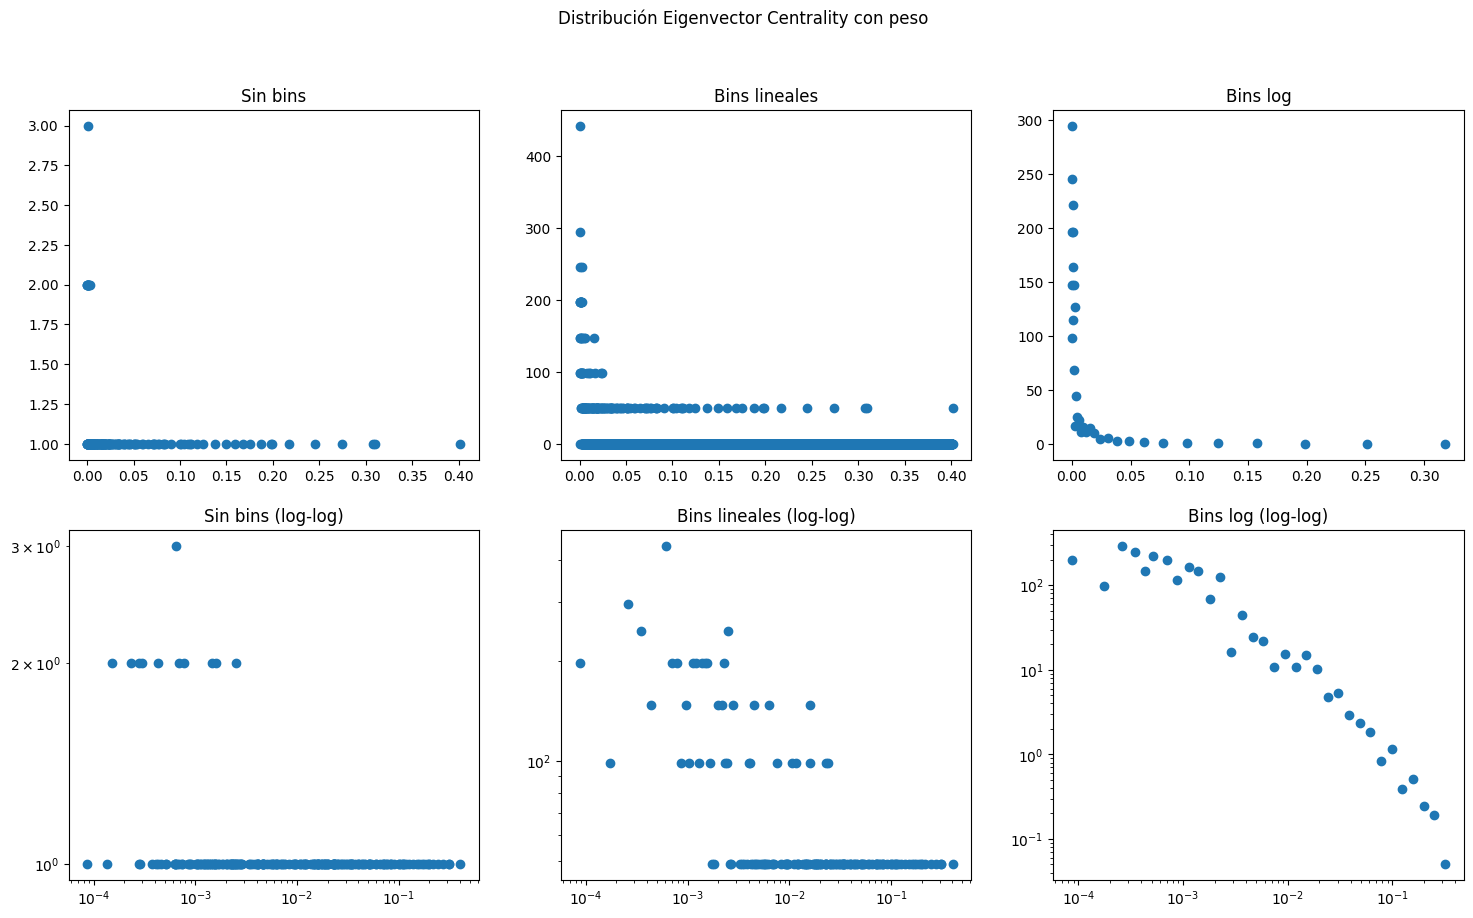

In [24]:
plot_distribution(list(eigenvector_centrality_nx.values()),
                  "Distribución Eigenvector Centrality con peso")

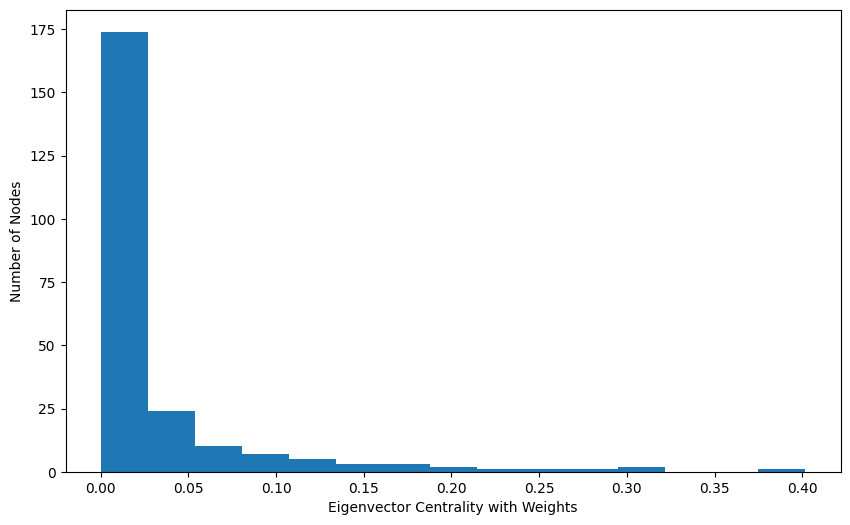

In [25]:
# Separar datos
personas = list(eigenvector_centrality_nx.keys())
grados = list(eigenvector_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality with Weights")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Closeness

In [26]:
closeness_centrality_nx = nx.closeness_centrality(G_staff)

top_closeness = sorted(closeness_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_closeness:
    print(name, val)

Kazuya Hisada 0.6544943820224719
Jin Tanaka 0.6508379888268156
Kenji Yokoyama 0.6383561643835617
Masayuki Takagi 0.6115485564304461
Masahiro Shimanuki 0.6005154639175257
Eisaku Inoue 0.6005154639175257
Miho Shiraishi 0.5974358974358974
Atsuhiro Tomioka 0.5943877551020408
Miyuki Sato 0.5913705583756346
Toshio Deguchi 0.5913705583756346


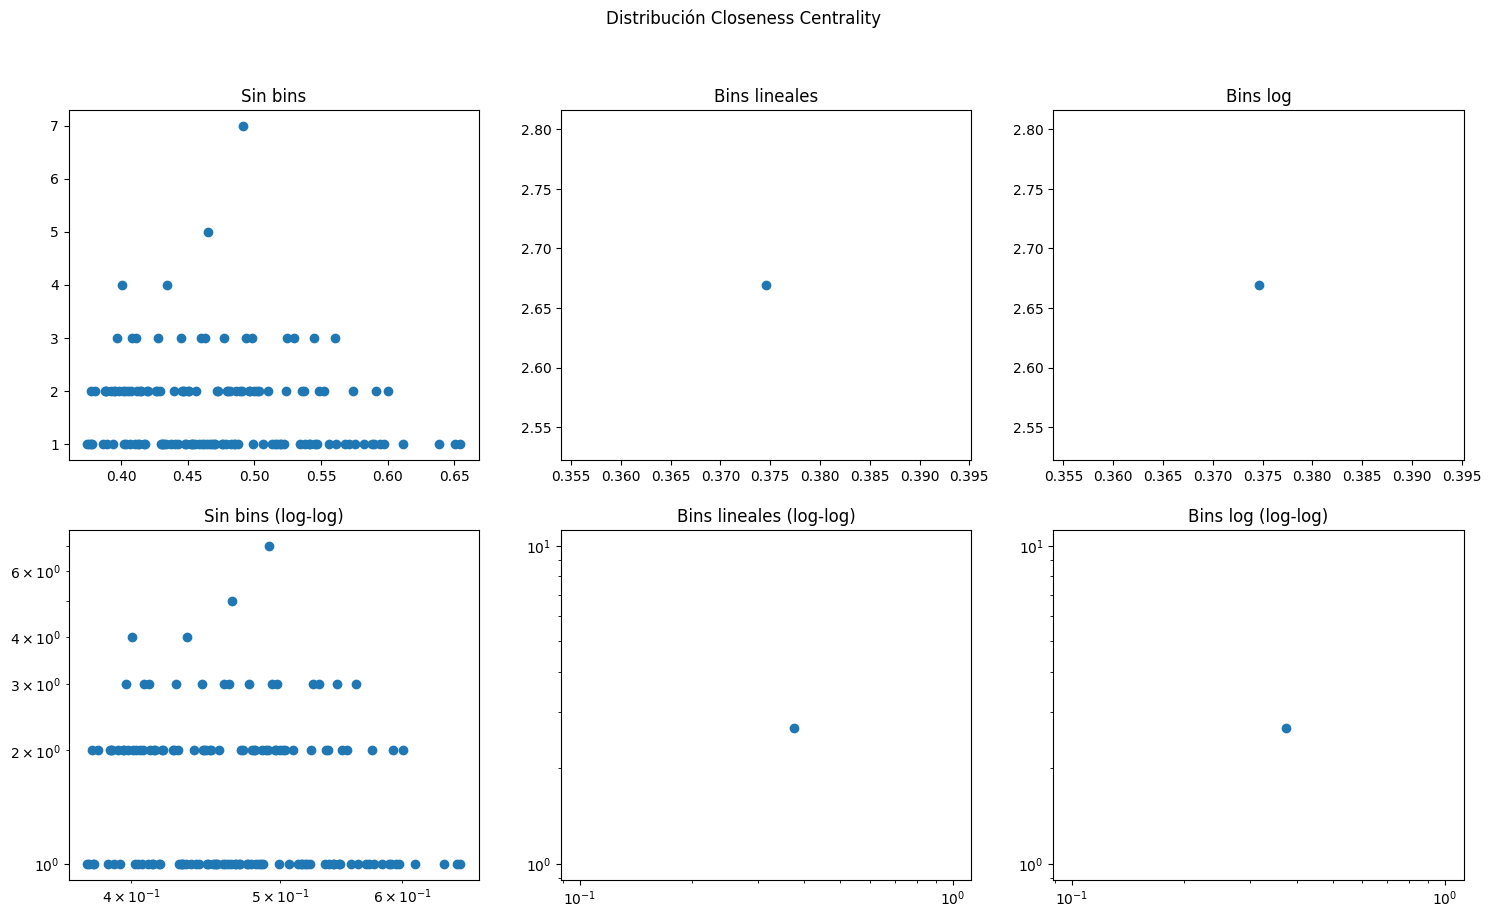

In [27]:
plot_distribution(list(closeness_centrality_nx.values()),
                  "Distribución Closeness Centrality")

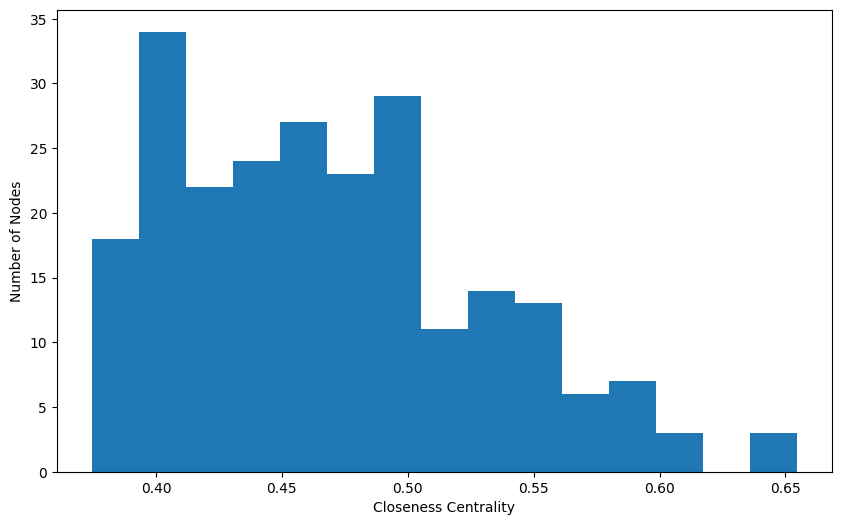

In [28]:
# Separar datos
personas = list(closeness_centrality_nx.keys())
grados = list(closeness_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Betwenness

In [29]:
betweenness_centrality_nx = nx.betweenness_centrality(G_staff)

top_betweenness = sorted(betweenness_centrality_nx.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_betweenness:
    print(name, val)

Jin Tanaka 0.09632341629318683
Kazuya Hisada 0.09226241779479234
Miyuki Sato 0.06822809191537474
Kenji Yokoyama 0.05688102366916951
Eisaku Inoue 0.0392753104366711
Masayuki Takagi 0.037858768374112214
Masahiro Kitazaki 0.0366136664119957
Atsuhiro Tomioka 0.035096357553010014
Masahiro Shimanuki 0.029312116593889322
Hirohiko Kamisaka 0.029078681665854218


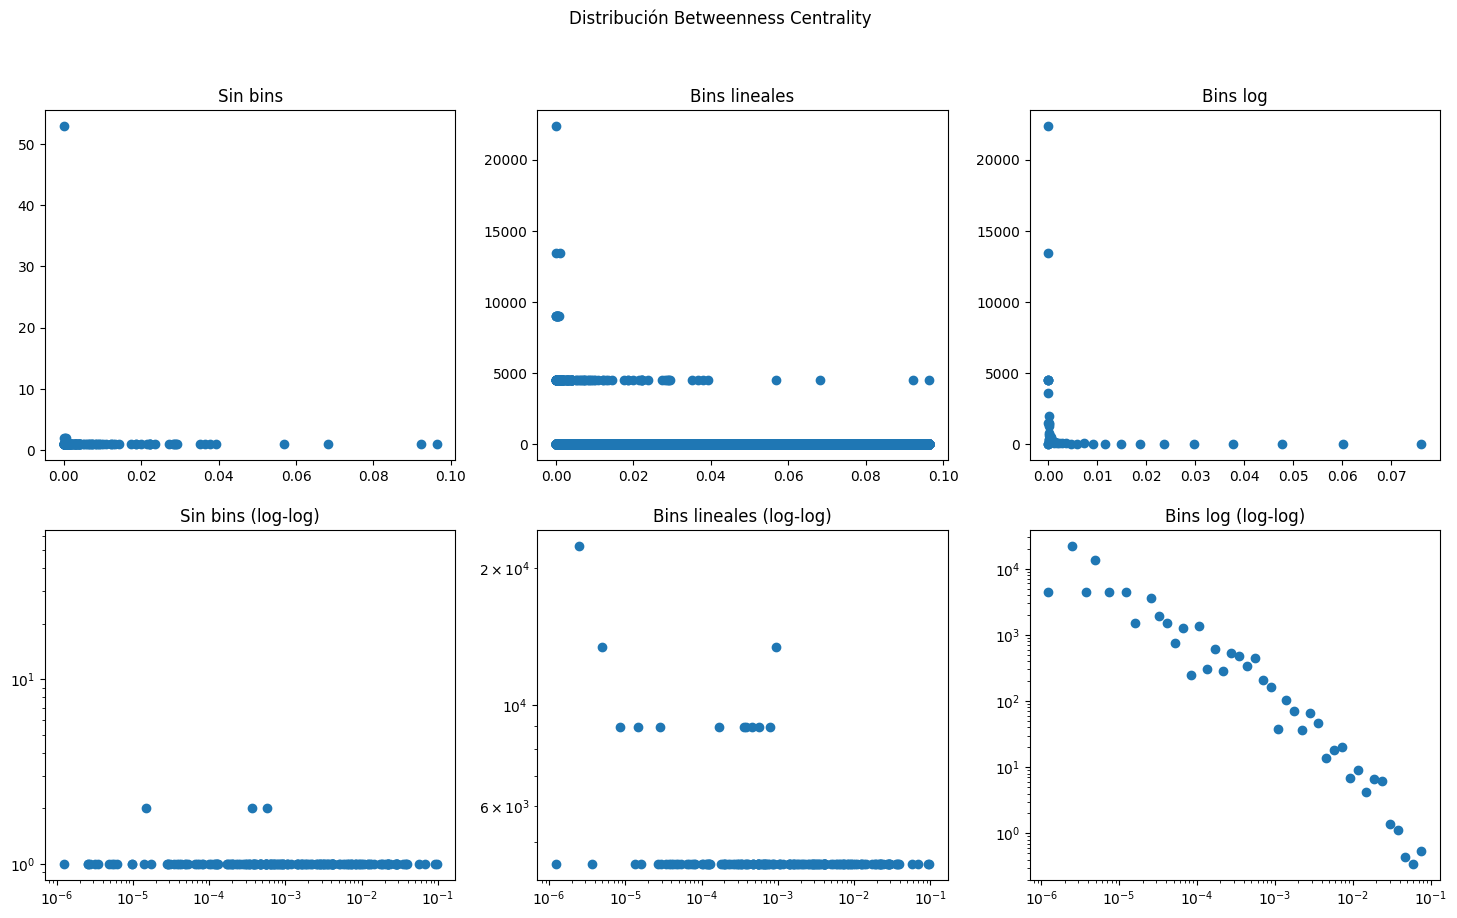

In [30]:
plot_distribution(list(betweenness_centrality_nx.values()),
                  "Distribución Betweenness Centrality")

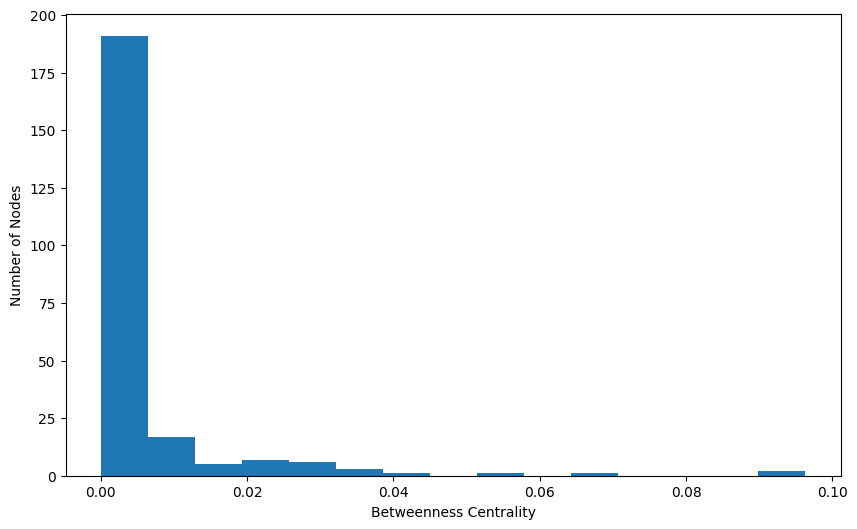

In [31]:
# Separar datos
personas = list(betweenness_centrality_nx.keys())
grados = list(betweenness_centrality_nx.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

# Proyección Bipartita Personalizada con attributos ponderados

In [32]:
# Obtener nodos de staff
staff_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}

# Proyección
G_staff_custom = projected_graph_custom(B, staff_nodes, multigraph=False)

print(f"Number of nodes: {G_staff_custom.number_of_nodes()}, Number of edges: {G_staff_custom.number_of_edges()}")
nx.write_gexf(G_staff_custom, "one_piece_staff_projection_custom.gexf")

Number of nodes: 234, Number of edges: 2879


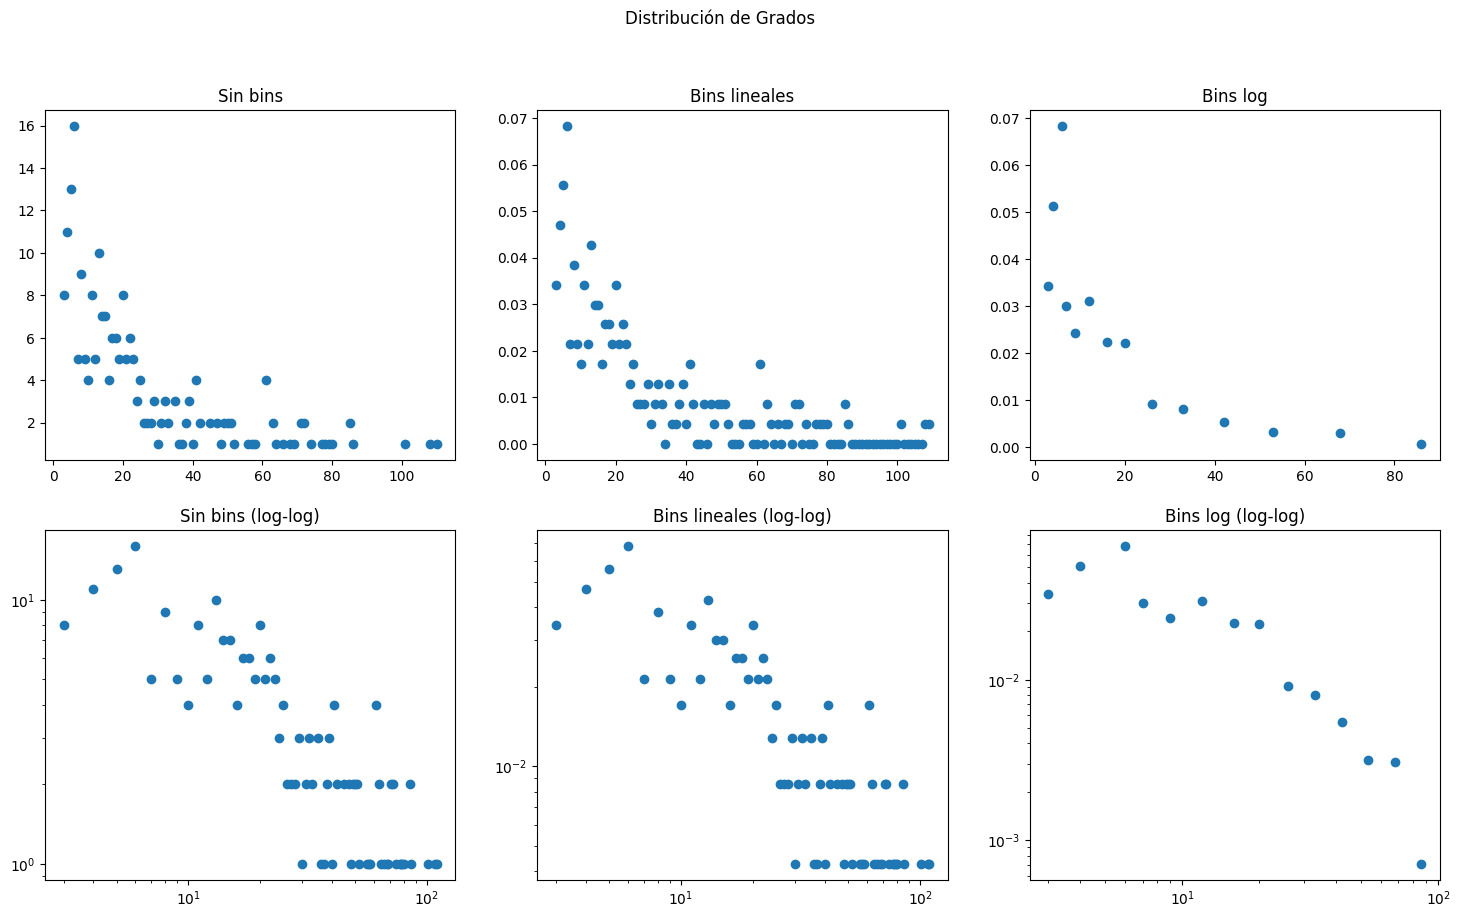

In [33]:
# distribucion de grados

degrees = [deg for _, deg in G_staff_custom.degree()]

plot_distribution(list(degrees),
                  "Distribución de Grados")

In [34]:
# Componentes conectadas

components = list(nx.connected_components(G_staff_custom))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)


print("Giant Component")
print(f"Nodos: {G_staff_custom.number_of_nodes()}")
print(f"Aristas: {G_staff_custom.number_of_edges()}")

Componentes conectadas
Número de componentes: 1
Tamaño componente más grande: 234
Giant Component
Nodos: 234
Aristas: 2879


In [35]:
avg_path_length = nx.average_shortest_path_length(G_staff_custom)

print("Largo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")

Largo de camino característico
Average shortest path length: 2.1648


Clustering coefficient
Average clustering coefficient: 0.6626
Top 10 clustering
Masahiko Inuzuka: 1.0000
Kim Yujin: 1.0000
Kim Juno: 1.0000
Shinichi Konno: 1.0000
Aimi Yamauchi: 1.0000
Kiichi Suzuno: 1.0000
Fumiharu Kamanaka: 1.0000
Evereux{Assistant}: 1.0000
Henry Thurlow[note 1]: 1.0000
Ryō Ōnishi: 1.0000


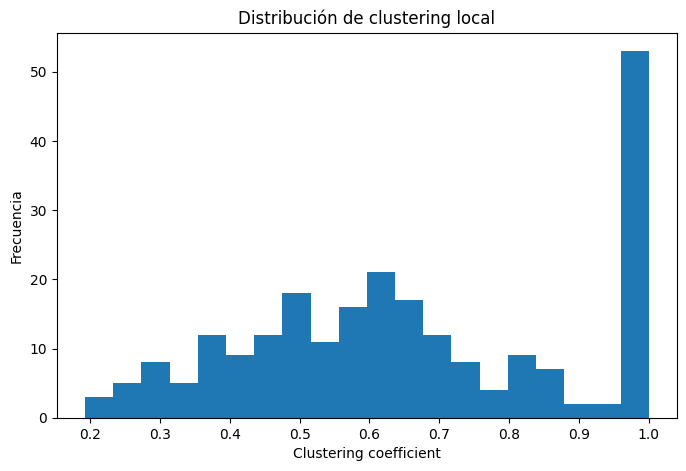

In [36]:
# coeficiente de clustering

avg_clustering = nx.average_clustering(G_staff_custom)

print("Clustering coefficient")
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# por nodo

clustering_per_node = nx.clustering(G_staff_custom)

# top 10 directores
top_clustering = sorted(
    clustering_per_node.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

print("Top 10 clustering")

for node, coeff in top_clustering:

    director_name = node.replace("director_", "")

    print(f"{director_name}: {coeff:.4f}")

# Distribucion

clustering_values = list(clustering_per_node.values())

plt.figure(figsize=(8,5))

plt.hist(clustering_values, bins=20)

plt.xlabel("Clustering coefficient")
plt.ylabel("Frecuencia")
plt.title("Distribución de clustering local")

plt.show()

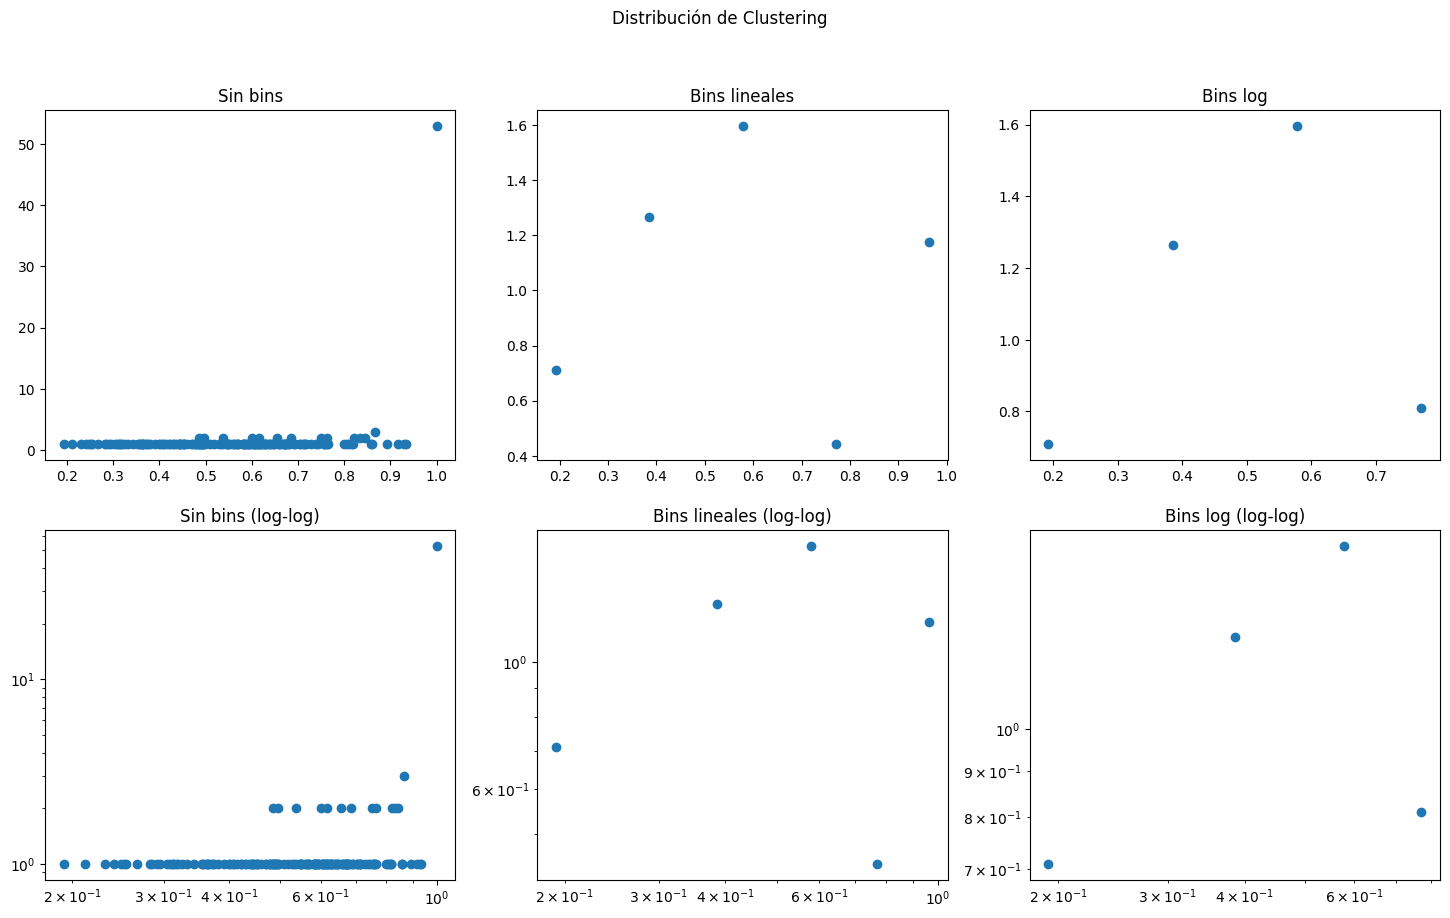

In [37]:
plot_distribution(list(clustering_values),
                  "Distribución de Clustering")

Centralidad de grado

In [38]:
degree_centrality_custom = dict(G_staff_custom.degree())

top = sorted(degree_centrality_custom.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 110
Jin Tanaka 108
Kenji Yokoyama 101
Miyuki Sato 86
Masayuki Takagi 85
Atsuhiro Tomioka 85
Miho Shiraishi 80
Eisaku Inoue 79
Masahiro Shimanuki 78
Shōji Yonemura 77


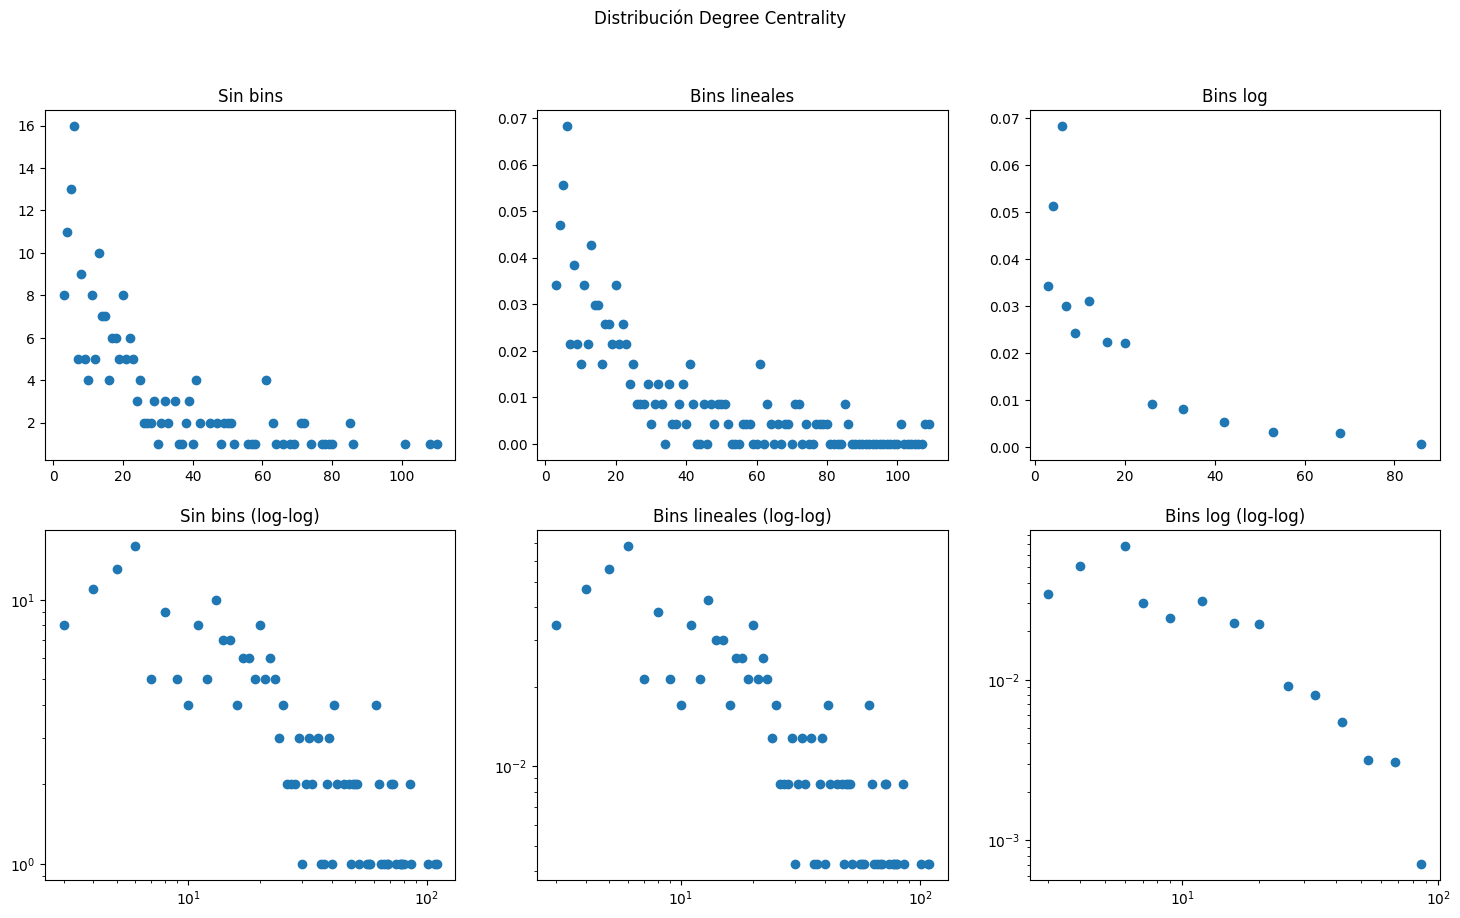

In [39]:
plot_distribution(list(degree_centrality_custom.values()),
                  "Distribución Degree Centrality")

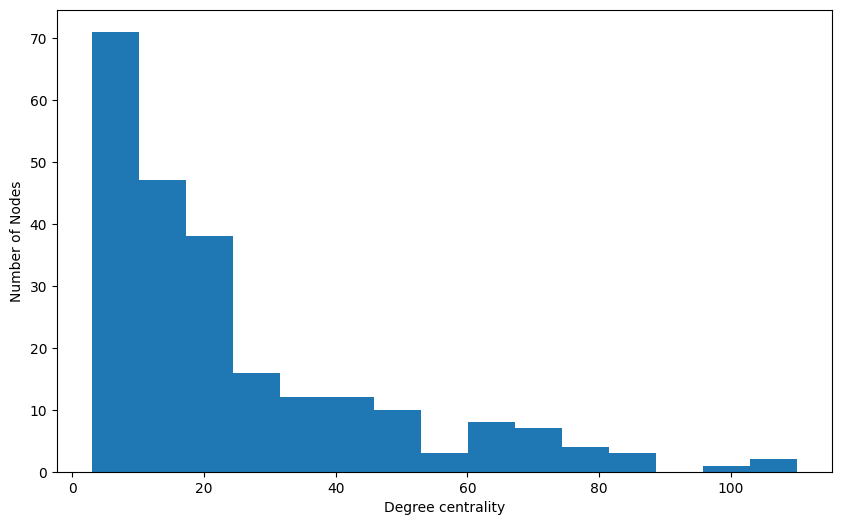

In [40]:
# Separar datos
personas = list(degree_centrality_custom.keys())
grados = list(degree_centrality_custom.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Degree centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Centralidad de grado normalizada

In [41]:
degree = nx.degree_centrality(G_staff_custom)

top = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Kazuya Hisada 0.4721030042918455
Jin Tanaka 0.463519313304721
Kenji Yokoyama 0.4334763948497854
Miyuki Sato 0.36909871244635195
Masayuki Takagi 0.3648068669527897
Atsuhiro Tomioka 0.3648068669527897
Miho Shiraishi 0.34334763948497854
Eisaku Inoue 0.33905579399141633
Masahiro Shimanuki 0.33476394849785407
Shōji Yonemura 0.33047210300429186


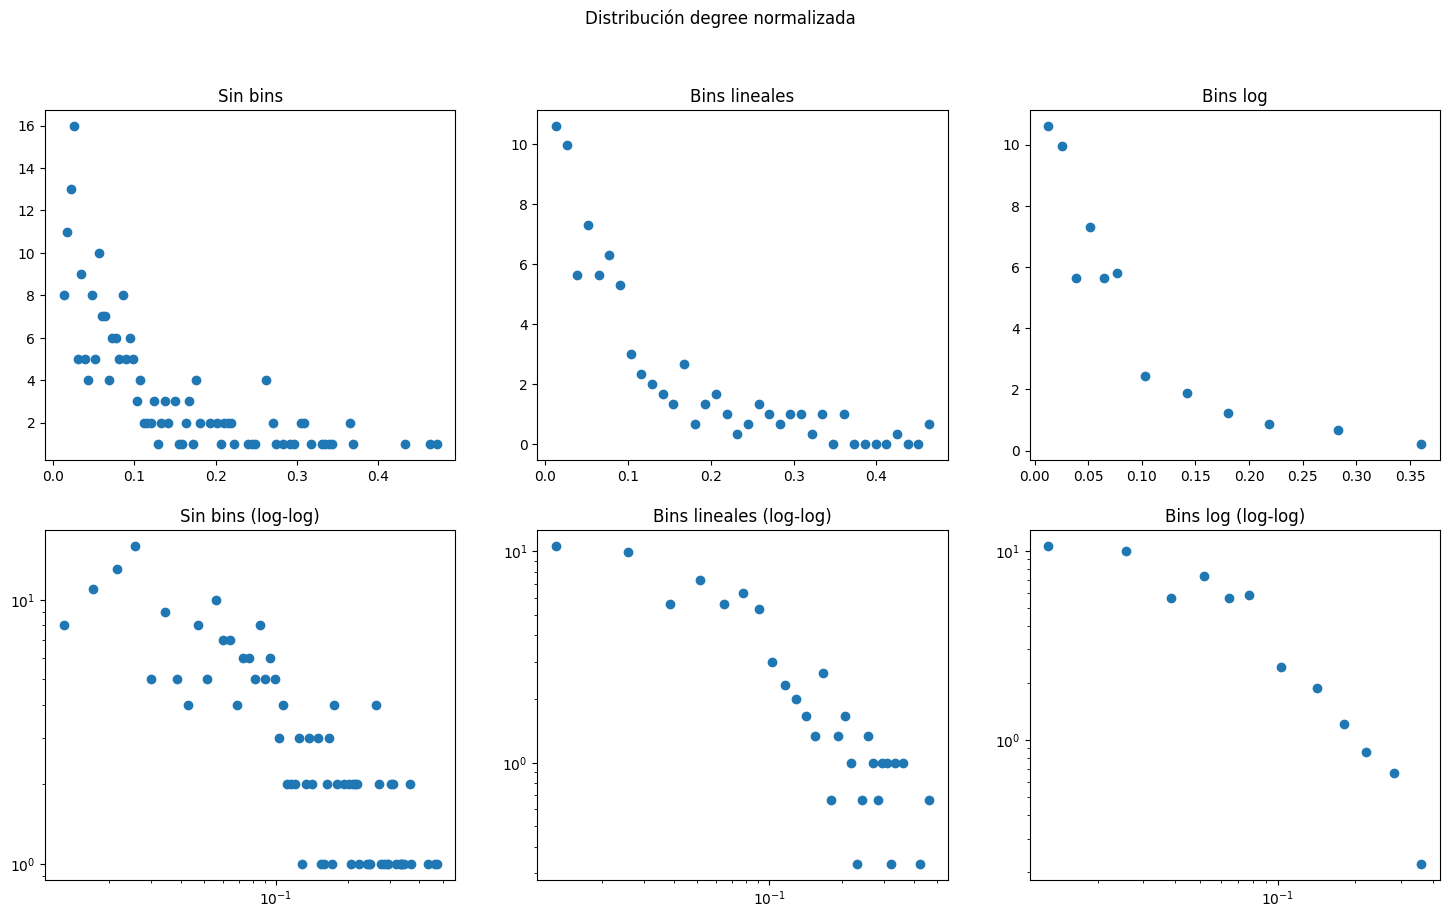

In [42]:
plot_distribution(list(degree.values()),
                  "Distribución degree normalizada")

Eigenvector centrality sin considerar peso de la arista

In [43]:
eigen = nx.eigenvector_centrality(G_staff_custom)

top_eigen = sorted(eigen.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Kazuya Hisada 0.18525629742278404
Kenji Yokoyama 0.18202516289426704
Jin Tanaka 0.1741375222177056
Masahiro Shimanuki 0.15845695876056543
Toshio Deguchi 0.1541567824550746
Atsuhiro Tomioka 0.15203379399830094
Masayuki Takagi 0.1510550180078473
Miho Shiraishi 0.14623618428564725
Eisaku Inoue 0.14463468025797352
Tomohiro Nakayama 0.14433251849151463


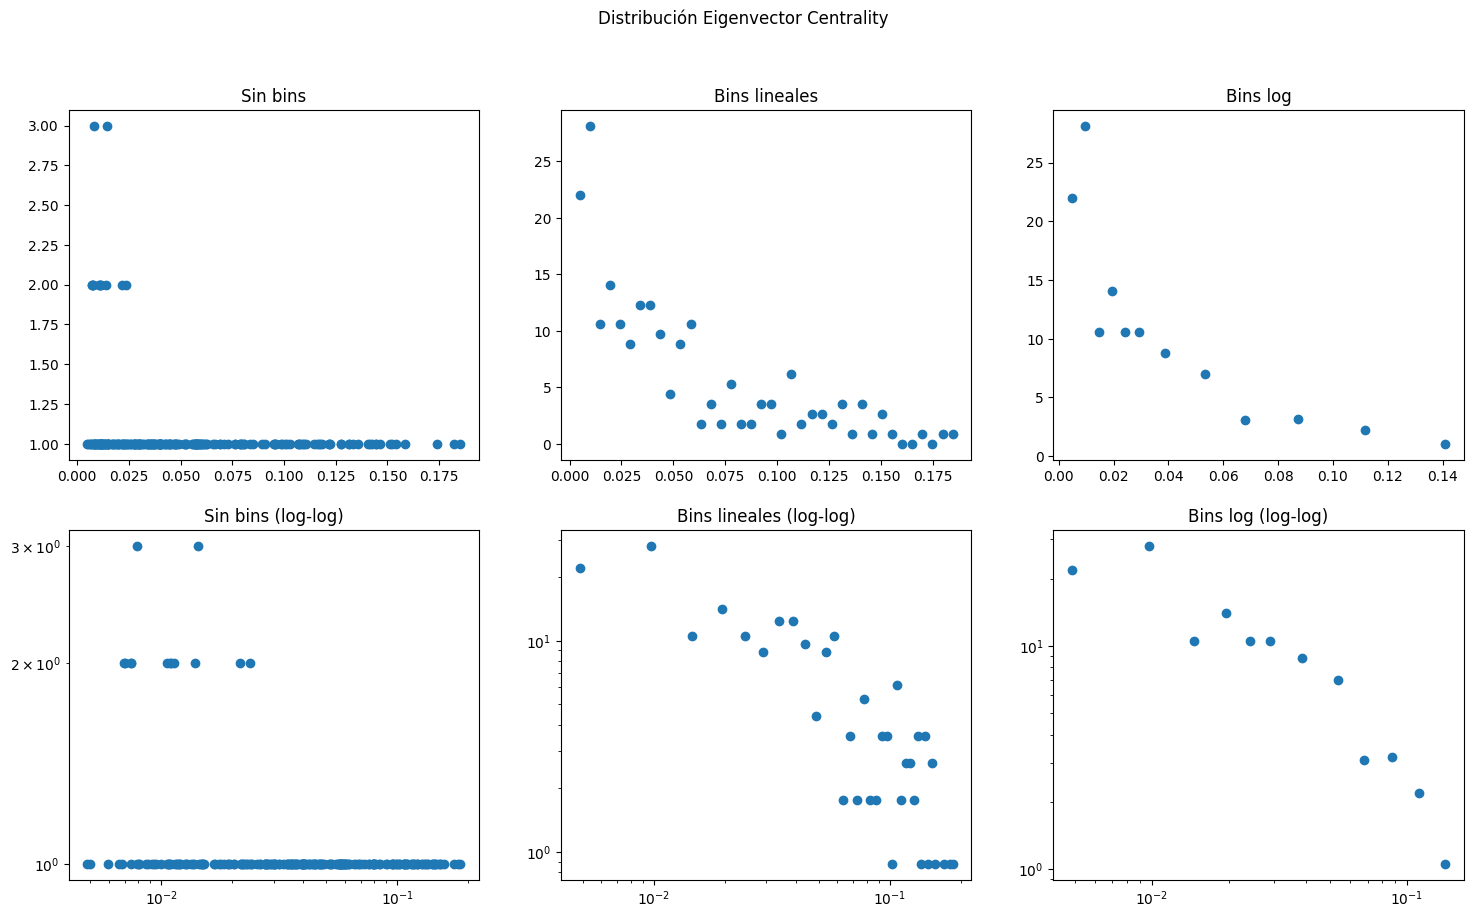

In [44]:
plot_distribution(list(eigen.values()),
                  "Distribución Eigenvector Centrality")

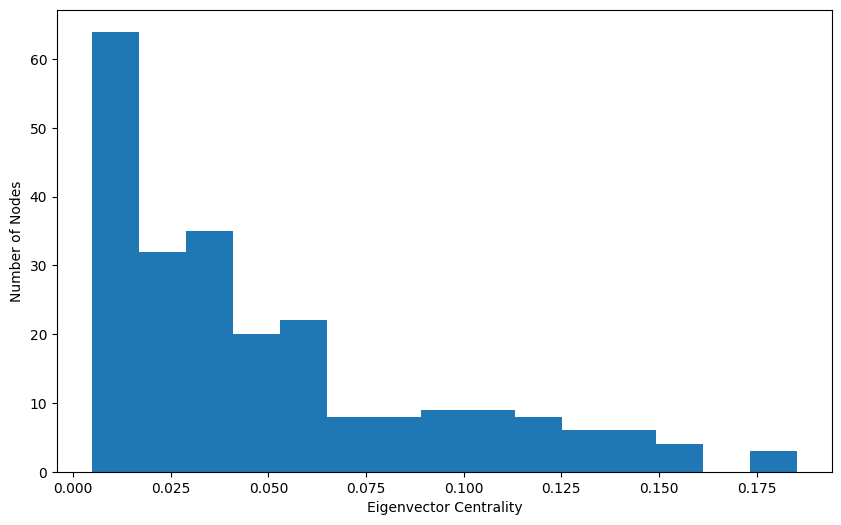

In [45]:
# Separar datos
personas = list(eigen.keys())
grados = list(eigen.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Eigenvector centrality considerando el peso de la arista

In [46]:
eigenvector_centrality_custom = nx.eigenvector_centrality(G_staff_custom, weight='rating')

top_eigen = sorted(eigenvector_centrality_custom.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_eigen:
    print(name, val)

Jin Tanaka 0.17993058952266905
Kazuya Hisada 0.17824479462609977
Kenji Yokoyama 0.16958804472236022
Atsuhiro Tomioka 0.15775402616846465
Toshio Deguchi 0.15766775458250015
Masahiro Shimanuki 0.15365050749890607
Kimitaka Itō 0.14766144026441072
Shōji Yonemura 0.14765150465500704
Tomohiro Nakayama 0.1475946333299298
Shigefumi Shingaki 0.14482236087981257


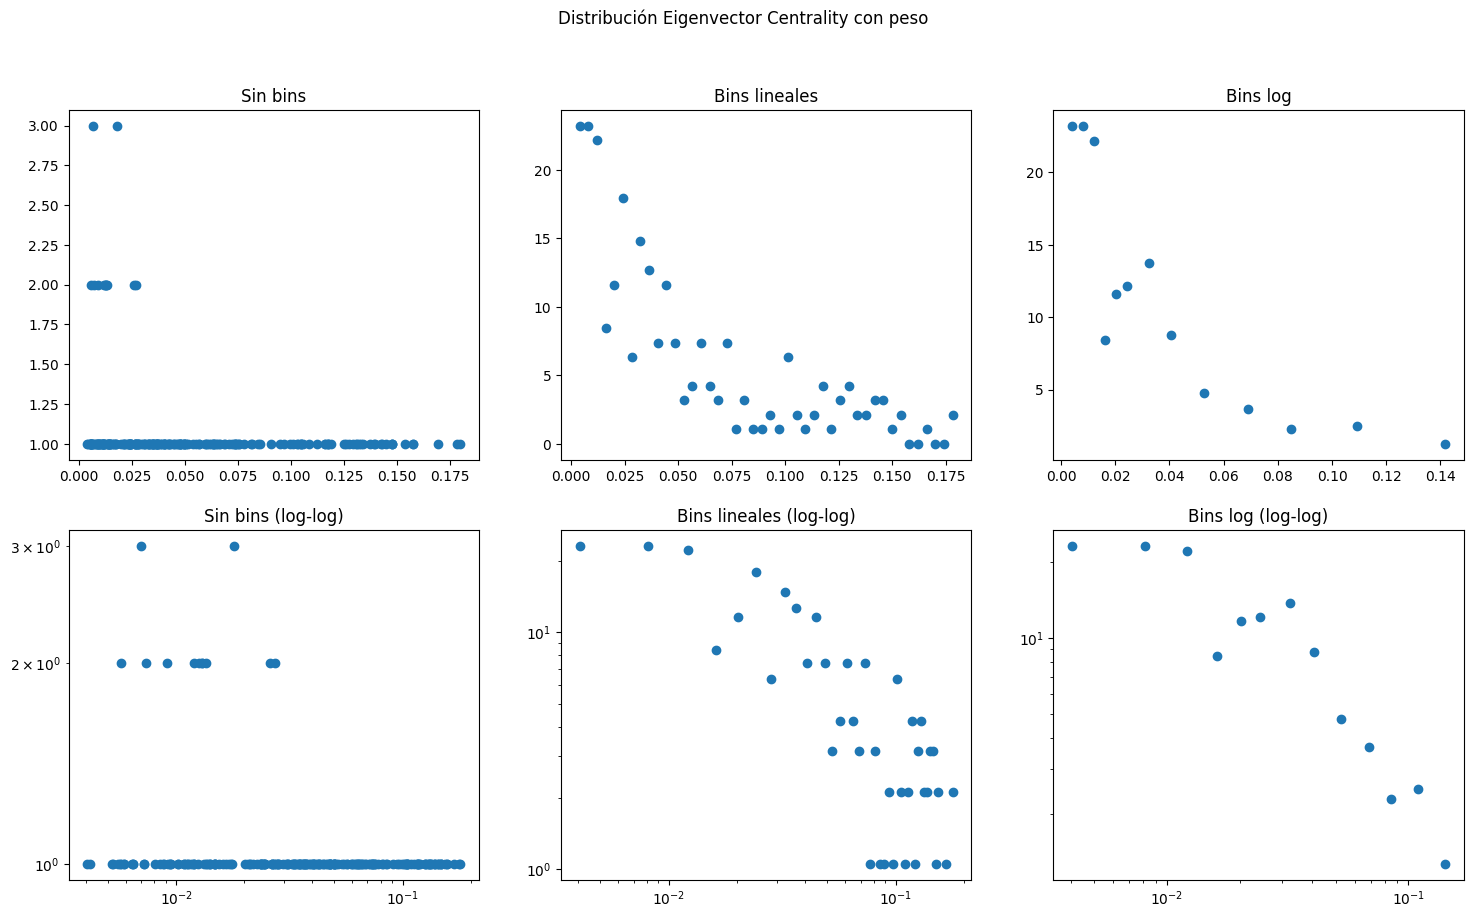

In [47]:
plot_distribution(list(eigenvector_centrality_custom.values()),
                  "Distribución Eigenvector Centrality con peso")

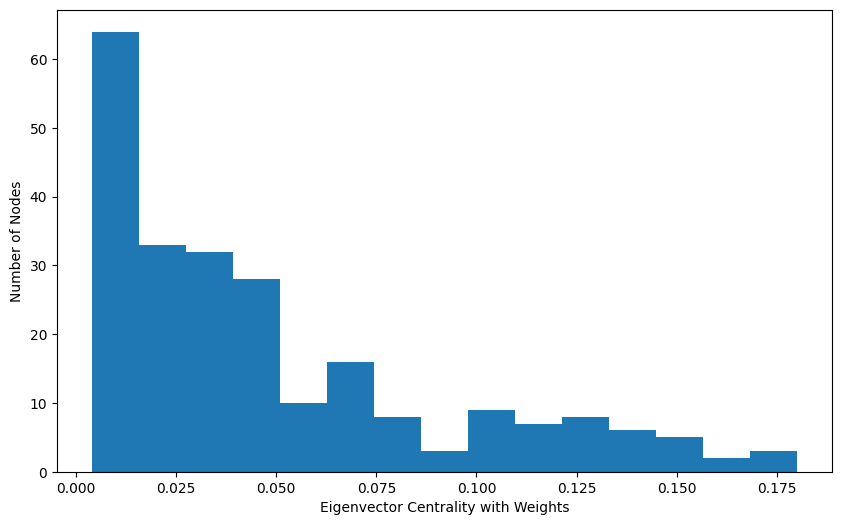

In [48]:
# Separar datos
personas = list(eigenvector_centrality_custom.keys())
grados = list(eigenvector_centrality_custom.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Eigenvector Centrality with Weights")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Closeness

In [49]:
closeness_centrality_custom = nx.closeness_centrality(G_staff_custom)

top_closeness = sorted(closeness_centrality_custom.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_closeness:
    print(name, val)

Kazuya Hisada 0.6544943820224719
Jin Tanaka 0.6508379888268156
Kenji Yokoyama 0.6383561643835617
Masayuki Takagi 0.6115485564304461
Masahiro Shimanuki 0.6005154639175257
Eisaku Inoue 0.6005154639175257
Miho Shiraishi 0.5974358974358974
Atsuhiro Tomioka 0.5943877551020408
Miyuki Sato 0.5913705583756346
Toshio Deguchi 0.5913705583756346


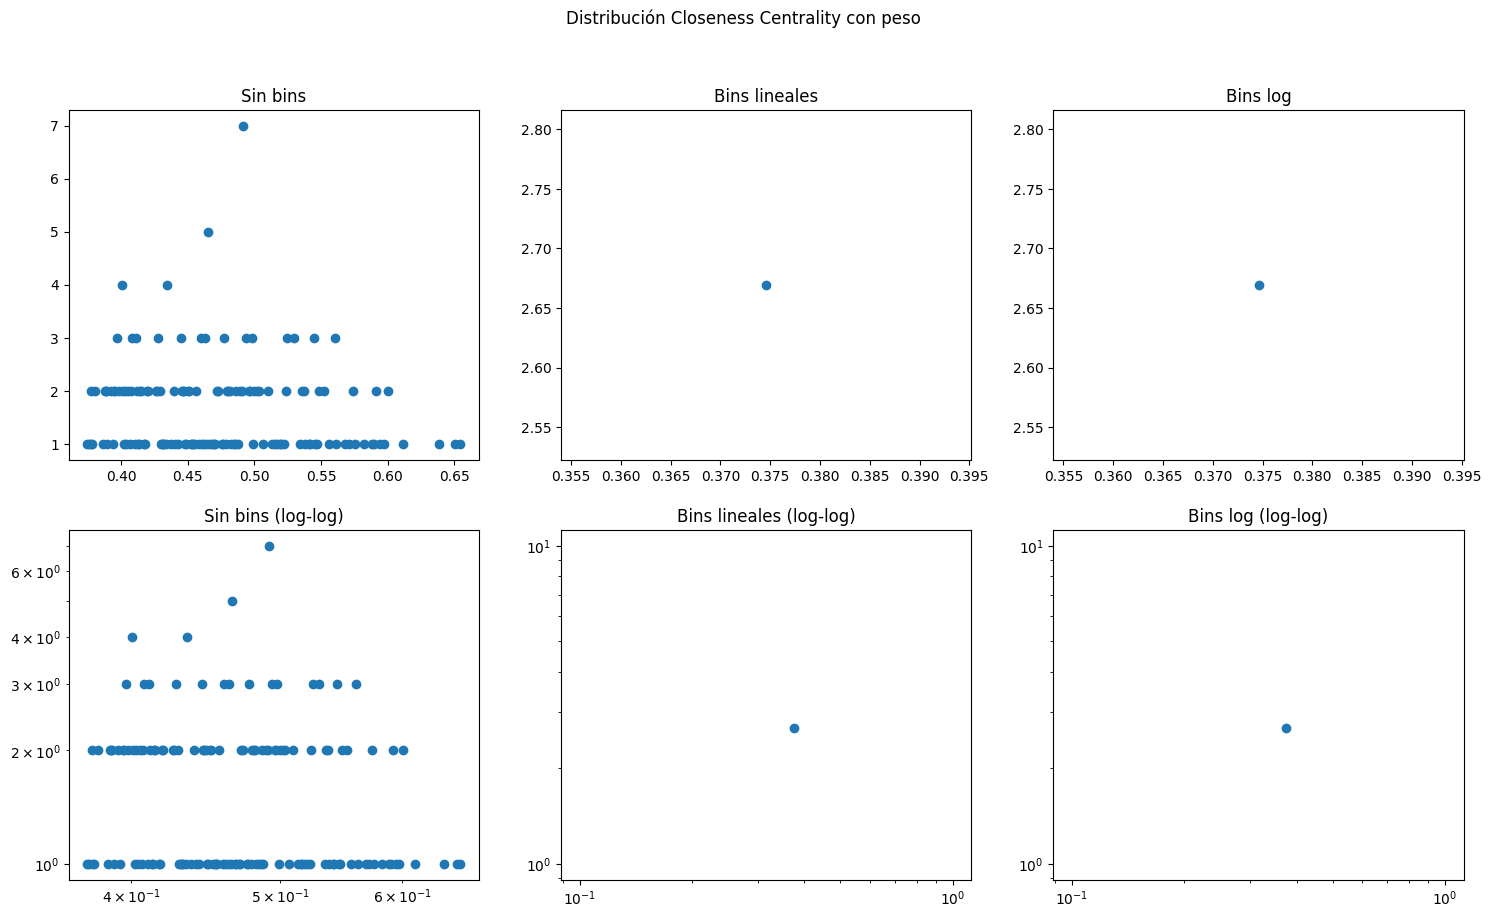

In [50]:
plot_distribution(list(closeness_centrality_custom.values()),
                  "Distribución Closeness Centrality con peso")

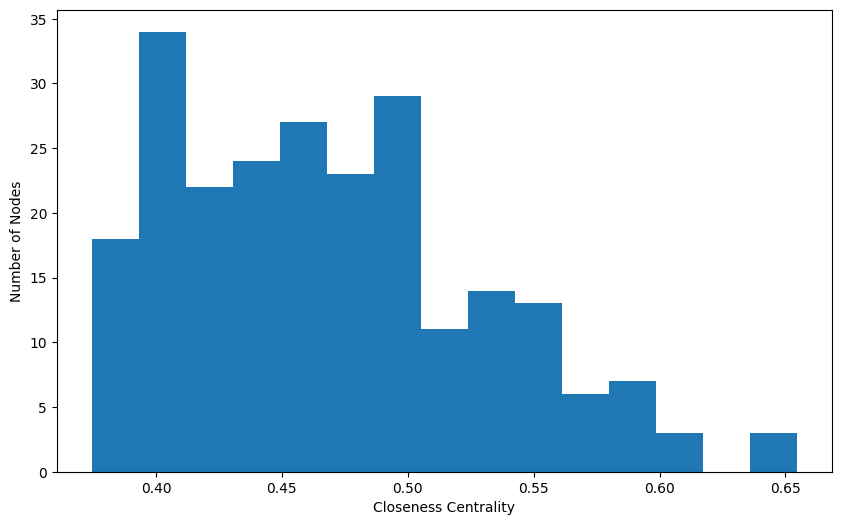

In [51]:
# Separar datos
personas = list(closeness_centrality_custom.keys())
grados = list(closeness_centrality_custom.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Betwenness

In [52]:
betweenness_centrality_custom = nx.betweenness_centrality(G_staff_custom)

top_betweenness = sorted(betweenness_centrality_custom.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_betweenness:
    print(name, val)

Jin Tanaka 0.09632341629318683
Kazuya Hisada 0.09226241779479234
Miyuki Sato 0.06822809191537474
Kenji Yokoyama 0.05688102366916951
Eisaku Inoue 0.0392753104366711
Masayuki Takagi 0.037858768374112214
Masahiro Kitazaki 0.0366136664119957
Atsuhiro Tomioka 0.035096357553010014
Masahiro Shimanuki 0.029312116593889322
Hirohiko Kamisaka 0.029078681665854218


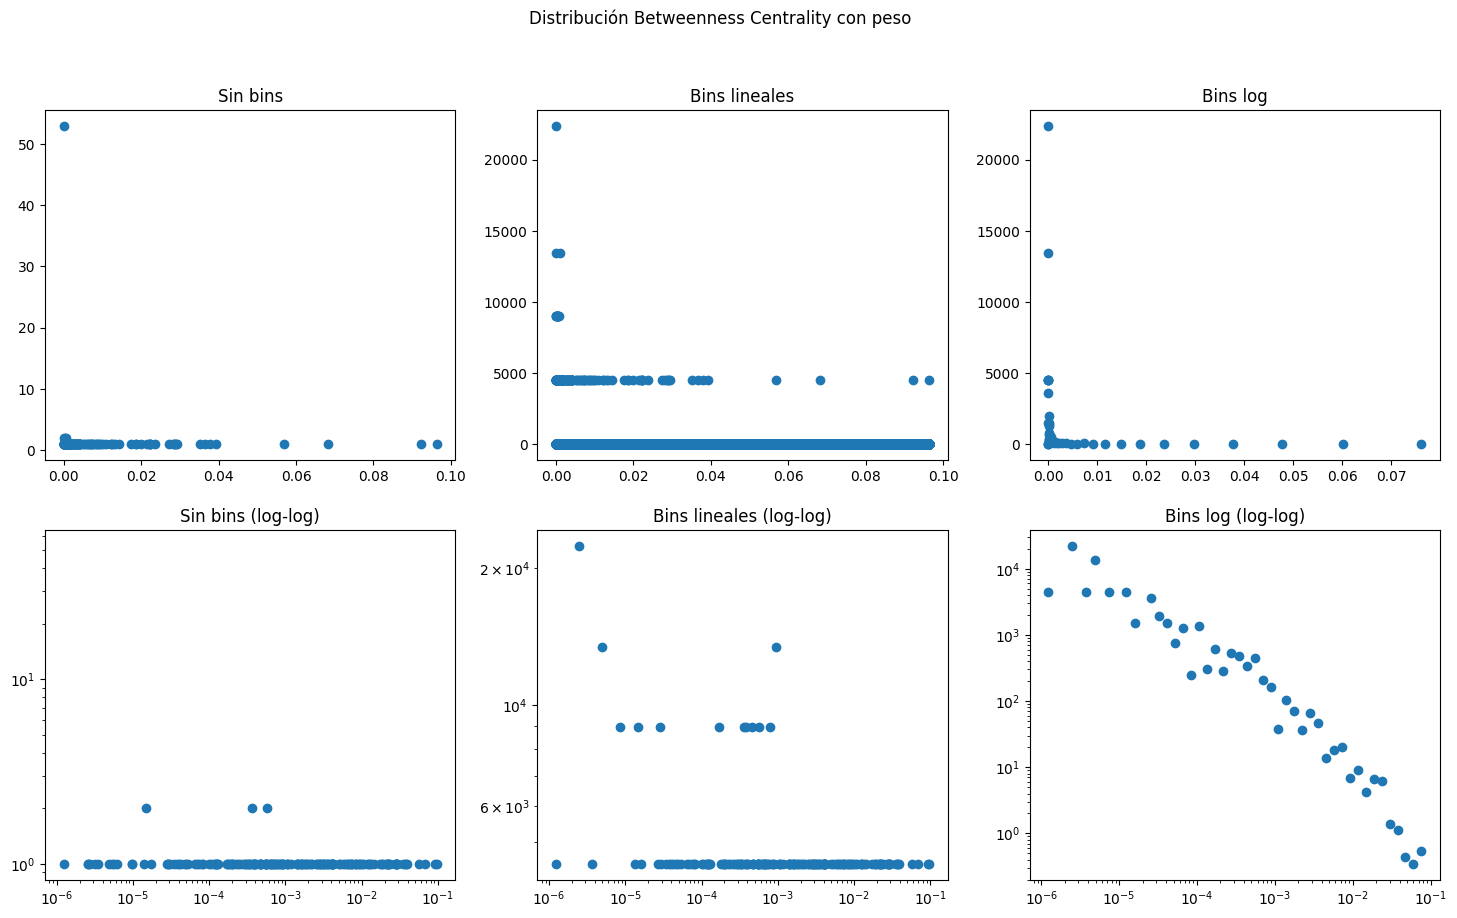

In [53]:
plot_distribution(list(betweenness_centrality_custom.values()),
                  "Distribución Betweenness Centrality con peso")

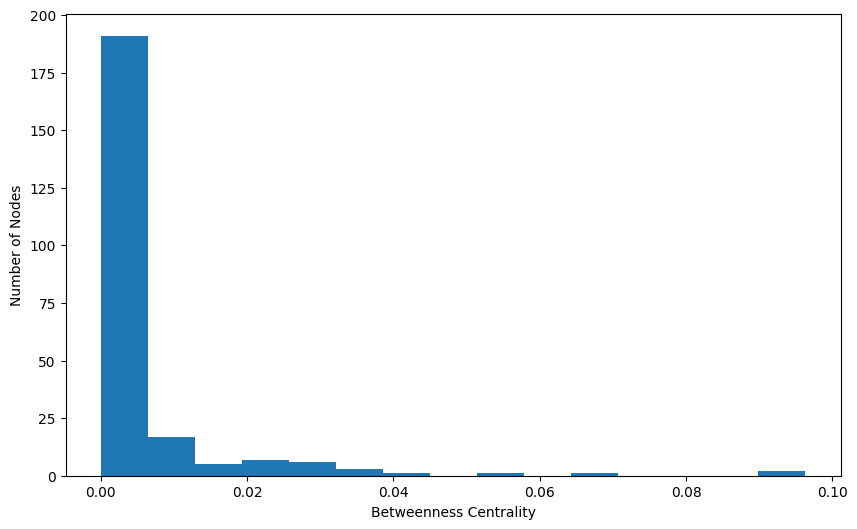

In [54]:
# Separar datos
personas = list(betweenness_centrality_custom.keys())
grados = list(betweenness_centrality_custom.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

# Proyección Bipartita Personalizada con attributos muligrafo

In [55]:
from utils import projected_graph_custom
# Obtener nodos de staff
staff_nodes = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}

# Proyección
G_staff_custom_multi = projected_graph_custom(B, staff_nodes, multigraph=True)

print(f"Number of nodes: {G_staff_custom_multi.number_of_nodes()}, Number of edges: {G_staff_custom_multi.number_of_edges()}")
nx.write_gexf(G_staff_custom_multi, "one_piece_staff_projection_custom_multigraph.gexf")

Number of nodes: 234, Number of edges: 9508


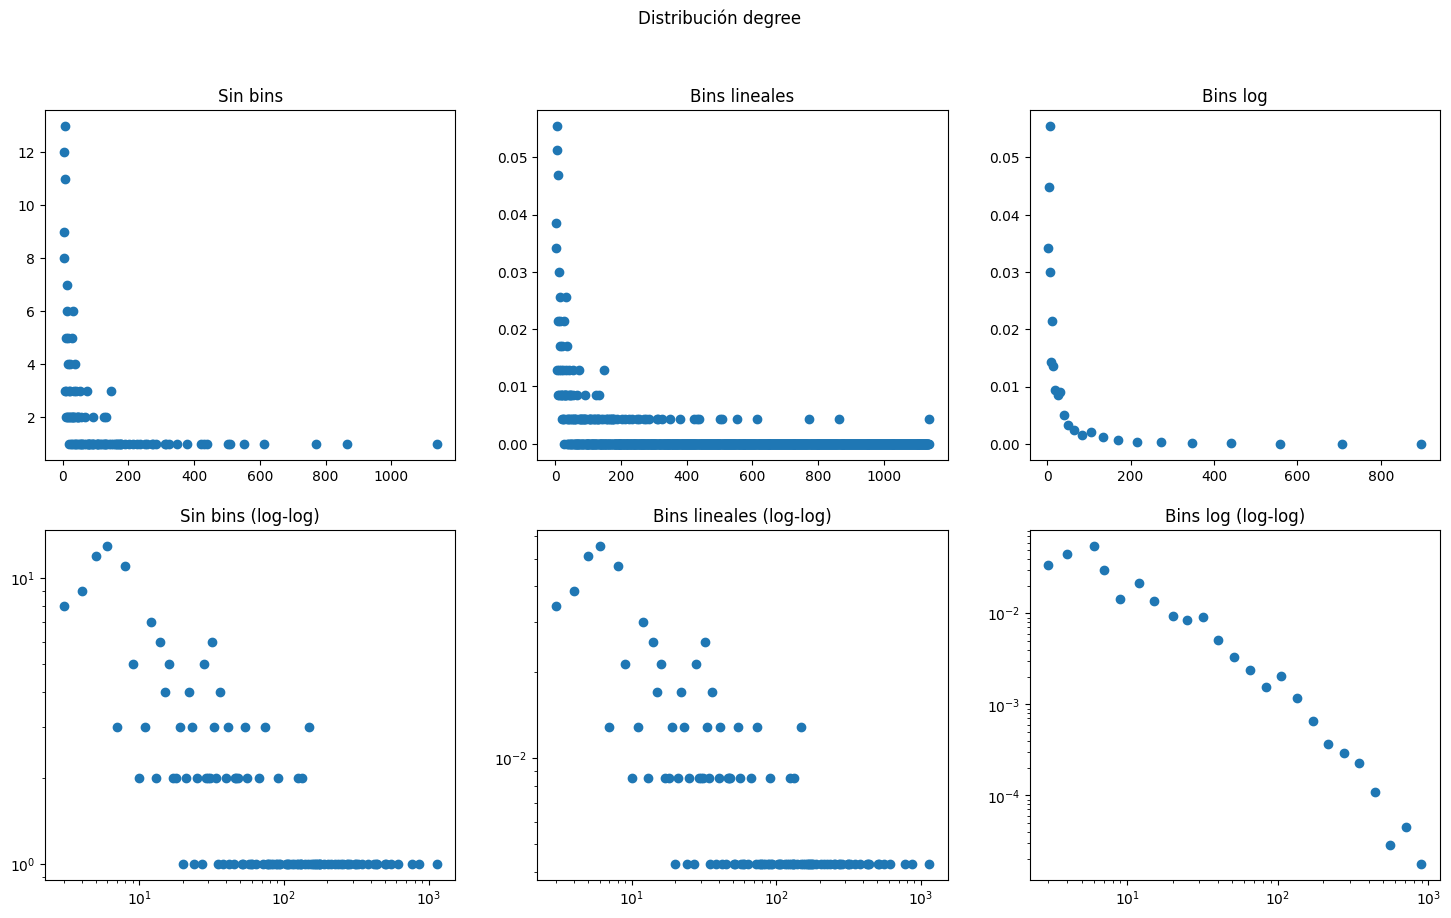

In [56]:
# distribucion de grados

degrees = [deg for _, deg in G_staff_custom_multi.degree()]

plot_distribution(degrees,
                  "Distribución degree")

In [57]:
# Componentes conectadas

components = list(nx.connected_components(G_staff_custom_multi))

print("Componentes conectadas")
print(f"Número de componentes: {len(components)}")

component_sizes = [len(c) for c in components]

print(f"Tamaño componente más grande: {max(component_sizes)}")

# componente gigante

largest_component = max(components, key=len)


print("Giant Component")
print(f"Nodos: {G_staff_custom_multi.number_of_nodes()}")
print(f"Aristas: {G_staff_custom_multi.number_of_edges()}")

Componentes conectadas
Número de componentes: 1
Tamaño componente más grande: 234
Giant Component
Nodos: 234
Aristas: 9508


In [58]:
avg_path_length = nx.average_shortest_path_length(G_staff_custom_multi)

print("Largo de camino característico")
print(f"Average shortest path length: {avg_path_length:.4f}")

Largo de camino característico
Average shortest path length: 2.1648


Centralidad de grado

In [59]:
degree_centrality_custom_multi = dict(G_staff_custom_multi.degree())

top = sorted(degree_centrality_custom_multi.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Miyuki Sato 1138
Miho Shiraishi 864
Ryūji Yoshiike 771
Hirohiko Kamisaka 613
Jin Tanaka 553
Kenji Yokoyama 509
Yoshiyuki Suga 503
Masayuki Takagi 438
Tomohiro Nakayama 431
Kazuya Hisada 422


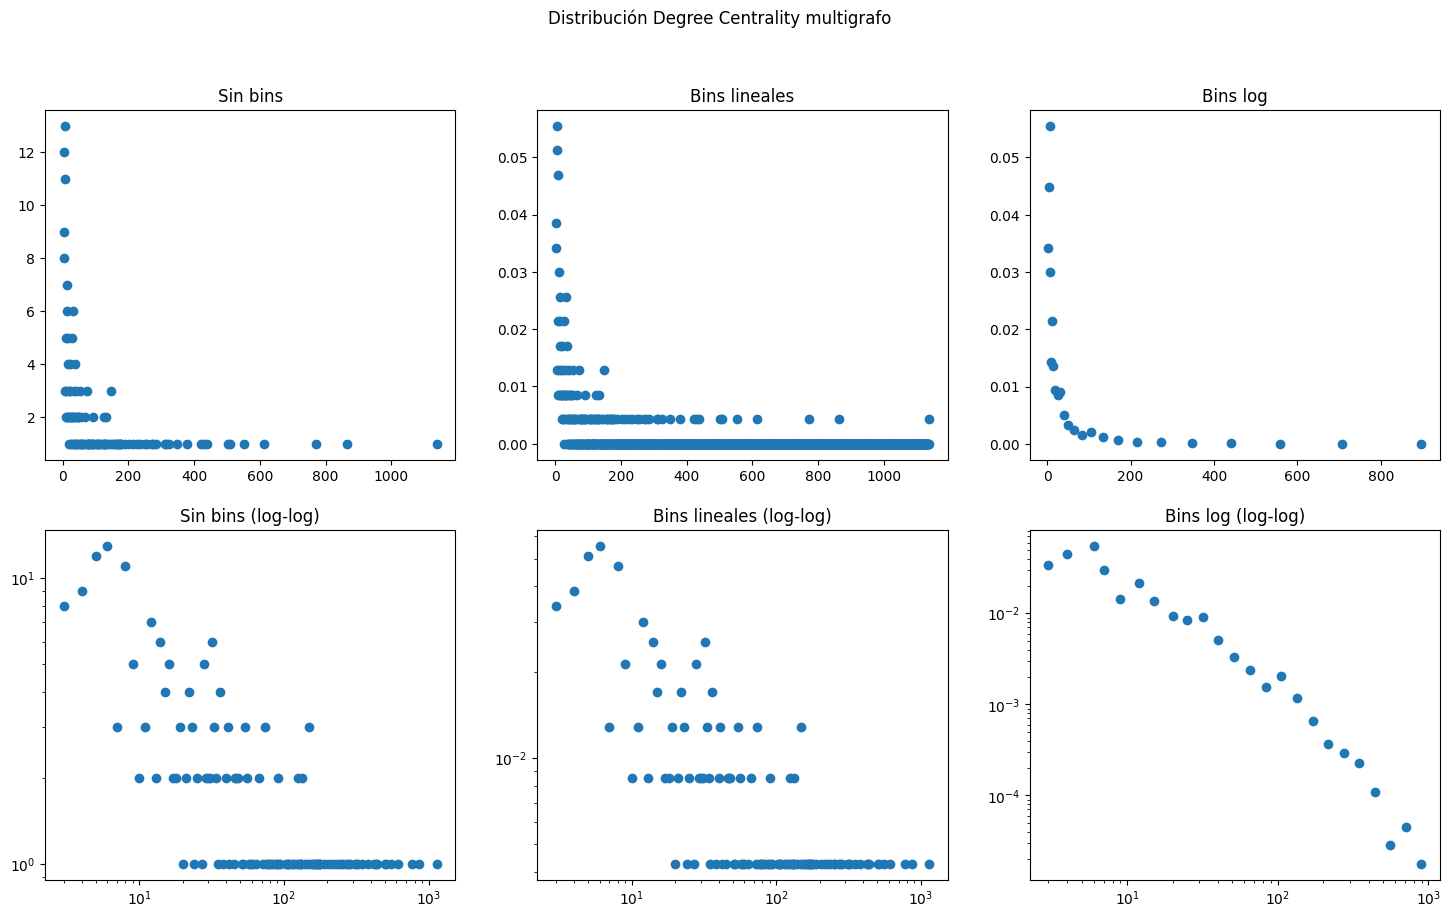

In [60]:
plot_distribution(list(degree_centrality_custom_multi.values()),
                  "Distribución Degree Centrality multigrafo")

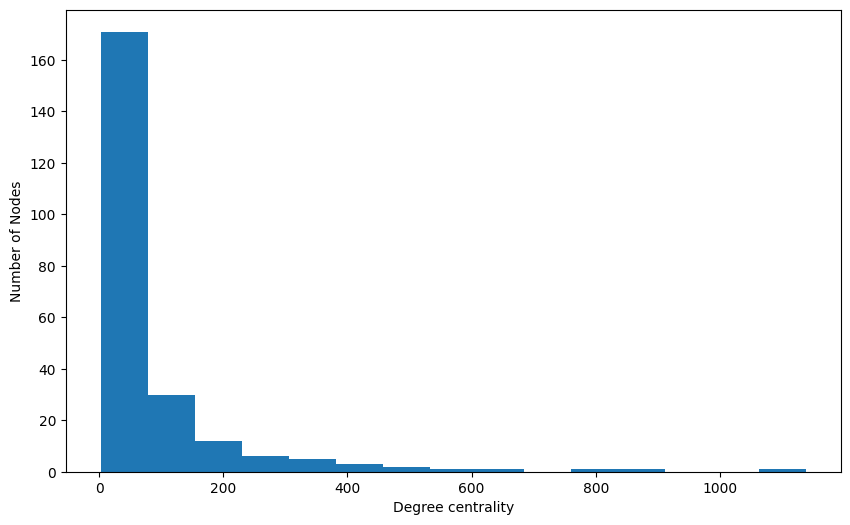

In [61]:
# Separar datos
personas = list(degree_centrality_custom_multi.keys())
grados = list(degree_centrality_custom_multi.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Degree centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Centralidad de grado normalizada

In [62]:
degree = nx.degree_centrality(G_staff_custom_multi)

top = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]

for name, deg in top:
    print(name, deg)

Miyuki Sato 4.884120171673819
Miho Shiraishi 3.708154506437768
Ryūji Yoshiike 3.3090128755364807
Hirohiko Kamisaka 2.630901287553648
Jin Tanaka 2.373390557939914
Kenji Yokoyama 2.184549356223176
Yoshiyuki Suga 2.1587982832618025
Masayuki Takagi 1.8798283261802575
Tomohiro Nakayama 1.849785407725322
Kazuya Hisada 1.8111587982832618


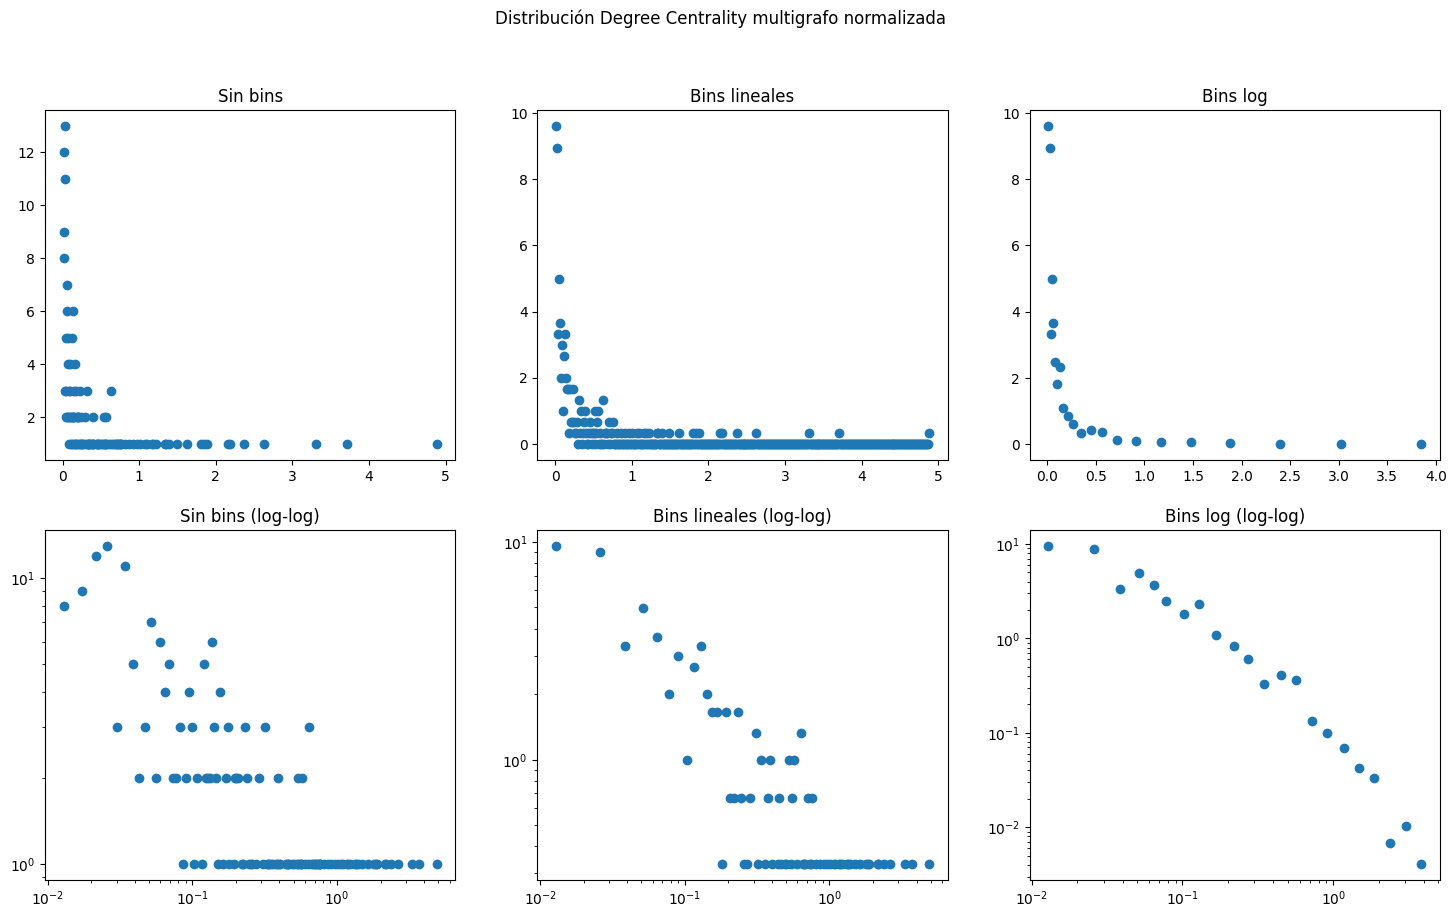

In [63]:
plot_distribution(list(degree.values()),
                  "Distribución Degree Centrality multigrafo normalizada")

Closeness

In [64]:
closeness_centrality_custom_multi = nx.closeness_centrality(G_staff_custom_multi)

top_closeness = sorted(closeness_centrality_custom_multi.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_closeness:
    print(name, val)

Kazuya Hisada 0.6544943820224719
Jin Tanaka 0.6508379888268156
Kenji Yokoyama 0.6383561643835617
Masayuki Takagi 0.6115485564304461
Masahiro Shimanuki 0.6005154639175257
Eisaku Inoue 0.6005154639175257
Miho Shiraishi 0.5974358974358974
Atsuhiro Tomioka 0.5943877551020408
Miyuki Sato 0.5913705583756346
Toshio Deguchi 0.5913705583756346


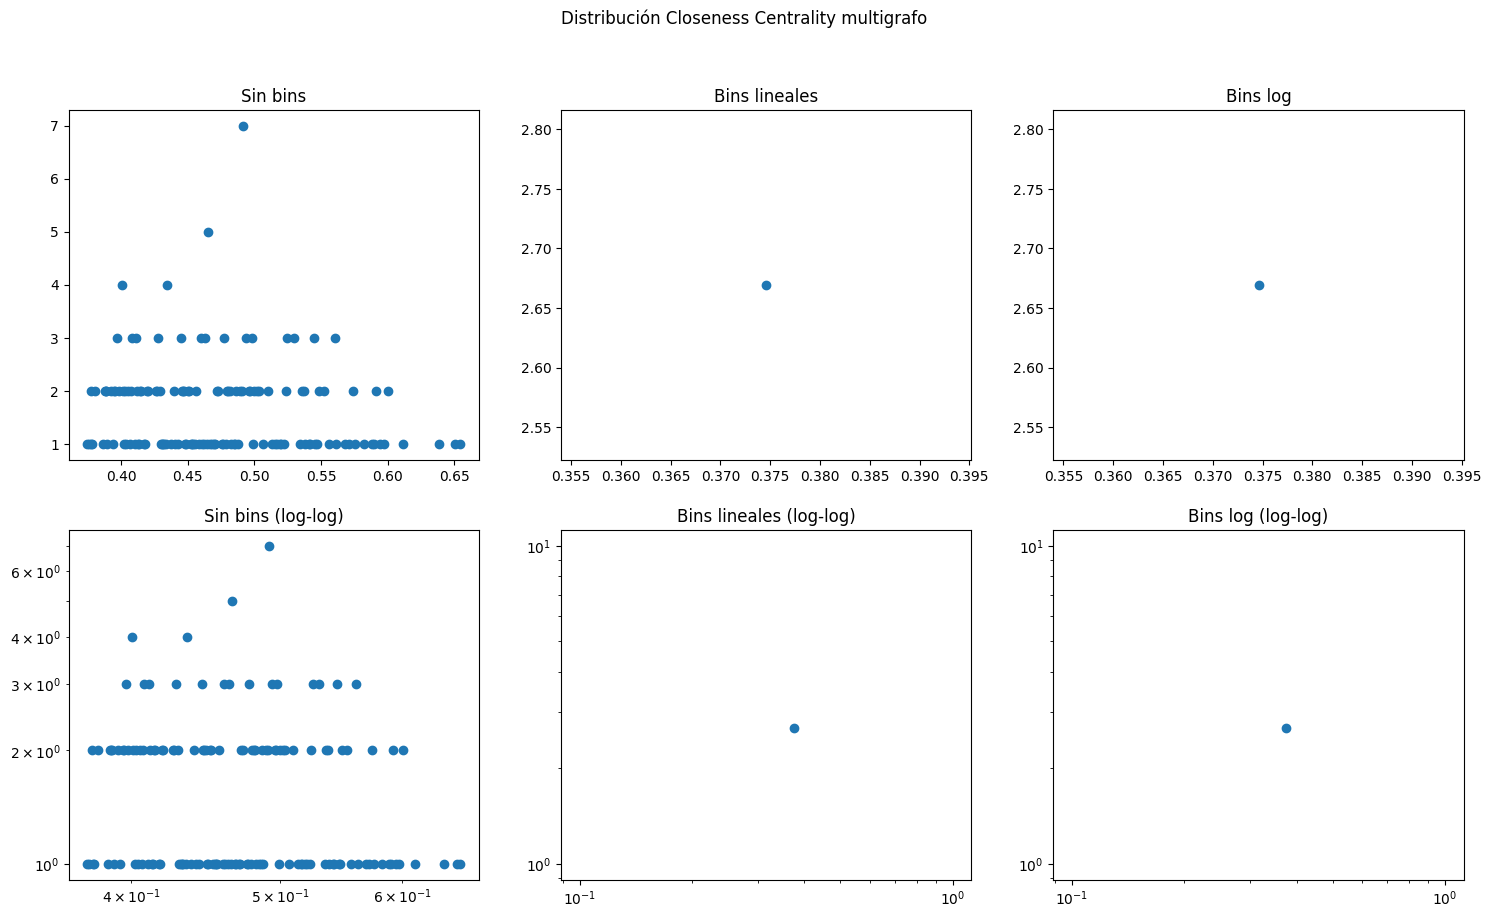

In [65]:
plot_distribution(list(closeness_centrality_custom_multi.values()),
                  "Distribución Closeness Centrality multigrafo")

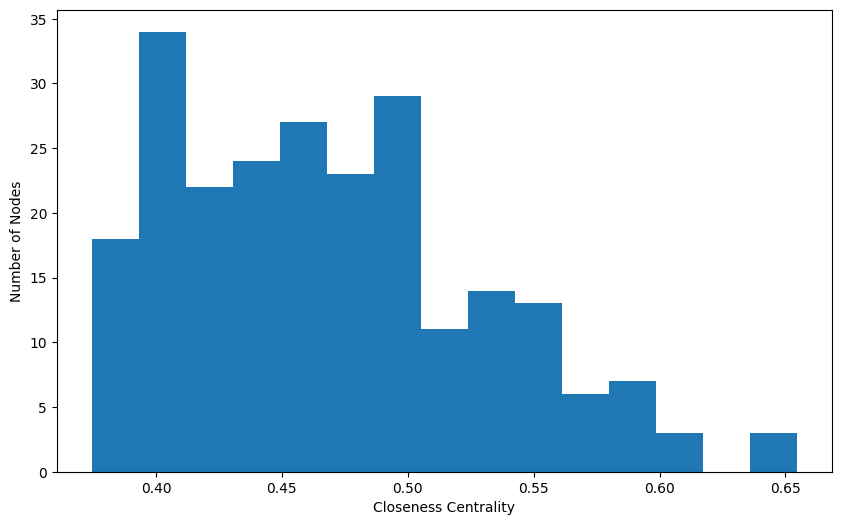

In [66]:
# Separar datos
personas = list(closeness_centrality_custom_multi.keys())
grados = list(closeness_centrality_custom_multi.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

Betwenness

In [67]:
betweenness_centrality_custom_multi = nx.betweenness_centrality(G_staff_custom_multi)

top_betweenness = sorted(betweenness_centrality_custom_multi.items(), key=lambda x: x[1], reverse=True)[:10]

for name, val in top_betweenness:
    print(name, val)

Jin Tanaka 0.09632341629318683
Kazuya Hisada 0.09226241779479234
Miyuki Sato 0.06822809191537474
Kenji Yokoyama 0.05688102366916951
Eisaku Inoue 0.0392753104366711
Masayuki Takagi 0.037858768374112214
Masahiro Kitazaki 0.0366136664119957
Atsuhiro Tomioka 0.035096357553010014
Masahiro Shimanuki 0.029312116593889322
Hirohiko Kamisaka 0.029078681665854218


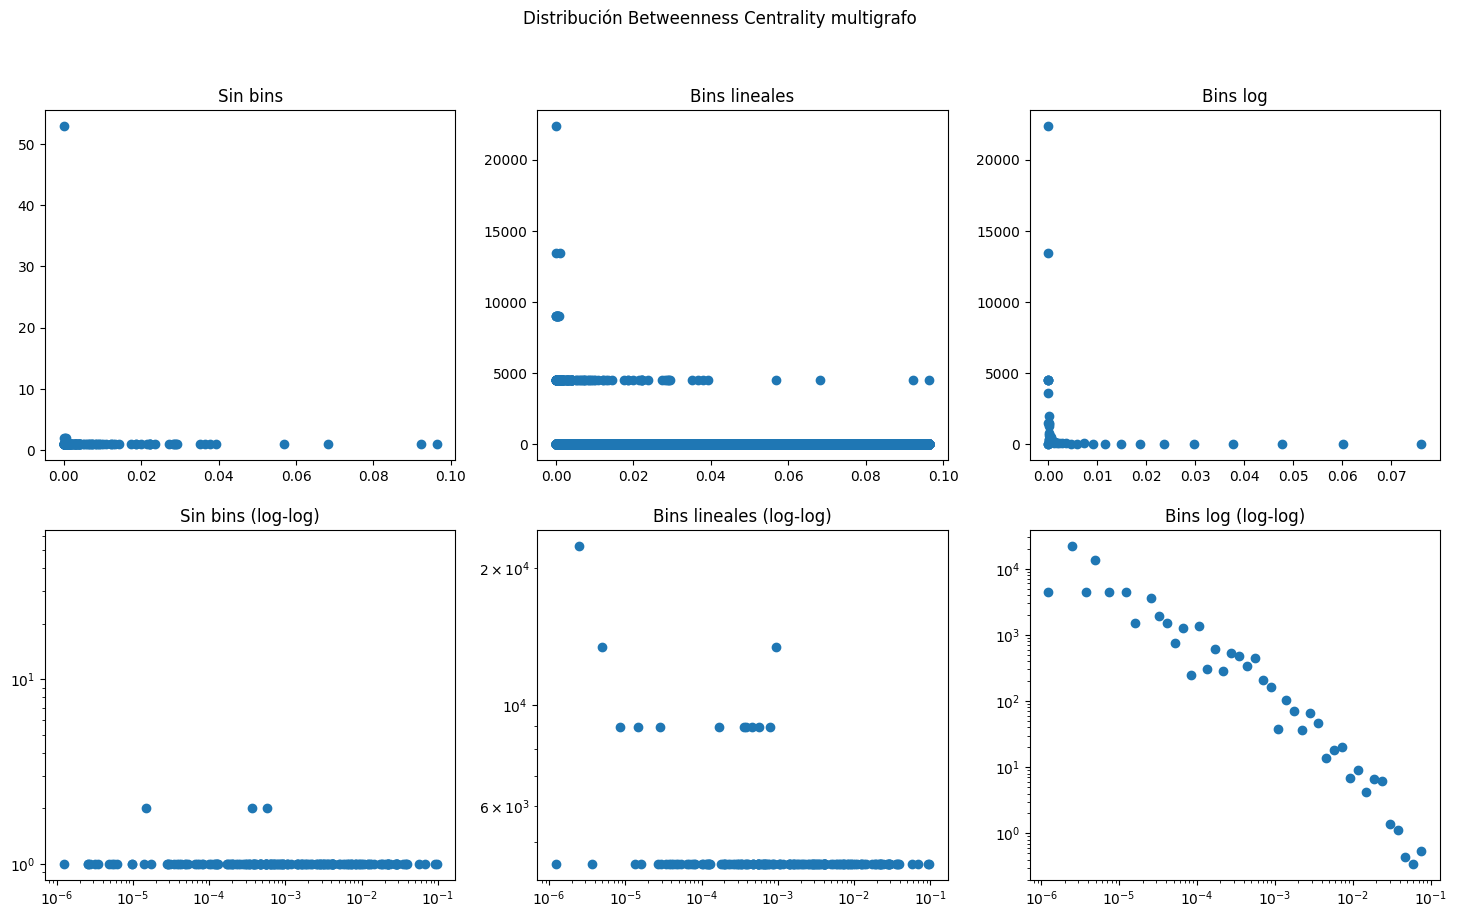

In [68]:
plot_distribution(list(betweenness_centrality_custom_multi.values()),
                  "Distribución Betweenness Centrality multigrafo")

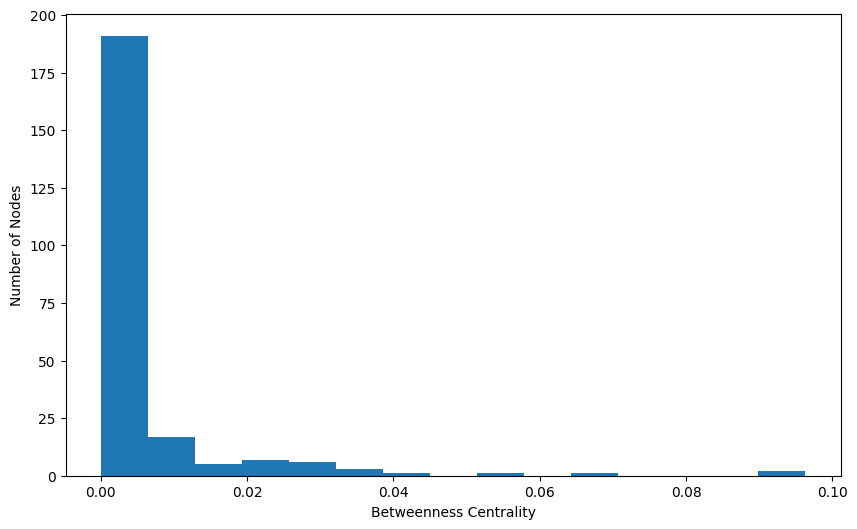

In [69]:
# Separar datos
personas = list(betweenness_centrality_custom_multi.keys())
grados = list(betweenness_centrality_custom_multi.values())

# Crear histograma de grados
plt.figure(figsize=(10, 6))
plt.hist(grados, bins=15)

# Etiquetas
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Nodes")

# Mostrar
plt.show()

# Spearman

In [70]:
director_rating = weighted_episode_rating(Gcc, df)

### Spearman para grafo bipartito

In [71]:

centralities = {
    "Degree": dict(degree_centrality_bipartite),
    "Betweenness":  dict(betweenness_bipartite),
    "Closeness": dict(closeness_bipartite),
    "Eigenvector": dict(eigenvector_centrality_bipartite)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.03426891784779111 p=0.6019769450777631
Betweenness rho=0.10333368566491329 p=0.11491990368439733
Closeness rho=0.021455558500637528 p=0.7440559556835208
Eigenvector rho=-0.16420130639336122 p=0.011888290283884467


### Spearman para proyeccion de networkx

In [72]:

centralities = {
    "Degree": dict(degree_centrality_nx),
    "Betweenness":  dict(betweenness_centrality_nx),
    "Closeness": dict(closeness_centrality_nx),
    "Eigenvector": dict(eigenvector_centrality_nx)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.23964573614470394 p=0.00021533720354371177
Betweenness rho=0.18591969668149852 p=0.004321096064756498
Closeness rho=0.244618339146348 p=0.00015715471819402352
Eigenvector rho=-0.1336596072590355 p=0.04106977598114102


### Spearman para proyeccion personalizada ponderada

In [73]:

centralities = {
    "Degree": dict(degree_centrality_custom),
    "Betweenness":  dict(betweenness_centrality_custom),
    "Closeness": dict(closeness_centrality_custom),
    "Eigenvector": dict(eigenvector_centrality_custom)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.23964573614470394 p=0.00021533720354371177
Betweenness rho=0.18591969668149852 p=0.004321096064756498
Closeness rho=0.244618339146348 p=0.00015715471819402352
Eigenvector rho=0.4063111632484563 p=1.0261594342016425e-10


### Spearman para proyeccion personalizada multigrafo

In [74]:

centralities = {
    "Degree": dict(degree_centrality_custom_multi),
    "Betweenness":  dict(betweenness_centrality_custom_multi),
    "Closeness": dict(closeness_centrality_custom_multi)
}

for name, metric in centralities.items():

    common_nodes = set(metric.keys()) & set(director_rating.keys())

    x = [metric[n] for n in common_nodes]
    y = [director_rating[n] for n in common_nodes]

    rho, p = spearmanr(x, y)

    print(
        f"{name} "
        f"rho={rho} "
        f"p={p}"
    )

Degree rho=0.11874877308339059 p=0.06980092932626596
Betweenness rho=0.18591969668149852 p=0.004321096064756498
Closeness rho=0.244618339146348 p=0.00015715471819402352


# Coeficiente de Mundo Pequeño

Hacemos nuestro propio caso para calcular el coeficiente de mundo pequeño, para comparar el coeficiente con las aproximaciones de un grafo ER equivalente.

In [75]:
import math

def small_world_coeff(G):
    C = nx.transitivity(G)
    L = nx.average_shortest_path_length(G)

    n = 234
    edges = 2878
    k = (2 * edges) / n

    C_r = k / n
    L_r = math.log(n) / math.log(k)

    sw = (C / C_r) / (L / L_r)

    return sw

In [76]:
small_world_2 = small_world_coeff(G_staff)

In [77]:
small_world = nx.sigma(G_staff, niter = 1, nrand=1, seed=1)

#print(small_world)

In [78]:
print(small_world)
print(small_world_2)

1.2872624432012403
2.8010277698018173


# Evolución del metricas a lo largo del tiempo

Primero veremos la evolución del rating promedio a medida que fueron surgiendo más capitulos

Text(0.5, 1.0, 'Evolución del rating promedio a lo largo del tiempo')

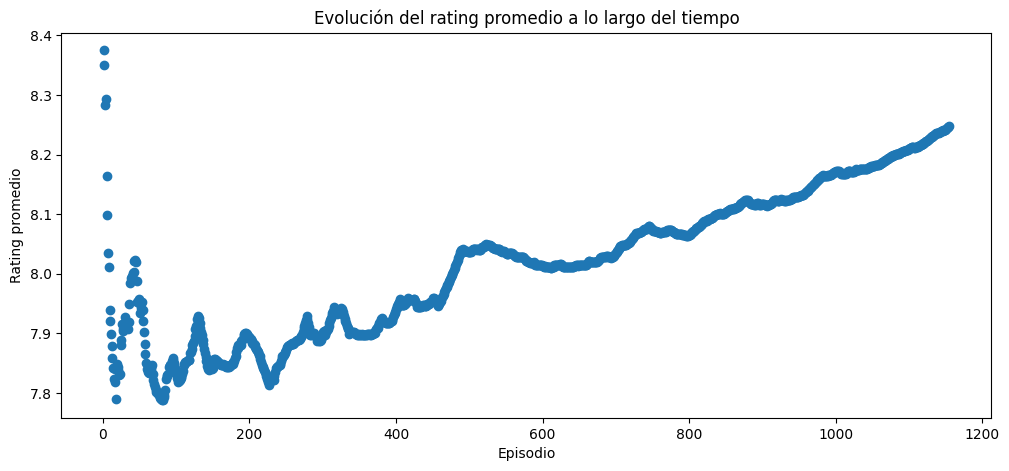

In [79]:
r_total = 0
cantidad = 0
rating_promedio = []
for _, row in df.iterrows():
    r_total += row['rating']
    cantidad += 1
    rating_promedio.append(r_total/cantidad)

x = df['episodio']
y = rating_promedio

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Rating promedio")
plt.title("Evolución del rating promedio a lo largo del tiempo")

Evolución del grafo por capitulo (para calcular y almacenar las metricas)

In [80]:
from utils import get_members_combination, avg_previous_team_rating, avg_previous_individual_exp, avg_previous_tm_exp, avg_previous_tm_shared_colabs, avg_previous_tm_betweenness, avg_previous_tm_closeness, avg_previous_tm_clustering_coeff
# Columnas donde hay listas de personas
staff_columns = ["guion", "arte", "animacion", "direccion"]
value_columns = ["n de paginas", "rating", "votos"]

# Igual a como se realizó inicialmente la generación del grafo, solo que con un paso extra entre medio
B = nx.Graph()
# Definir como None para marcar el paso inicial
G_temp = None
betweenness_temp = None
staff_nodes_temp = {}
# Acá añadir las listas de metricas a almacenar a lo largo del tiempo
avg_closeness = []
avg_betweenness = []
avg_path_len = []
avg_degree_normalized = []
avg_degree = []
# Metricas de viana
avg_previous_tm_exp_list = []
avg_previous_tm_shared_colabs_list = []
avg_previous_tm_clustering_coeff_list = []
avg_previous_tm_closeness_list = []
avg_previous_tm_betweenness_list = []
avg_previous_individual_exp_list = []
avg_previous_team_rating_list = []

for _, row in df.iterrows():
    episodio = f"ep_{int(row['episodio'])}"
    B_prev = B
    B.add_node(episodio, bipartite="episode")

    value_dict = {}
    for val in value_columns:
        value_dict[val] = row[val]
    
    nx.set_node_attributes(B, {episodio: value_dict})
    colabs = []
    for col in staff_columns:
        personas = parse_list(row[col])
        
        for persona in personas:
            persona_clean = persona.split("(")[0].strip()

            # Agregar nodo persona
            if persona_clean == '':
                continue
            colabs.append(persona_clean)
            B.add_node(persona_clean, bipartite="staff")

            # Agregar arista
            B.add_edge(persona_clean, episodio)
    
    staff_nodes_temp = {n for n, d in B.nodes(data=True) if d["bipartite"] == "staff"}
    G_prev = G_temp
    G_temp = projected_graph_custom(B, staff_nodes_temp)

    # Introducir metricas a calcular :)
    # Closeness promedio
    avg_closeness.append(np.mean(list(nx.closeness_centrality(G_temp).values())))
    # Largo del camino característico
    if nx.connected.is_connected(G_temp):
        avg_path_len.append(nx.average_shortest_path_length(G_temp))
    else:
        avg_path_len.append(None)
    # Grado promedio normalizado y grado promedio
    avg_degree_normalized.append(np.mean(list(nx.degree_centrality(G_temp).values())))
    avg_degree.append(np.mean(list(dict(G_temp.degree()).values())))
    # Betweenness promedio
    betweenness_prev = betweenness_temp
    betweenness_temp = nx.betweenness_centrality(G_temp)
    avg_betweenness.append(np.mean(list(betweenness_temp.values())))

    # Conjunto de pares de colaboradores para el episodio actual
    pares_colab = get_members_combination(colabs)
    largo_pares = len(pares_colab)

    largo_colabs = len(colabs)

    # Experiencia previa promedio del equipo
    if not G_prev:
        avg_previous_tm_exp_list.append(0)
        avg_previous_tm_shared_colabs_list.append(0)
        avg_previous_tm_clustering_coeff_list.append(0)
        avg_previous_tm_closeness_list.append(0)
        avg_previous_tm_betweenness_list.append(0)
        avg_previous_individual_exp_list.append(0)
        avg_previous_team_rating_list.append(0)
    else:
        avg_previous_tm_exp_list.append(avg_previous_tm_exp(G_prev, pares_colab, largo_pares))
        avg_previous_tm_shared_colabs_list.append(avg_previous_tm_shared_colabs(G_prev, pares_colab, largo_pares))
        avg_previous_tm_clustering_coeff_list.append(avg_previous_tm_clustering_coeff(G_prev, colabs, largo_colabs))
        avg_previous_tm_closeness_list.append(avg_previous_tm_closeness(G_prev, colabs, largo_colabs))
        avg_previous_tm_betweenness_list.append(avg_previous_tm_betweenness(G_prev, colabs, betweenness_prev, largo_colabs))
        avg_previous_individual_exp_list.append(avg_previous_individual_exp(B_prev, colabs, largo_colabs))
        avg_previous_team_rating_list.append(avg_previous_team_rating(B_prev, colabs, largo_colabs))
    

Betweenness a lo largo del tiempo

Text(0.5, 1.0, 'Evolución de betweenness')

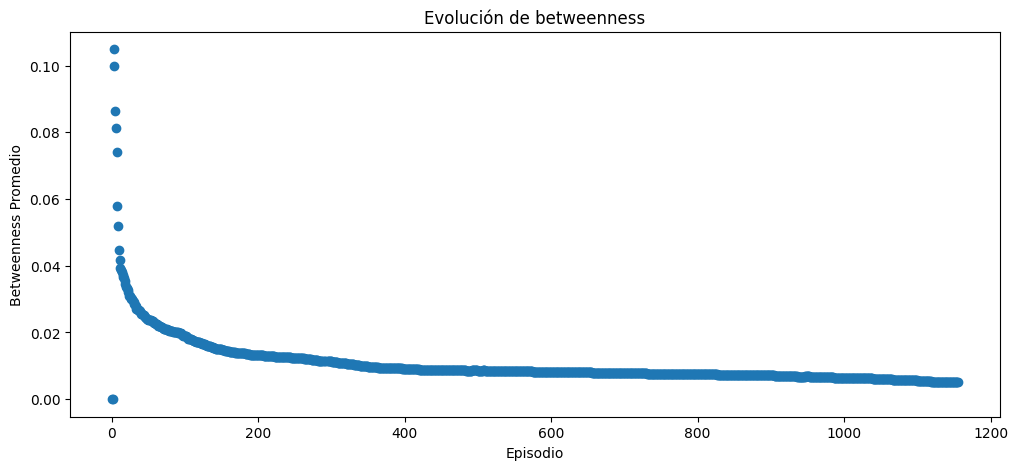

In [81]:
y = avg_betweenness

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Betweenness Promedio")
plt.title("Evolución de betweenness")

Closeness a lo largo del tiempo

Text(0.5, 1.0, 'Evolución de Closeness')

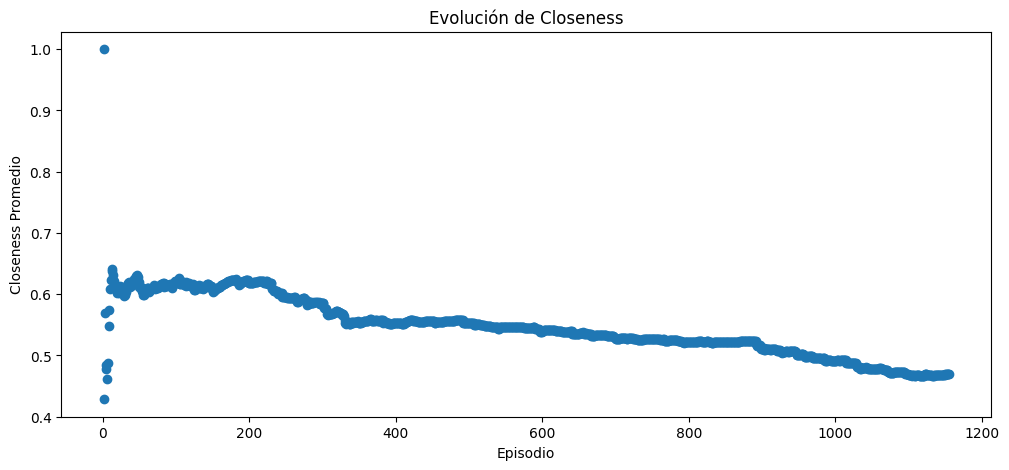

In [82]:
y = avg_closeness

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Closeness Promedio")
plt.title("Evolución de Closeness")

Grado normalizado promedio a lo largo del tiempo

Text(0.5, 1.0, 'Evolución de grado normalizado')

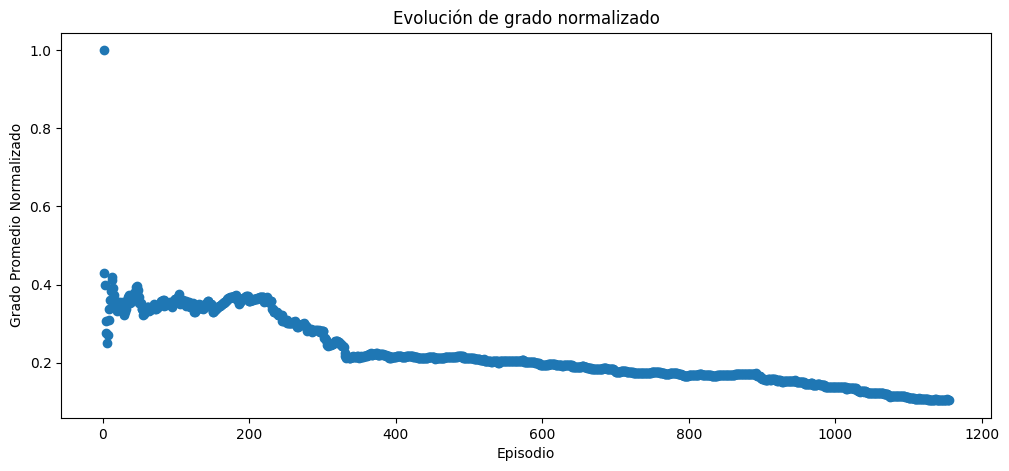

In [83]:
y = avg_degree_normalized

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Grado Promedio Normalizado")
plt.title("Evolución de grado normalizado")

Grado promedio a lo largo del tiempo

Text(0.5, 1.0, 'Evolución de grado')

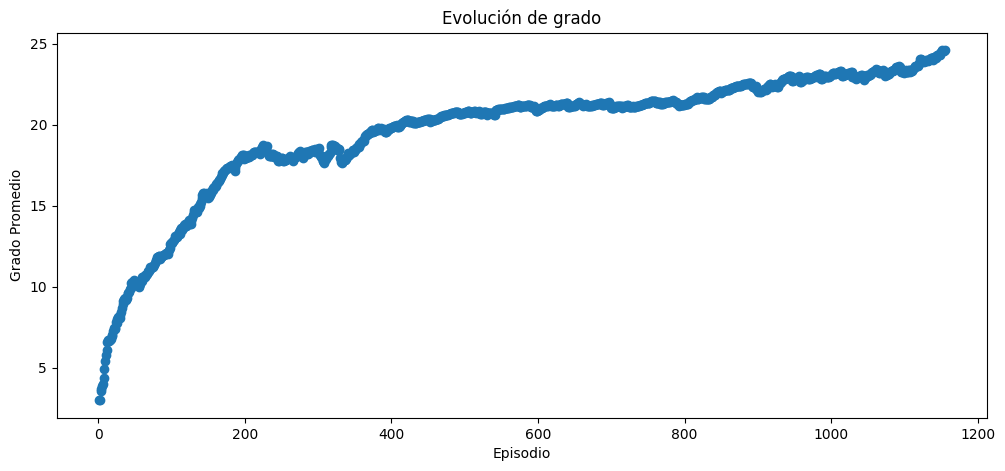

In [84]:
y = avg_degree

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Grado Promedio")
plt.title("Evolución de grado")

Largo del camino caracteristico a lo largo del tiempo

Text(0.5, 1.0, 'Evolución del camino característico')

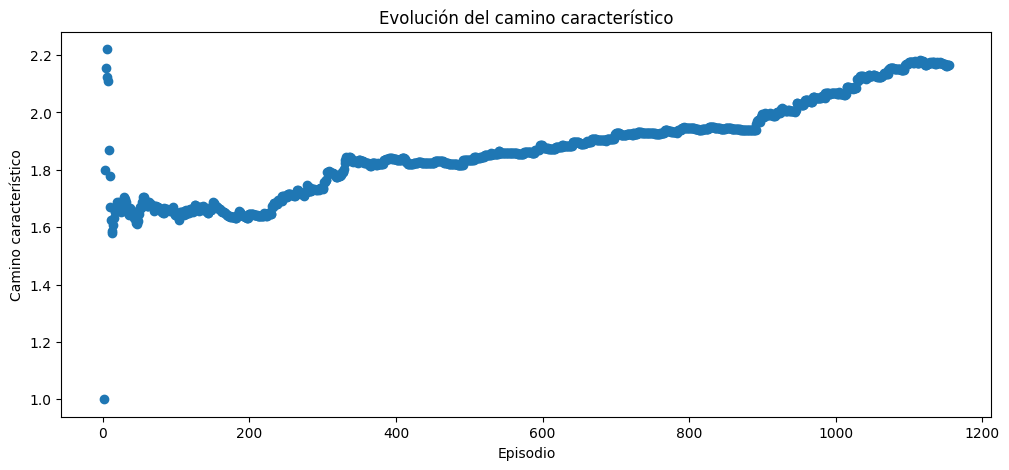

In [85]:
y = avg_path_len

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Camino característico")
plt.title("Evolución del camino característico")

# Metricas de Viana por episodio

Experiencia previa promedio por equipo por episodio

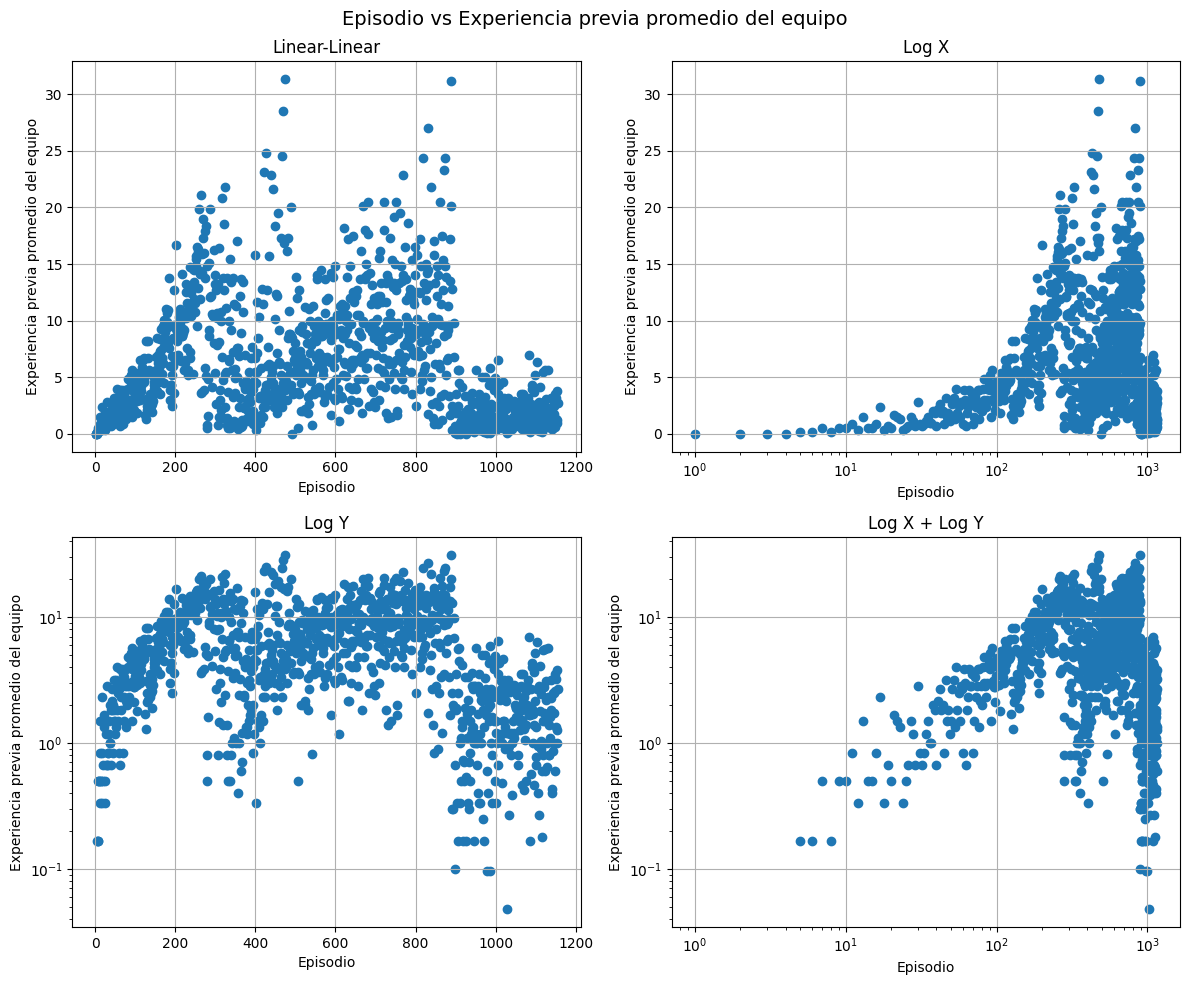

In [86]:
y = avg_previous_tm_exp_list

x_name = "Episodio"
y_name = "Experiencia previa promedio del equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

Promedio de colaboraciones previas por equipo

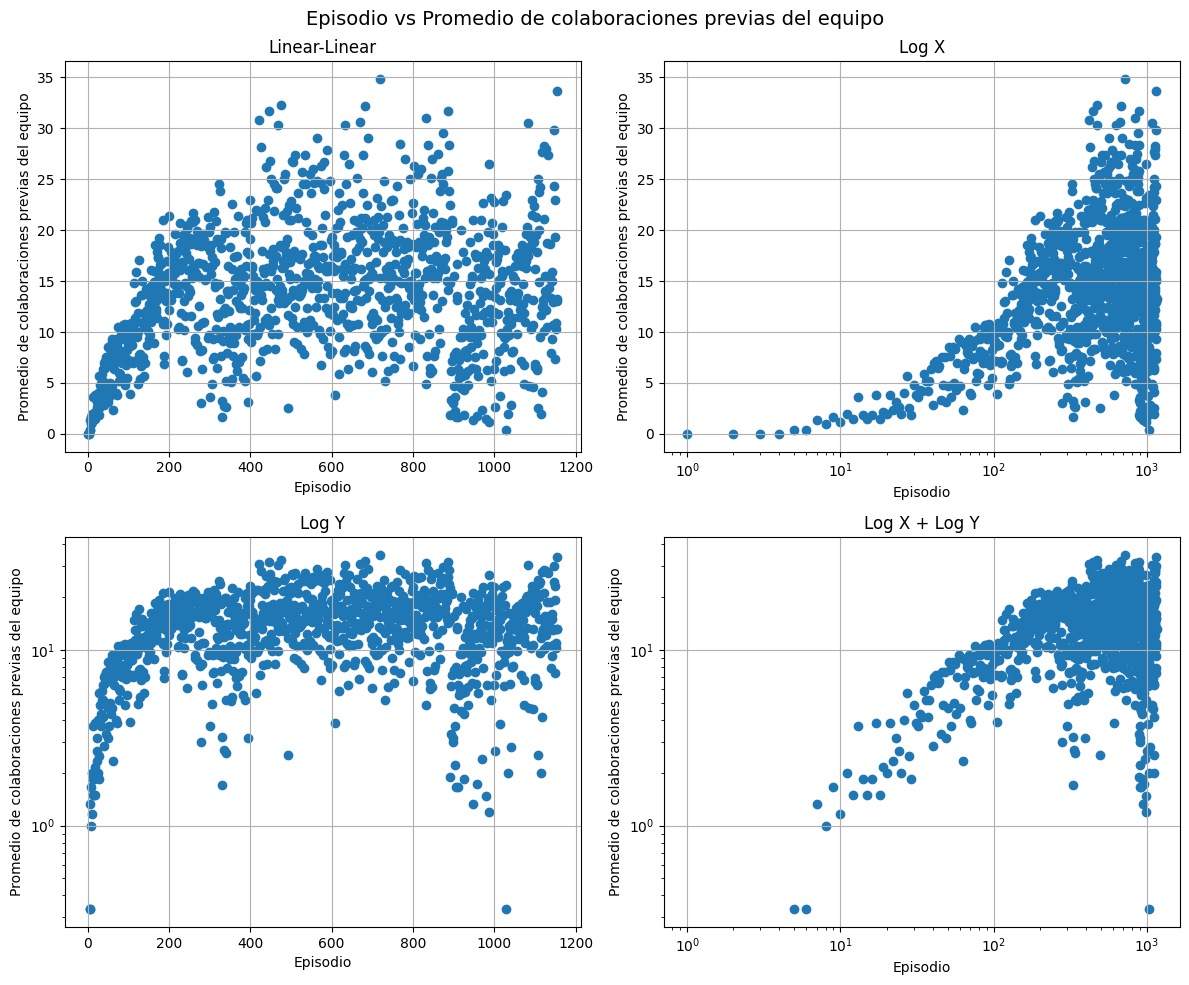

In [87]:
y = avg_previous_tm_shared_colabs_list

y_name = "Promedio de colaboraciones previas del equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

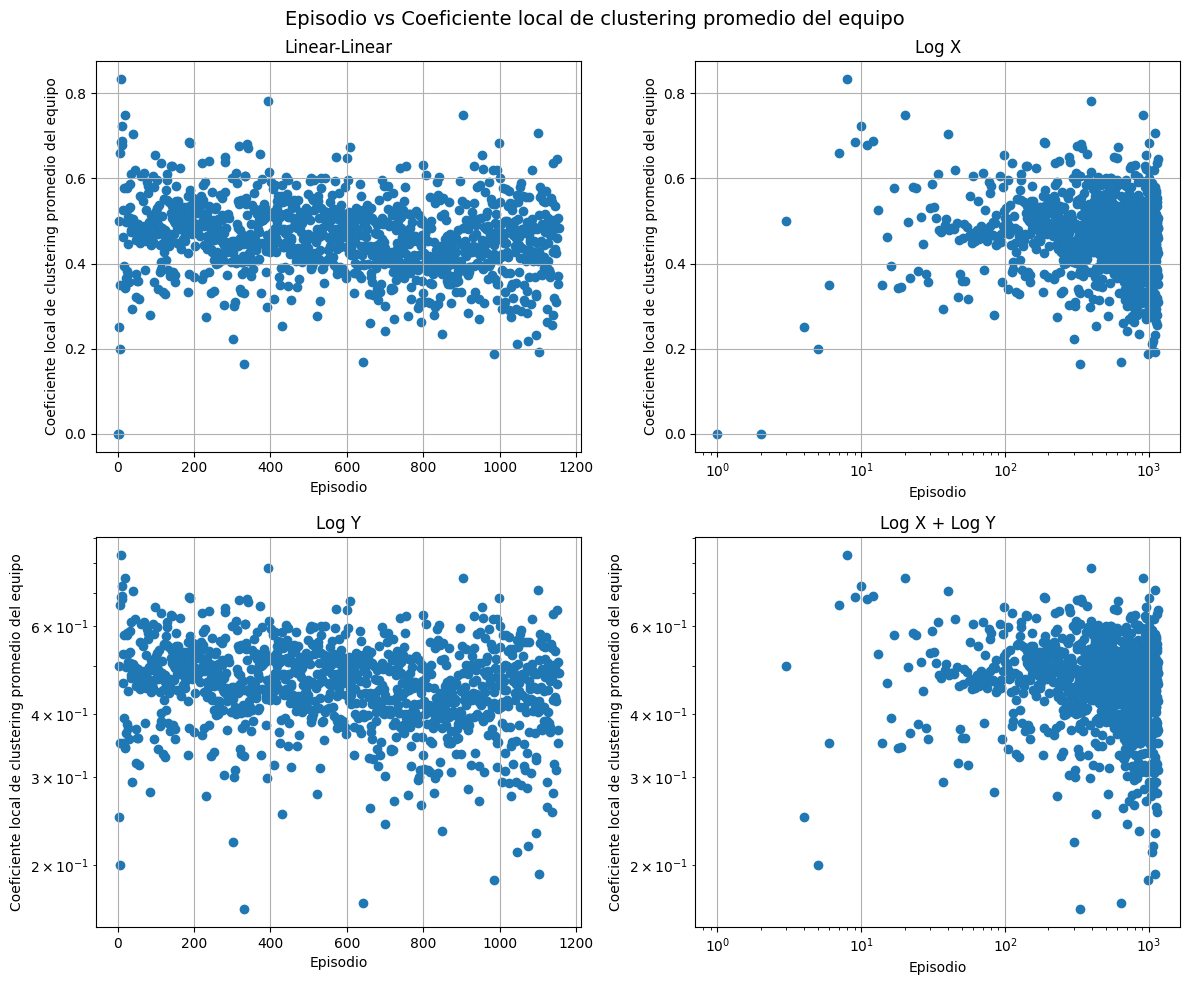

In [88]:
y = avg_previous_tm_clustering_coeff_list

y_name = "Coeficiente local de clustering promedio del equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

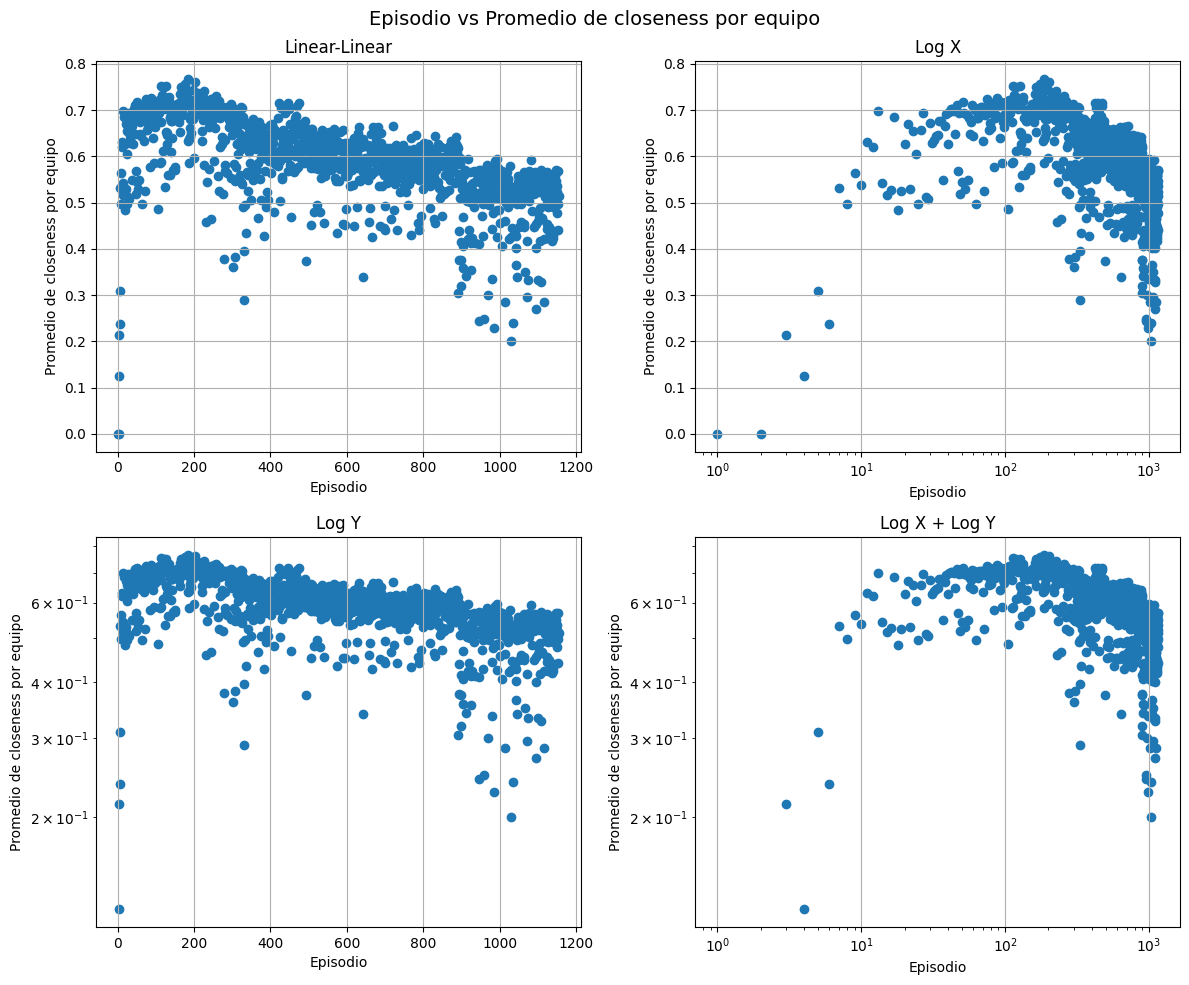

In [89]:
y = avg_previous_tm_closeness_list

y_name = "Promedio de closeness por equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

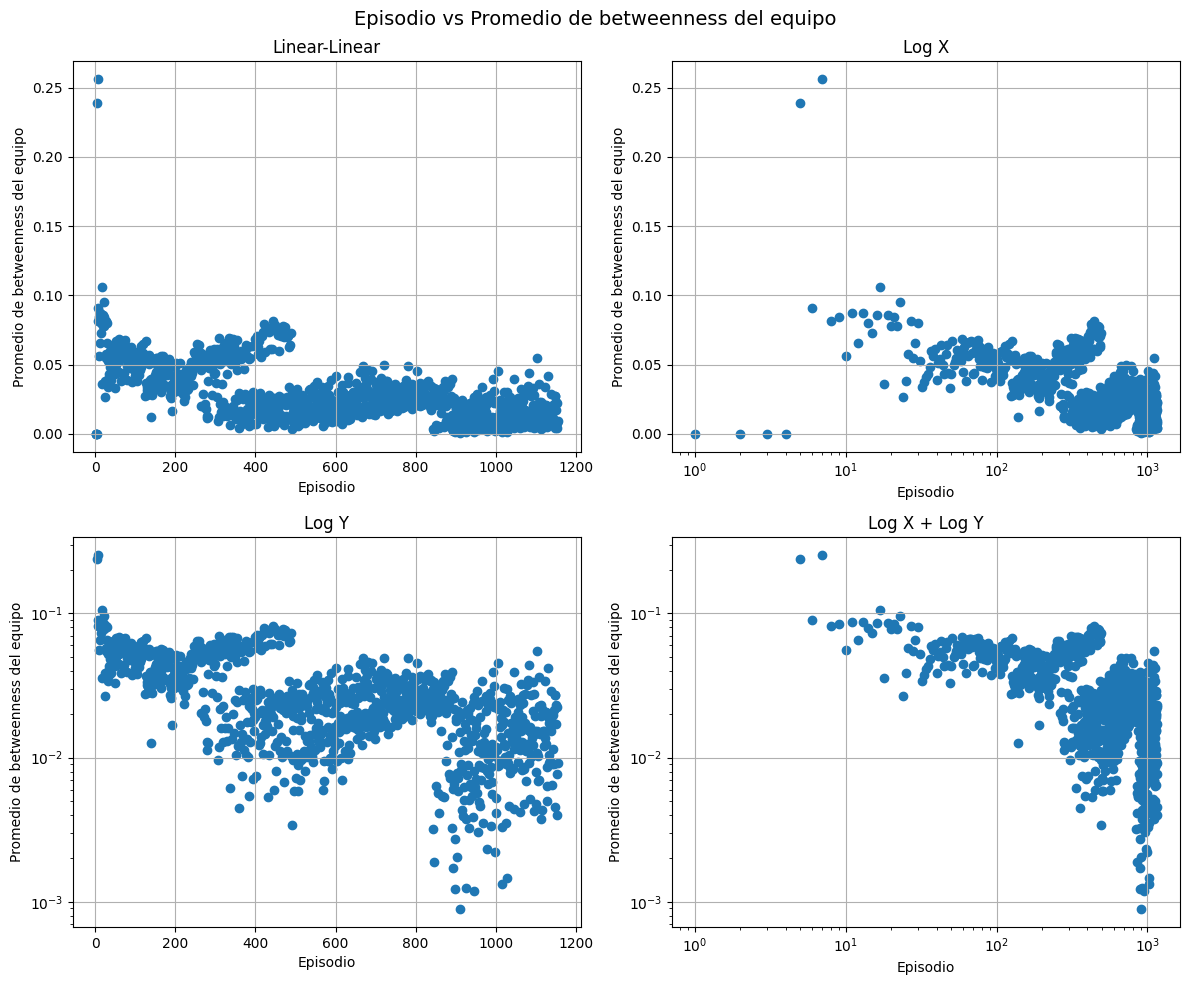

In [90]:
y = avg_previous_tm_betweenness_list

y_name = "Promedio de betweenness del equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

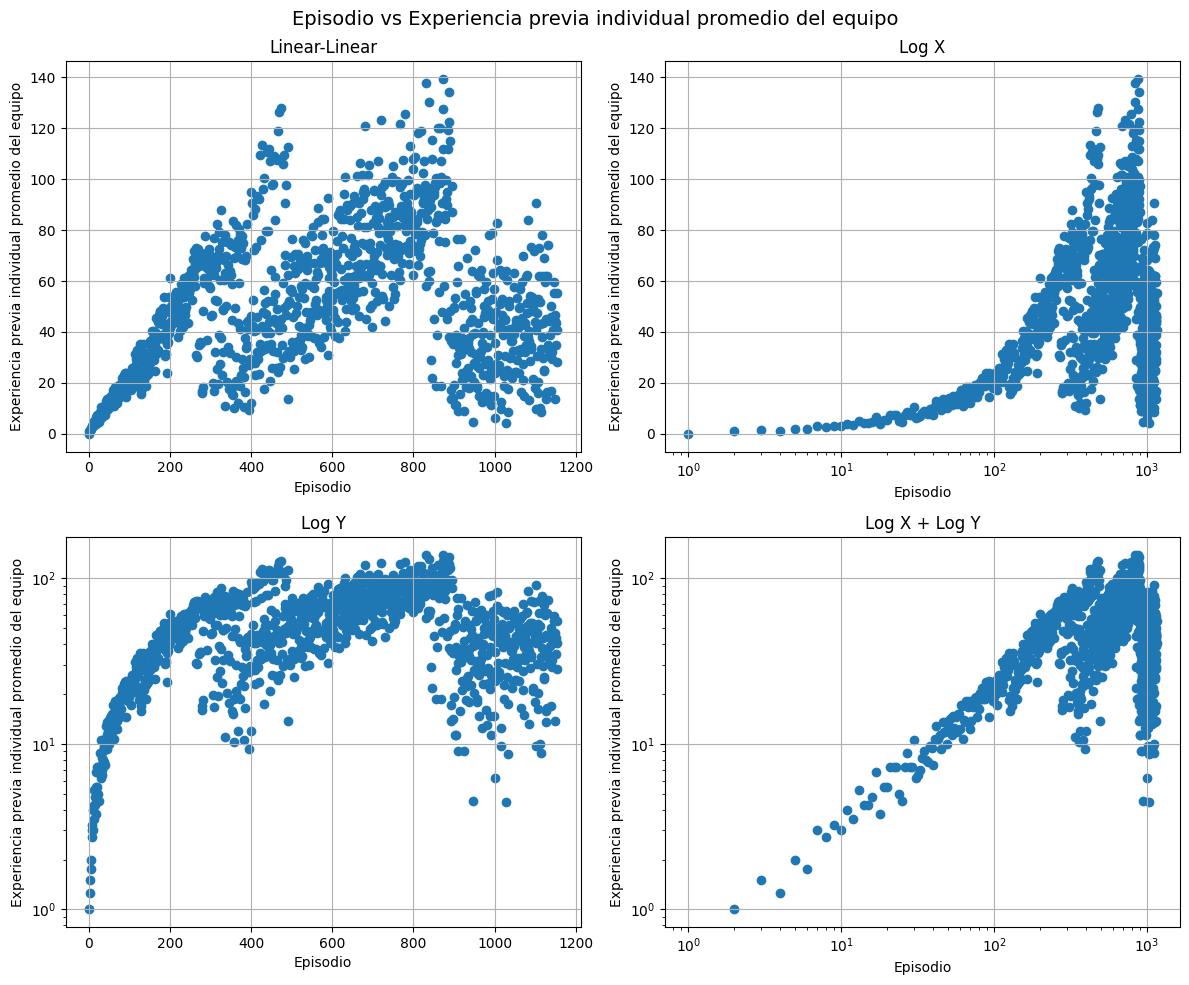

In [91]:
y = avg_previous_individual_exp_list

y_name = "Experiencia previa individual promedio del equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

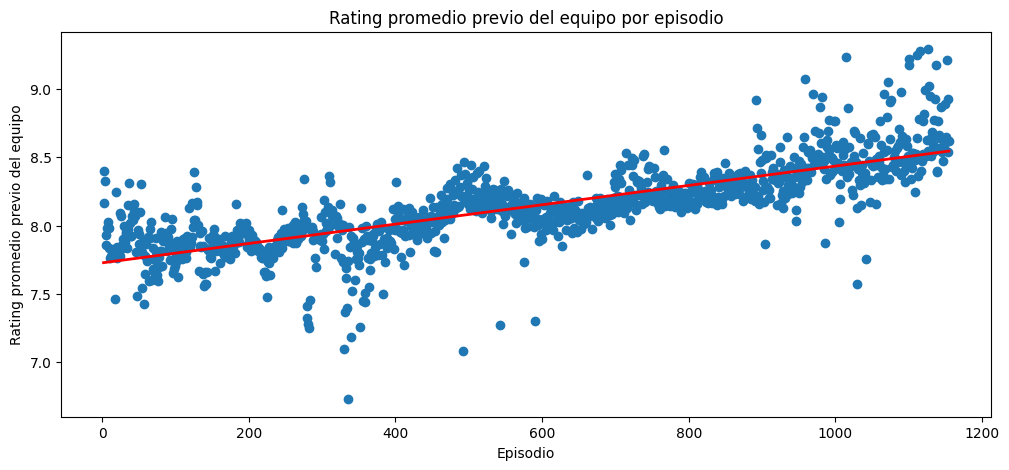

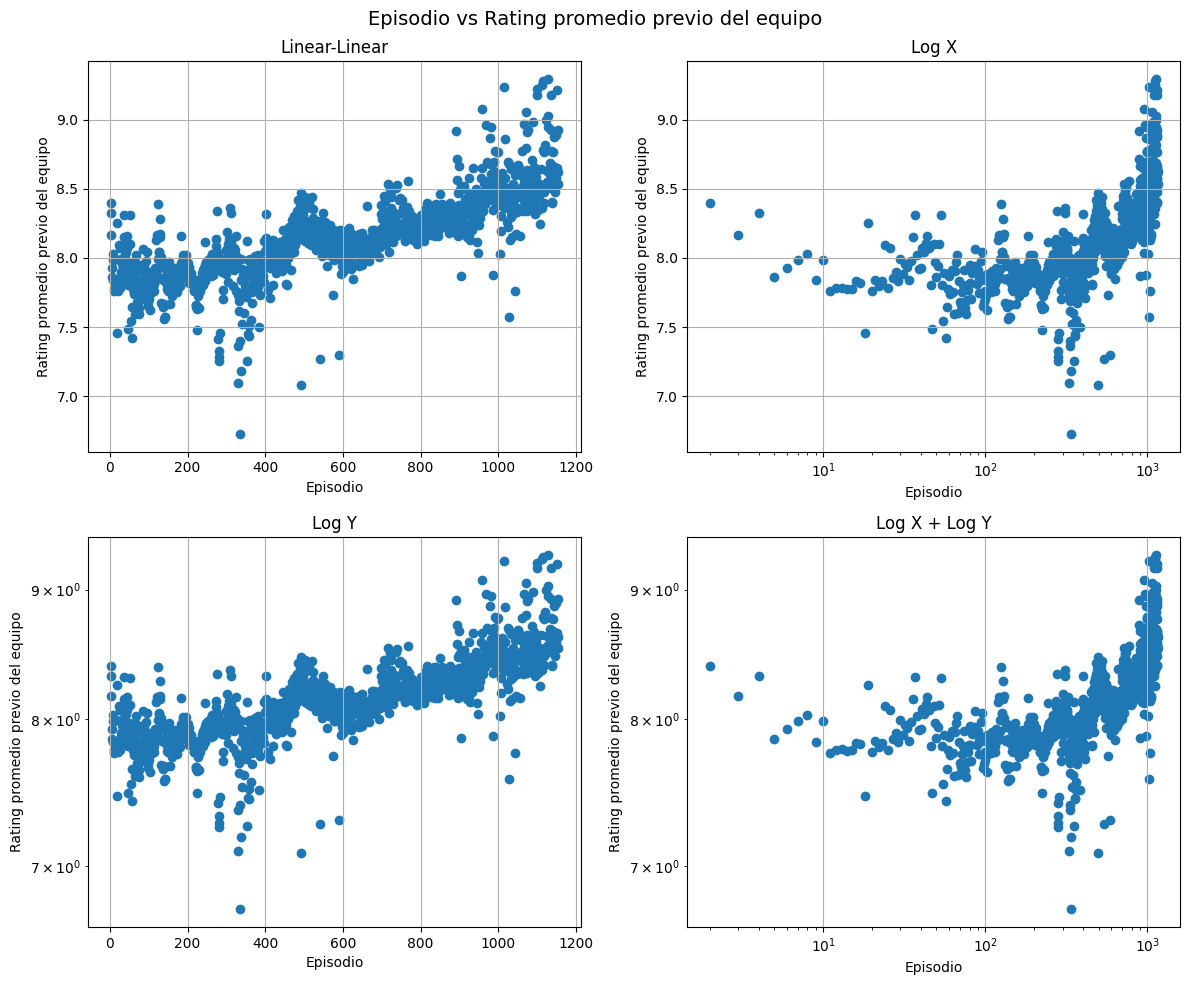

In [92]:
x1 = x[1:]
y = avg_previous_team_rating_list[1:]

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x1, y)

x_arr = np.array(x1)
y_arr = np.array(y)

# np.polyfit calcula la pendiente (m) y la intersección (b) con un polinomio de grado 1 (recta)
m, b = np.polyfit(x_arr, y_arr, 1)

# Creamos puntos en el eje x desde el mínimo al máximo para dibujar la recta de forma continua
x_recta = np.linspace(x_arr.min(), x_arr.max(), 100)
y_recta = m * x_recta + b

# Dibujamos la recta sobre el plot
plt.plot(x_recta, y_recta, color='red', linewidth=2, label=f'Tendencia promedio (y = {m:.2f}x + {b:.2f})')
# ----

plt.xlabel("Episodio")
plt.ylabel("Rating promedio previo del equipo")
plt.title("Rating promedio previo del equipo por episodio")

y_name = "Rating promedio previo del equipo"
# plot de distribución
plot_metric_vs_metric(x1, y, x_name, y_name)

# Metricas de Viana versus el rating

Experiencia previa promedio por equipo por episodio

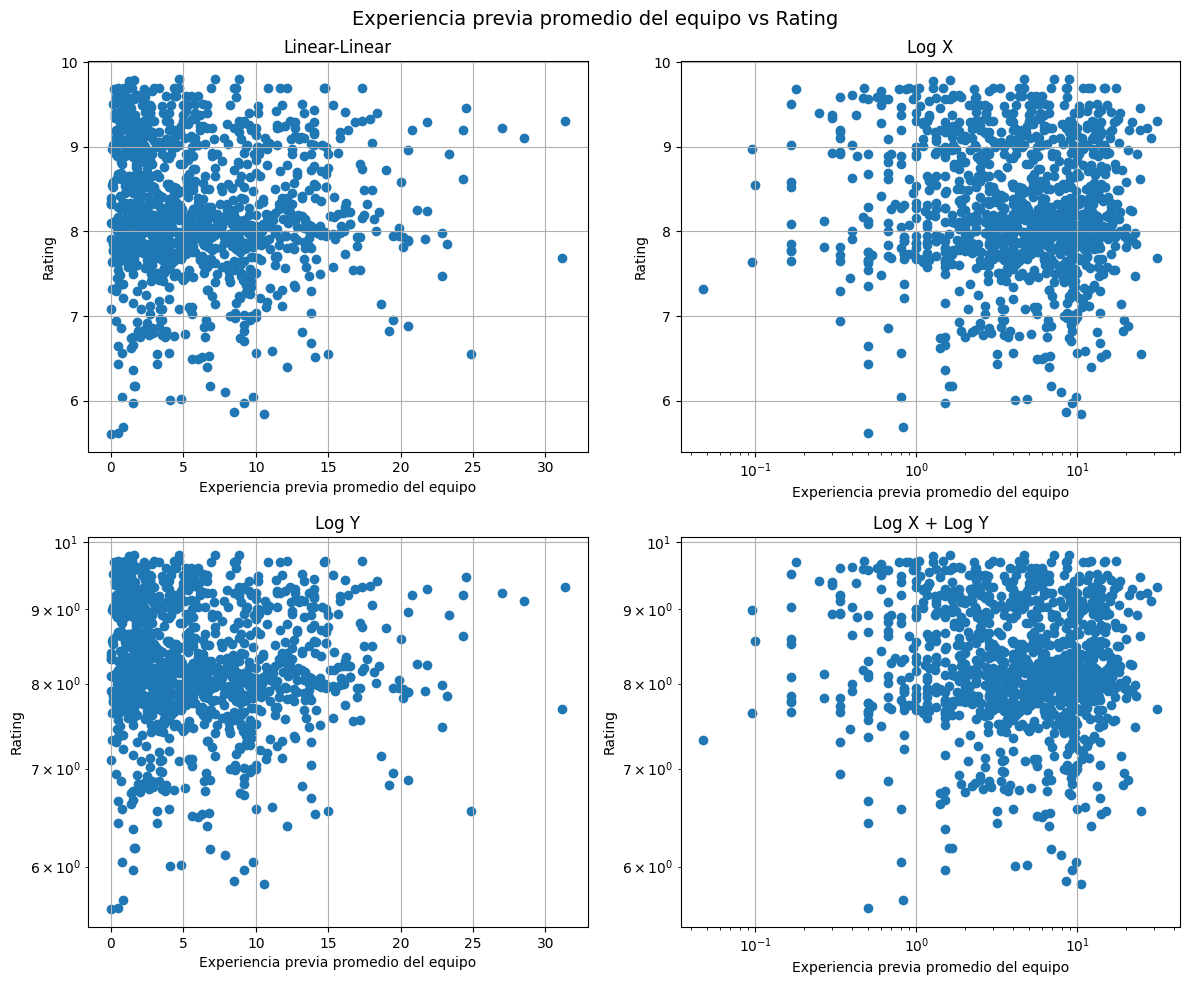

In [93]:
y = df["rating"].to_list()
y_name = "Rating"
x = avg_previous_tm_exp_list

x_name = "Experiencia previa promedio del equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

Promedio de colaboraciones previas por equipo

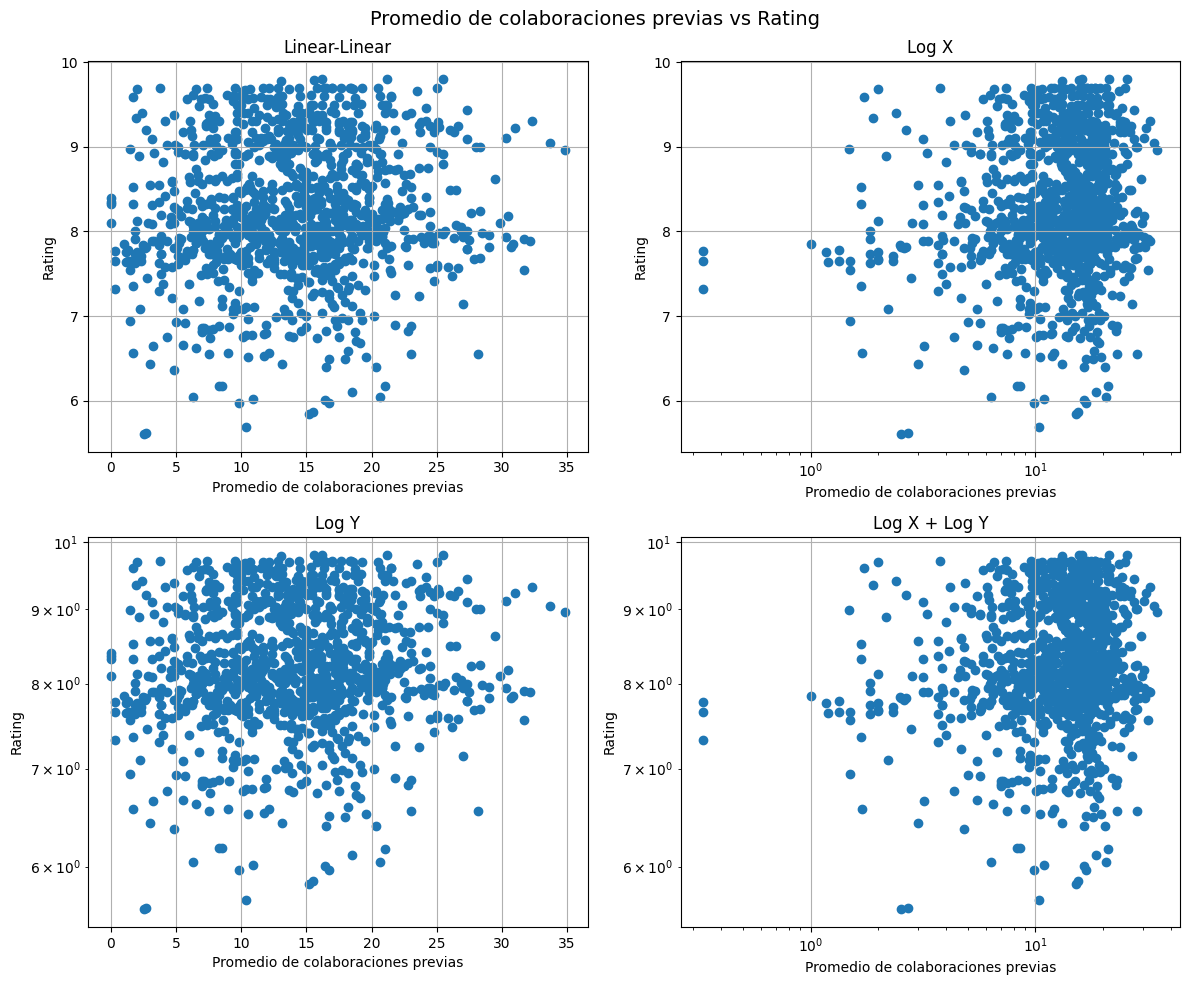

In [94]:
x = avg_previous_tm_shared_colabs_list

x_name = "Promedio de colaboraciones previas"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

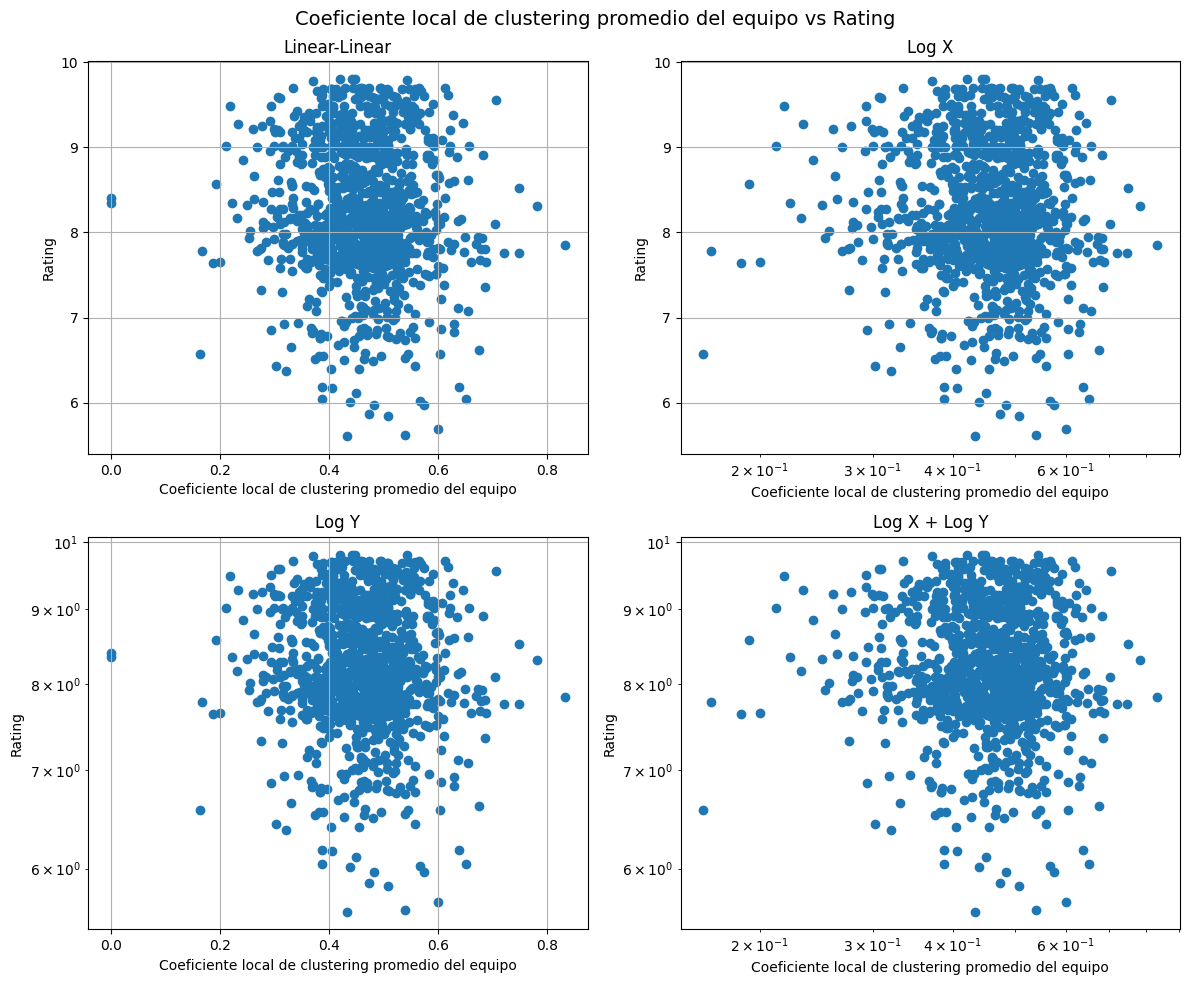

In [95]:
x = avg_previous_tm_clustering_coeff_list

x_name = "Coeficiente local de clustering promedio del equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

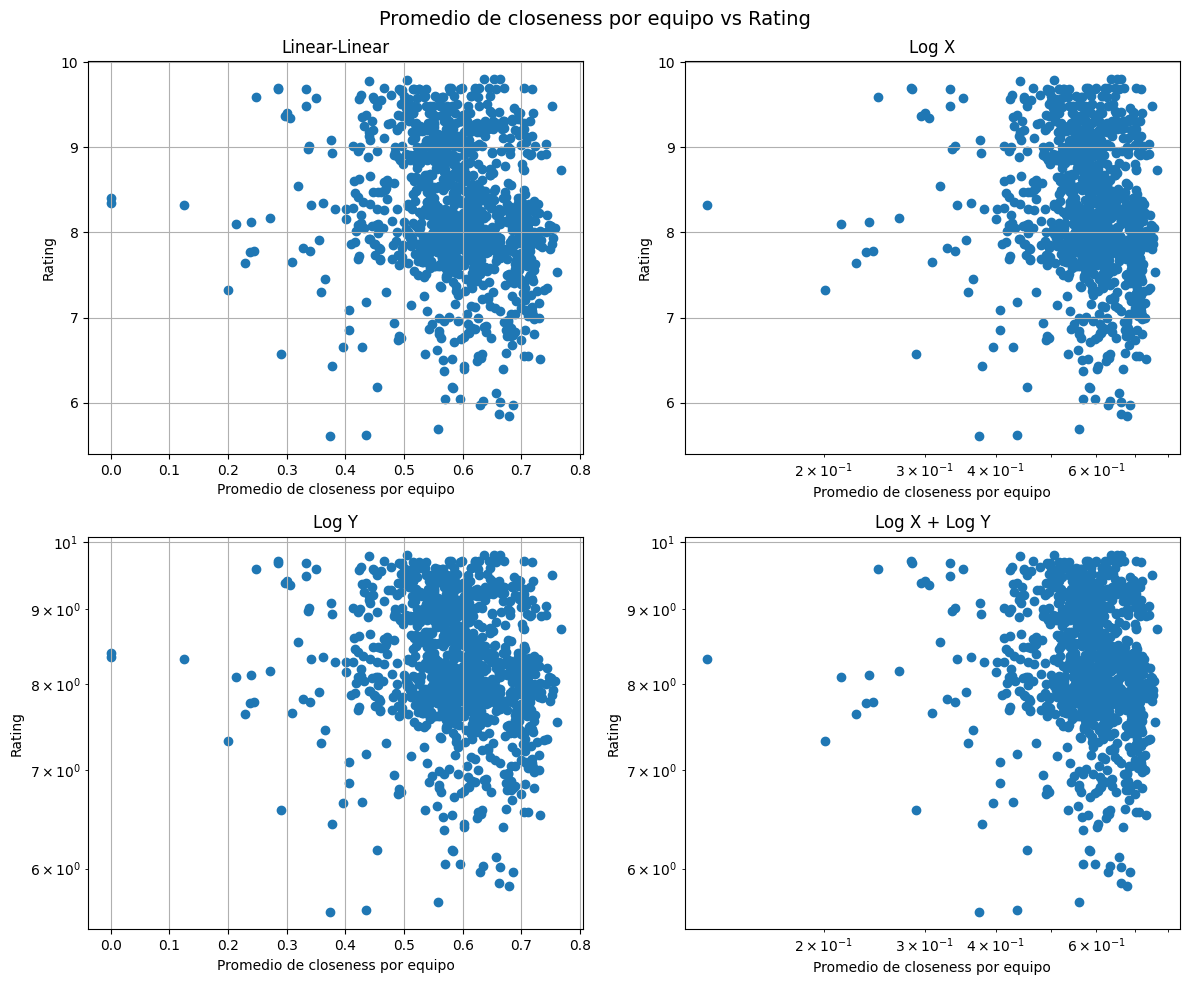

In [96]:
x = avg_previous_tm_closeness_list

x_name = "Promedio de closeness por equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

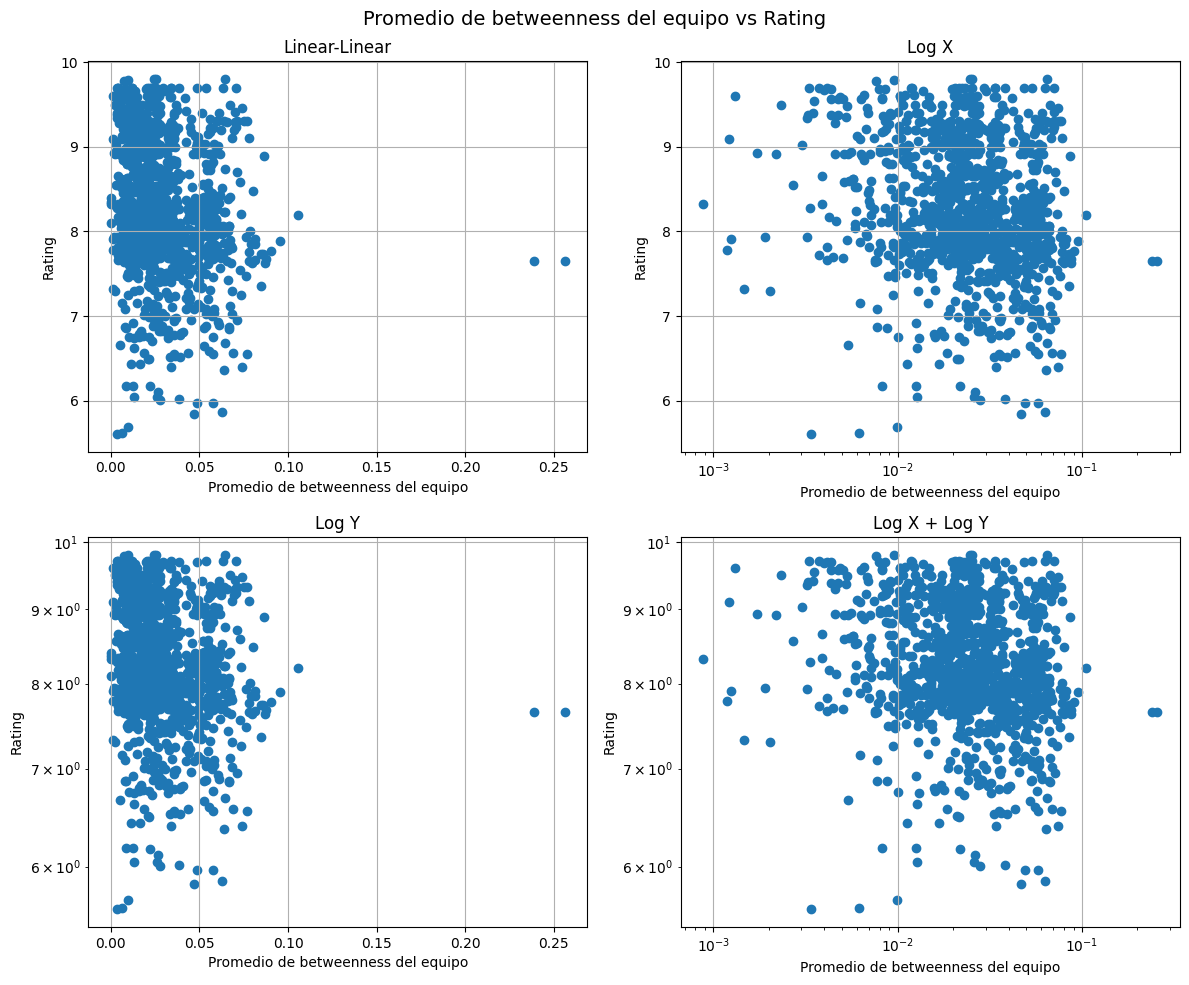

In [97]:
x = avg_previous_tm_betweenness_list

x_name = "Promedio de betweenness del equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

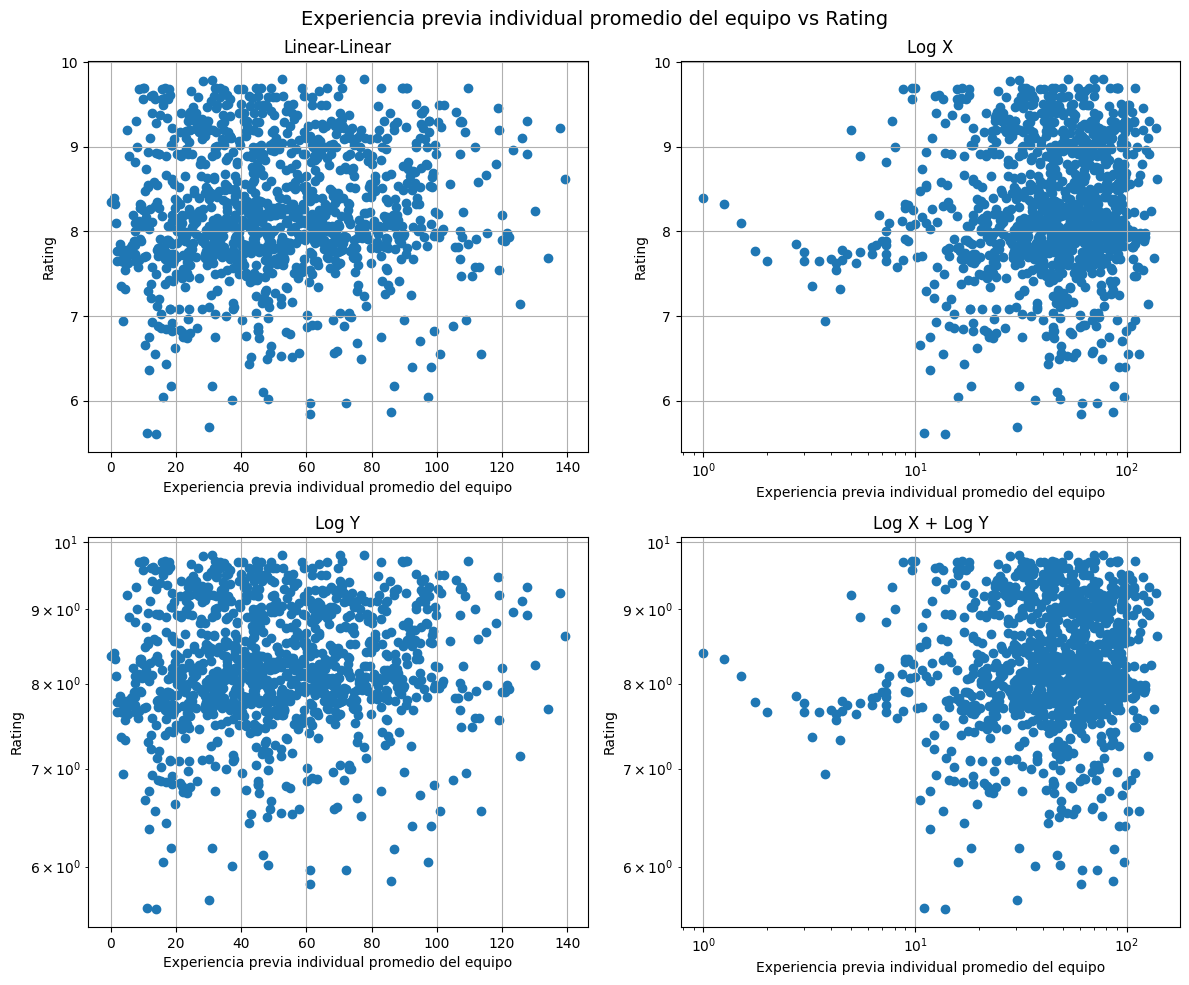

In [98]:
x = avg_previous_individual_exp_list

x_name = "Experiencia previa individual promedio del equipo"
# plot de distribución
plot_metric_vs_metric(x, y, x_name, y_name)

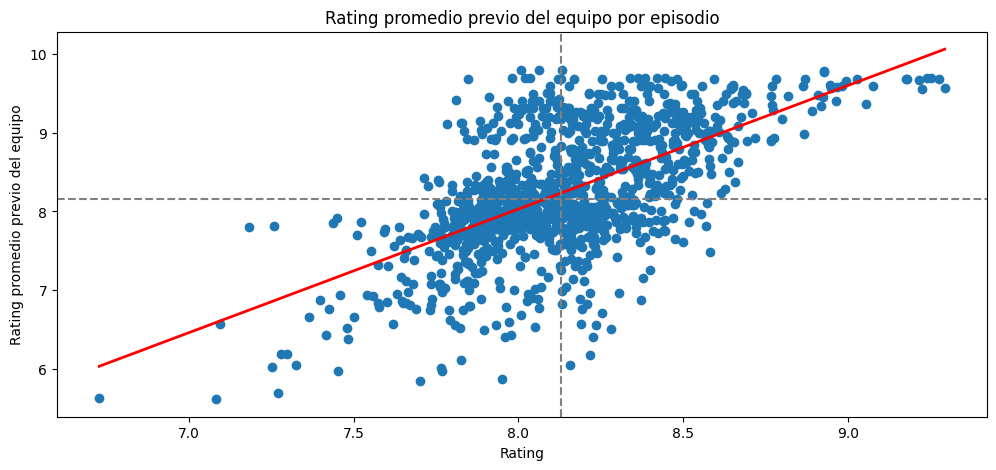

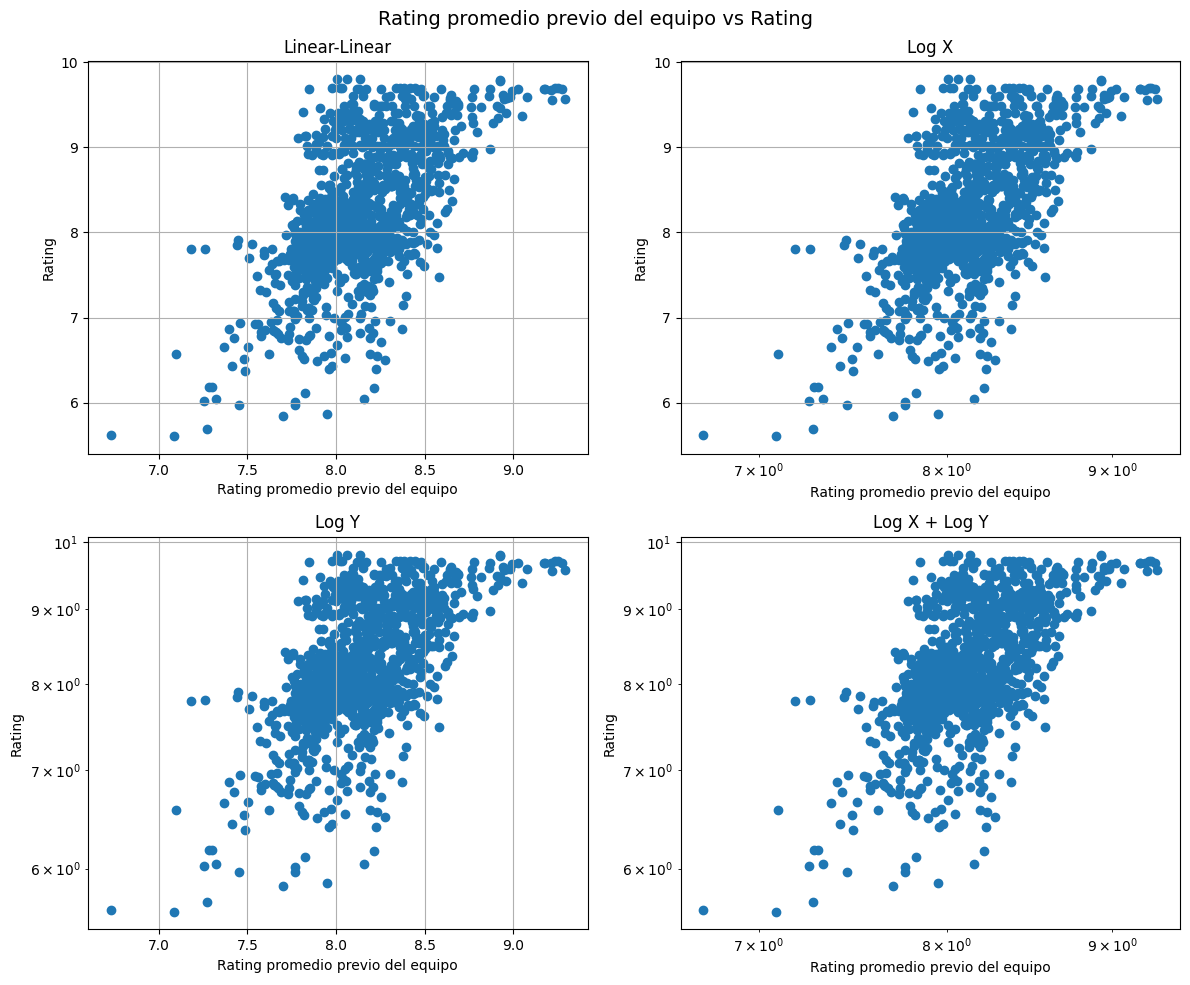

In [99]:
x1 = avg_previous_team_rating_list[1:]
y1 = y[1:]

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x1, y1)

x_arr = np.array(x1)
y_arr = np.array(y1)

# np.polyfit calcula la pendiente (m) y la intersección (b) con un polinomio de grado 1 (recta)
m, b = np.polyfit(x_arr, y_arr, 1)

# Creamos puntos en el eje x desde el mínimo al máximo para dibujar la recta de forma continua
x_recta = np.linspace(x_arr.min(), x_arr.max(), 100)
y_recta = m * x_recta + b

# Dibujamos la recta sobre el plot
plt.plot(x_recta, y_recta, color='red', linewidth=2, label=f'Tendencia promedio (y = {m:.2f}x + {b:.2f})')
# ----

centro_x = np.median(x1)
centro_y = np.median(y1)

# Línea vertical que divide izquierda y derecha
plt.axvline(x=centro_x, color='gray', linestyle='--', linewidth=1.5, label='División X')

# Línea horizontal que divide arriba y abajo
plt.axhline(y=centro_y, color='gray', linestyle='--', linewidth=1.5, label='División Y')
# -----------------------------------------------

plt.xlabel("Rating")
plt.ylabel("Rating promedio previo del equipo")
plt.title("Rating promedio previo del equipo por episodio")

x_name = "Rating promedio previo del equipo"
# plot de distribución
plot_metric_vs_metric(x1, y1, x_name, y_name)

# Generación de data sintetica

## Rating sintetico

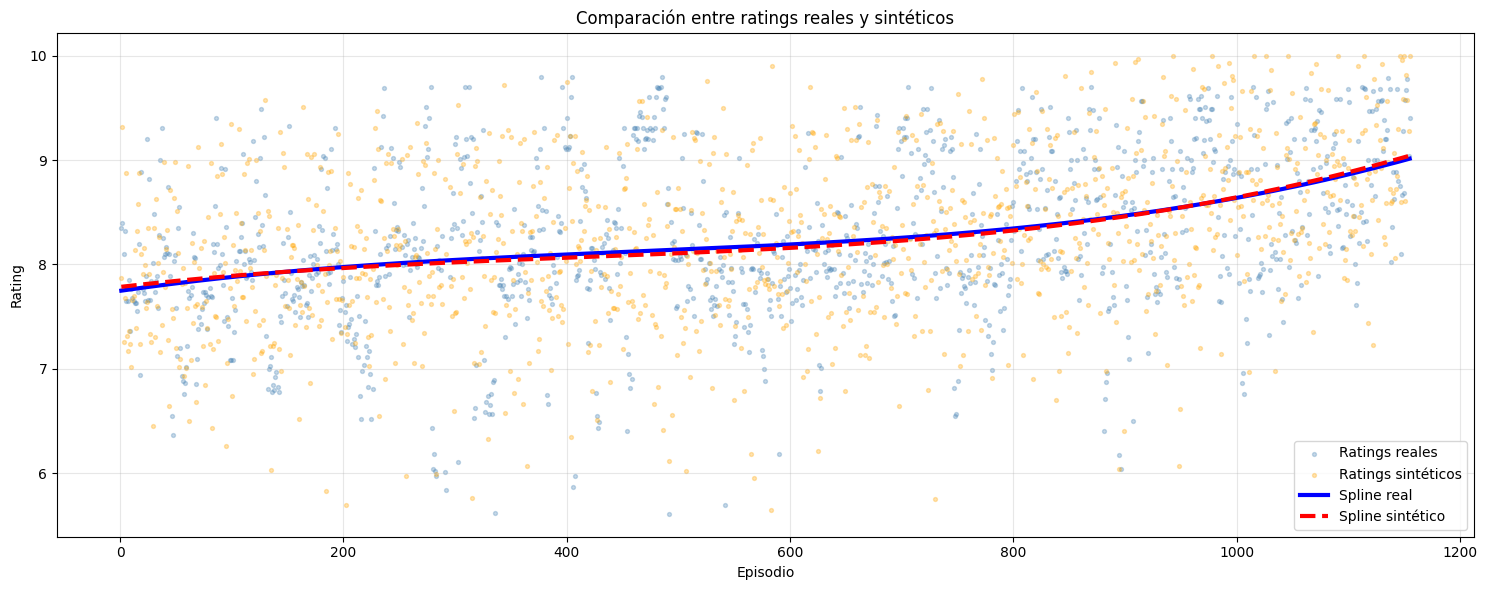

Media
Real      : 8.247
Sintético : 8.236

Desviación estándar
Real      : 0.789
Sintético : 0.798

Percentiles
P05: Real=6.865 | Sintético=6.960

P25: Real=7.780 | Sintético=7.720

P50: Real=8.160 | Sintético=8.230

P75: Real=8.910 | Sintético=8.790

P95: Real=9.510 | Sintético=9.550

P100: Real=9.800 | Sintético=10.000

P0050: Real=7.12 | Sintético=8.51
P0250: Real=8.93 | Sintético=8.19
P0500: Real=9.25 | Sintético=7.56
P0750: Real=7.9 | Sintético=7.13
P0950: Real=8.33 | Sintético=8.89
P1120: Real=9.49 | Sintético=9.34


In [100]:
# Entrenar modelo

modelo = train_generator(
    "datasets/one_piece_merged.csv",
    "rating"
)

# Generar ratings sintéticos
ratings = generate_synthetic(
    modelo,
    seed=67,
    clip=[0, 10]
)

# Convertir el diccionario a arrays
x = np.array(list(ratings.keys()))
rating_generado = np.array(list(ratings.values()))

# Datos originales
y = modelo["y"]
spline = modelo["spline"]

# Crear un spline para los ratings generados

spline_generado = UnivariateSpline(
    x,
    rating_generado,
    s=len(x) * 0.8
)

x_smooth = np.linspace(x.min(), x.max(), 1000)

real_smooth = spline(x_smooth)
gen_smooth = spline_generado(x_smooth)

# Comparacion de splines y puntos

plt.figure(figsize=(15,6))

plt.scatter(
    x,
    y,
    s=8,
    alpha=0.30,
    color="steelblue",
    label="Ratings reales"
)

plt.scatter(
    x,
    rating_generado,
    s=8,
    alpha=0.30,
    color="orange",
    label="Ratings sintéticos"
)

plt.plot(
    x_smooth,
    real_smooth,
    color="blue",
    linewidth=3,
    label="Spline real"
)

plt.plot(
    x_smooth,
    gen_smooth,
    color="red",
    linewidth=3,
    linestyle="--",
    label="Spline sintético"
)

plt.xlabel("Episodio")
plt.ylabel("Rating")
plt.title("Comparación entre ratings reales y sintéticos")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Comparacion de metricas basicas

print("Media")
print(f"Real      : {np.mean(y):.3f}")
print(f"Sintético : {np.mean(rating_generado):.3f}")

print("\nDesviación estándar")
print(f"Real      : {np.std(y):.3f}")
print(f"Sintético : {np.std(rating_generado):.3f}")

print("\nPercentiles")

for p in [5, 25, 50, 75, 95, 100]:
    print(
        f"P{p:02d}: "
        f"Real={np.percentile(y,p):.3f} | "
        f"Sintético={np.percentile(rating_generado,p):.3f}\n"

    )

for p in [50, 250, 500, 750, 950, 1120]:
    print(
        f"P{p:04d}: "
        f"Real={y[p]} | "
        f"Sintético={rating_generado[p]}"
    )

## Cantidad de votos sinteticos

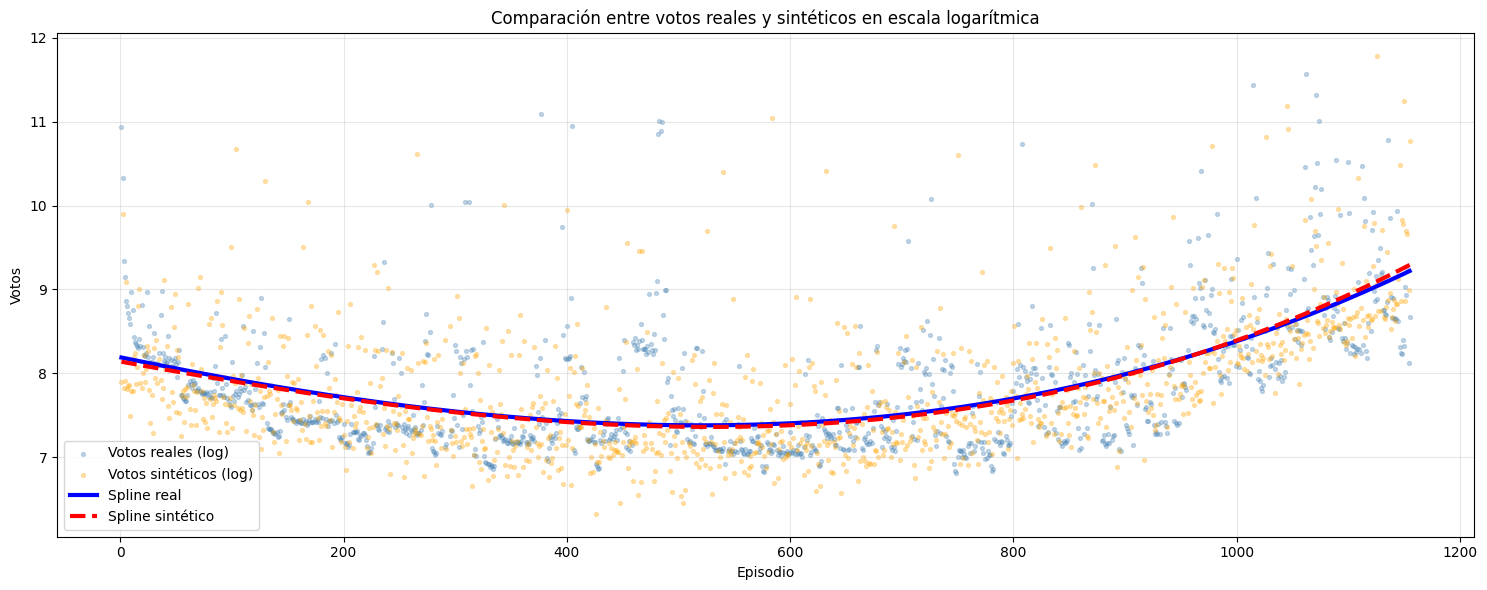

Media
Real      : 4045.973
Sintético : 3860.142

Desviación estándar
Real      : 7860.700
Sintético : 7128.121

Percentiles
P01: Real=987.000 | Sintético=783.500
P05: Real=1149.500 | Sintético=984.000
P25: Real=1393.500 | Sintético=1412.000
P50: Real=2048.000 | Sintético=2087.000
P75: Real=3796.000 | Sintético=3788.500
P95: Real=10418.000 | Sintético=10497.500
P100: Real=105636.000 | Sintético=131140.000

Valores específicos
Episodio 0050: Real=2848.0 | Sintético=3957.0
Episodio 0250: Real=3000.0 | Sintético=2021.0
Episodio 0500: Real=3807.0 | Sintético=1167.0
Episodio 0750: Real=1195.0 | Sintético=1091.0
Episodio 0950: Real=2434.0 | Sintético=3611.0
Episodio 1120: Real=9531.0 | Sintético=8568.0


In [101]:
# Entrenar modelo

modelo = train_generator(
    "datasets/one_piece_merged.csv",
    "votos",
    transform="log"
)

# Generar votos sintéticos
votos = generate_synthetic(
    modelo,
    seed=67,
    decimals=0
)

# Convertir el diccionario a arrays
x = np.array(list(votos.keys()))
votos_generado = np.array(list(votos.values()))
# Datos sintéticos en log
votos_generado_log = np.log1p(votos_generado)

# Datos originales
y_log = modelo["y"]
y = np.expm1(y_log).round()
spline = modelo["spline"]

# Crear spline para los datos generados

spline_generado = UnivariateSpline(
    x,
    np.log1p(votos_generado),
    s=len(x) * 0.8
)

x_smooth = np.linspace(x.min(), x.max(), 1000)

real_smooth = spline(x_smooth)
gen_smooth = spline_generado(x_smooth)

# Comparacion de splines en logaritmica
plt.figure(figsize=(15,6))

plt.scatter(
    x,
    y_log,
    s=8,
    alpha=0.30,
    color="steelblue",
    label="Votos reales (log)"
)

plt.scatter(
    x,
    votos_generado_log,
    s=8,
    alpha=0.30,
    color="orange",
    label="Votos sintéticos (log)"
)

plt.plot(
    x_smooth,
    real_smooth,
    color="blue",
    linewidth=3,
    label="Spline real"
)

plt.plot(
    x_smooth,
    gen_smooth,
    color="red",
    linewidth=3,
    linestyle="--",
    label="Spline sintético"
)

plt.xlabel("Episodio")
plt.ylabel("Votos")
plt.title("Comparación entre votos reales y sintéticos en escala logarítmica")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Comparacion de metricas basicas

print("Media")
print(f"Real      : {np.mean(y):.3f}")
print(f"Sintético : {np.mean(votos_generado):.3f}")

print("\nDesviación estándar")
print(f"Real      : {np.std(y):.3f}")
print(f"Sintético : {np.std(votos_generado):.3f}")

print("\nPercentiles")

for p in [1, 5, 25, 50, 75, 95, 100]:
    print(
        f"P{p:02d}: "
        f"Real={np.percentile(y,p):.3f} | "
        f"Sintético={np.percentile(votos_generado,p):.3f}"
    )

print("\nValores específicos")
for p in [50, 250, 500, 750, 950, 1120]:
    print(
        f"Episodio {p:04d}: "
        f"Real={y[p]} | "
        f"Sintético={votos_generado[p]}"
    )


# Modelo Chung-Lu Ajustado a nuestro caso
En esta sección se ejecuta el modelo Chung-Lu a lo largo del tiempo, modificado con tal de que luego que este episodio haya sido definido con sus aristas correspondientes, este no pueda ser modificado. Esta ejecución se realizó con datos sintéticos.

In [102]:
from utils import chung_lu_bipartite, get_members_combination, avg_previous_team_rating, avg_previous_individual_exp, avg_previous_tm_exp, avg_previous_tm_shared_colabs, avg_previous_tm_betweenness, avg_previous_tm_closeness, avg_previous_tm_clustering_coeff
# Columnas donde hay listas de personas
staff_columns = ["guion", "arte", "animacion", "direccion"]

# Igual a como se realizó inicialmente la generación del grafo, solo que con un paso extra entre medio
B_0 = nx.Graph()
B_1 = nx.Graph()
# Definir como None para marcar el paso inicial
G_temp_0 = None
betweenness_temp_0 = None
G_temp_1 = None
betweenness_temp_1 = None
staff_nodes_temp_0 = {}
staff_nodes_temp_1 = {}
# Acá añadir las listas de metricas a almacenar a lo largo del tiempo
avg_closeness_syn = []
avg_betweenness_syn = []
avg_path_len_syn = []
avg_degree_normalized_syn = []
avg_degree_syn = []
# Metricas de viana
avg_previous_tm_exp_list_syn = []
avg_previous_tm_shared_colabs_list_syn = []
avg_previous_tm_clustering_coeff_list_syn = []
avg_previous_tm_closeness_list_syn = []
avg_previous_tm_betweenness_list_syn = []
avg_previous_individual_exp_list_syn = []
avg_previous_team_rating_list_syn = []

global_colabs = []
for _, row in df.iterrows():
    episodio = f"ep_{int(row['episodio'])}"
    B_prev_0 = B_0
    B_0.add_node(episodio, bipartite="episode")
    B_prev_1 = B_1
    B_1.add_node(episodio, bipartite="episode")

    value_dict = {"rating": ratings[int(row['episodio'])], "votos": votos[int(row['episodio'])], "n de paginas": 0}
    
    nx.set_node_attributes(B_0, {episodio: value_dict})
    nx.set_node_attributes(B_1, {episodio: value_dict})
    colabs = 0
    for col in staff_columns:
        personas = parse_list(row[col])
        
        for persona in personas:
            persona_clean = persona.split("(")[0].strip()

            # Agregar nodo persona
            if persona_clean == '':
                continue
            global_colabs.append(persona_clean)
            colabs += 1

    B_0, colabs_0 = chung_lu_bipartite(B_0, global_colabs, episodio, colabs)
    B_1, colabs_1 = chung_lu_bipartite(B_0, global_colabs, episodio, colabs)

    # Primer modelo aleatorio
    staff_nodes_temp_0 = {n for n, d in B_0.nodes(data=True) if d["bipartite"] == "staff"}
    G_prev_0 = G_temp_0
    G_temp_0 = projected_graph_custom(B_0, staff_nodes_temp_0)
    # Segundo modelo aleatorio
    staff_nodes_temp_1 = {n for n, d in B_1.nodes(data=True) if d["bipartite"] == "staff"}
    G_prev_1 = G_temp_1
    G_temp_1 = projected_graph_custom(B_1, staff_nodes_temp_1)

    # Introducir metricas a calcular :)
    # Closeness promedio
    avg_closeness_0 = np.mean(list(nx.closeness_centrality(G_temp_0).values()))
    avg_closeness_1 = np.mean(list(nx.closeness_centrality(G_temp_1).values()))
    avg_closeness_syn.append((avg_closeness_0+avg_closeness_1)/2)
    # Largo del camino característico
    if nx.connected.is_connected(G_temp_0) and nx.connected.is_connected(G_temp_1):

        avg_path_len_syn.append((nx.average_shortest_path_length(G_temp_0)+nx.average_shortest_path_length(G_temp_1))/2)
    elif nx.connected.is_connected(G_temp_0):
        avg_path_len_syn.append(nx.average_shortest_path_length(G_temp_0))
    elif nx.connected.is_connected(G_temp_1):
        avg_path_len_syn.append(nx.average_shortest_path_length(G_temp_1))
    else:
        avg_path_len_syn.append(None)
    
    # Grado promedio normalizado y grado promedio
    avg_degree_normalized_0 = np.mean(list(nx.degree_centrality(G_temp_0).values()))
    avg_degree_normalized_1 = np.mean(list(nx.degree_centrality(G_temp_1).values()))
    avg_degree_normalized_syn.append((avg_degree_normalized_0+avg_degree_normalized_1)/2)

    avg_degree_0 = np.mean(list(dict(G_temp_0.degree()).values()))
    avg_degree_1 = np.mean(list(dict(G_temp_1.degree()).values()))
    avg_degree_syn.append((avg_degree_0+avg_degree_1)/2)

    # Betweenness promedio
    betweenness_prev_0 = betweenness_temp_0
    betweenness_temp_0 = nx.betweenness_centrality(G_temp_0)
    betweenness_prev_1 = betweenness_temp_1
    betweenness_temp_1 = nx.betweenness_centrality(G_temp_1)
    avg_betweenness_syn.append((np.mean(list(betweenness_temp_0.values()))+np.mean(list(betweenness_temp_1.values())))/2)

    # Conjunto de pares de colaboradores para el episodio actual
    pares_colab_0 = get_members_combination(colabs_0)
    largo_pares_0 = len(pares_colab_0)
    pares_colab_1 = get_members_combination(colabs_1)
    largo_pares_1 = len(pares_colab_1)

    largo_colabs = colabs

    # Experiencia previa promedio del equipo
    if not G_prev_0:
        if not G_prev_1:
            avg_previous_tm_exp_list_syn.append(0)
            avg_previous_tm_shared_colabs_list_syn.append(0)
            avg_previous_tm_clustering_coeff_list_syn.append(0)
            avg_previous_tm_closeness_list_syn.append(0)
            avg_previous_tm_betweenness_list_syn.append(0)
            avg_previous_individual_exp_list_syn.append(0)
            avg_previous_team_rating_list_syn.append(0)
        else:
            avg_previous_tm_exp_list_syn.append(avg_previous_tm_exp(G_prev_1, pares_colab_1, largo_pares_1))
            avg_previous_tm_shared_colabs_list_syn.append(avg_previous_tm_shared_colabs(G_prev_1, pares_colab_1, largo_pares_1))
            avg_previous_tm_clustering_coeff_list_syn.append(avg_previous_tm_clustering_coeff(G_prev_1, colabs_1, largo_colabs))
            avg_previous_tm_closeness_list_syn.append(avg_previous_tm_closeness(G_prev_1, colabs_1, largo_colabs))
            avg_previous_tm_betweenness_list_syn.append(avg_previous_tm_betweenness(G_prev_1, colabs_1, betweenness_prev_1, largo_colabs))
            avg_previous_individual_exp_list_syn.append(avg_previous_individual_exp(B_prev_1, colabs_1, largo_colabs))
            avg_previous_team_rating_list_syn.append(avg_previous_team_rating(B_prev_1, colabs_1, largo_colabs))    
    else:
        if not G_prev_1:
            avg_previous_tm_exp_list_syn.append(avg_previous_tm_exp(G_prev_0, pares_colab_0, largo_pares_0))
            avg_previous_tm_shared_colabs_list_syn.append(avg_previous_tm_shared_colabs(G_prev_0, pares_colab_0, largo_pares_0))
            avg_previous_tm_clustering_coeff_list_syn.append(avg_previous_tm_clustering_coeff(G_prev_0, colabs_0, largo_colabs))
            avg_previous_tm_closeness_list_syn.append(avg_previous_tm_closeness(G_prev_0, colabs_0, largo_colabs))
            avg_previous_tm_betweenness_list_syn.append(avg_previous_tm_betweenness(G_prev_0, colabs_0, betweenness_prev_0, largo_colabs))
            avg_previous_individual_exp_list_syn.append(avg_previous_individual_exp(B_prev_0, colabs_0, largo_colabs))
            avg_previous_team_rating_list_syn.append(avg_previous_team_rating(B_prev_0, colabs_0, largo_colabs))    
        else:
            avg_0 = avg_previous_tm_exp(G_prev_0, pares_colab_0, largo_pares_0)
            avg_1 = avg_previous_tm_exp(G_prev_1, pares_colab_1, largo_pares_1)
            avg_previous_tm_exp_list_syn.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_tm_shared_colabs(G_prev_0, pares_colab_0, largo_pares_0)
            avg_1 =avg_previous_tm_shared_colabs(G_prev_1, pares_colab_1, largo_pares_1)
            avg_previous_tm_shared_colabs_list_syn.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_tm_clustering_coeff(G_prev_0, colabs_0, largo_colabs)
            avg_1 = avg_previous_tm_clustering_coeff(G_prev_1, colabs_1, largo_colabs)
            avg_previous_tm_clustering_coeff_list_syn.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_tm_closeness(G_prev_0, colabs_0, largo_colabs)
            avg_1 = avg_previous_tm_closeness(G_prev_1, colabs_1, largo_colabs)
            avg_previous_tm_closeness_list_syn.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_tm_betweenness(G_prev_0, colabs_0, betweenness_prev_0, largo_colabs)
            avg_1 = avg_previous_tm_betweenness(G_prev_1, colabs_1, betweenness_prev_1, largo_colabs)
            avg_previous_tm_betweenness_list_syn.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_individual_exp(B_prev_0, colabs_0, largo_colabs)
            avg_1 = avg_previous_individual_exp(B_prev_1, colabs_1, largo_colabs)
            avg_previous_individual_exp_list_syn.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_team_rating(B_prev_0, colabs_0, largo_colabs)
            avg_1 = avg_previous_team_rating(B_prev_1, colabs_1, largo_colabs)
            avg_previous_team_rating_list_syn.append((avg_0 + avg_1)/2)
    

Además, realizamos la ejecución del modelo para los datos reales también

In [103]:
# Columnas donde hay listas de personas
staff_columns = ["guion", "arte", "animacion", "direccion"]
value_columns = ["n de paginas", "rating", "votos"]

# Igual a como se realizó inicialmente la generación del grafo, solo que con un paso extra entre medio
B_0 = nx.Graph()
B_1 = nx.Graph()
# Definir como None para marcar el paso inicial
G_temp_0 = None
betweenness_temp_0 = None
G_temp_1 = None
betweenness_temp_1 = None
staff_nodes_temp_0 = {}
staff_nodes_temp_1 = {}
# Acá añadir las listas de metricas a almacenar a lo largo del tiempo
avg_closeness_syn_rl = []
avg_betweenness_syn_rl = []
avg_path_len_syn_rl = []
avg_degree_normalized_syn_rl = []
avg_degree_syn_rl = []
# Metricas de viana
avg_previous_tm_exp_list_syn_rl = []
avg_previous_tm_shared_colabs_list_syn_rl = []
avg_previous_tm_clustering_coeff_list_syn_rl = []
avg_previous_tm_closeness_list_syn_rl = []
avg_previous_tm_betweenness_list_syn_rl = []
avg_previous_individual_exp_list_syn_rl = []
avg_previous_team_rating_list_syn_rl = []

global_colabs = []
for _, row in df.iterrows():
    episodio = f"ep_{int(row['episodio'])}"
    B_prev_0 = B_0
    B_0.add_node(episodio, bipartite="episode")
    B_prev_1 = B_1
    B_1.add_node(episodio, bipartite="episode")

    value_dict = {}
    for val in value_columns:
        value_dict[val] = row[val]
    
    nx.set_node_attributes(B_0, {episodio: value_dict})
    nx.set_node_attributes(B_1, {episodio: value_dict})
    colabs = 0
    for col in staff_columns:
        personas = parse_list(row[col])
        
        for persona in personas:
            persona_clean = persona.split("(")[0].strip()

            # Agregar nodo persona
            if persona_clean == '':
                continue
            global_colabs.append(persona_clean)
            colabs += 1

    B_0, colabs_0 = chung_lu_bipartite(B_0, global_colabs, episodio, colabs)
    B_1, colabs_1 = chung_lu_bipartite(B_0, global_colabs, episodio, colabs)

    # Primer modelo aleatorio
    staff_nodes_temp_0 = {n for n, d in B_0.nodes(data=True) if d["bipartite"] == "staff"}
    G_prev_0 = G_temp_0
    G_temp_0 = projected_graph_custom(B_0, staff_nodes_temp_0)
    # Segundo modelo aleatorio
    staff_nodes_temp_1 = {n for n, d in B_1.nodes(data=True) if d["bipartite"] == "staff"}
    G_prev_1 = G_temp_1
    G_temp_1 = projected_graph_custom(B_1, staff_nodes_temp_1)

    # Introducir metricas a calcular :)
    # Closeness promedio
    avg_closeness_0 = np.mean(list(nx.closeness_centrality(G_temp_0).values()))
    avg_closeness_1 = np.mean(list(nx.closeness_centrality(G_temp_1).values()))
    avg_closeness_syn_rl.append((avg_closeness_0+avg_closeness_1)/2)
    # Largo del camino característico
    if nx.connected.is_connected(G_temp_0) and nx.connected.is_connected(G_temp_1):

        avg_path_len_syn_rl.append((nx.average_shortest_path_length(G_temp_0)+nx.average_shortest_path_length(G_temp_1))/2)
    elif nx.connected.is_connected(G_temp_0):
        avg_path_len_syn_rl.append(nx.average_shortest_path_length(G_temp_0))
    elif nx.connected.is_connected(G_temp_1):
        avg_path_len_syn_rl.append(nx.average_shortest_path_length(G_temp_1))
    else:
        avg_path_len_syn_rl.append(None)
    
    # Grado promedio normalizado y grado promedio
    avg_degree_normalized_0 = np.mean(list(nx.degree_centrality(G_temp_0).values()))
    avg_degree_normalized_1 = np.mean(list(nx.degree_centrality(G_temp_1).values()))
    avg_degree_normalized_syn_rl.append((avg_degree_normalized_0+avg_degree_normalized_1)/2)

    avg_degree_0 = np.mean(list(dict(G_temp_0.degree()).values()))
    avg_degree_1 = np.mean(list(dict(G_temp_1.degree()).values()))
    avg_degree_syn_rl.append((avg_degree_0+avg_degree_1)/2)

    # Betweenness promedio
    betweenness_prev_0 = betweenness_temp_0
    betweenness_temp_0 = nx.betweenness_centrality(G_temp_0)
    betweenness_prev_1 = betweenness_temp_1
    betweenness_temp_1 = nx.betweenness_centrality(G_temp_1)
    avg_betweenness_syn_rl.append((np.mean(list(betweenness_temp_0.values()))+np.mean(list(betweenness_temp_1.values())))/2)

    # Conjunto de pares de colaboradores para el episodio actual
    pares_colab_0 = get_members_combination(colabs_0)
    largo_pares_0 = len(pares_colab_0)
    pares_colab_1 = get_members_combination(colabs_1)
    largo_pares_1 = len(pares_colab_1)

    largo_colabs = colabs

    # Experiencia previa promedio del equipo
    if not G_prev_0:
        if not G_prev_1:
            avg_previous_tm_exp_list_syn_rl.append(0)
            avg_previous_tm_shared_colabs_list_syn_rl.append(0)
            avg_previous_tm_clustering_coeff_list_syn_rl.append(0)
            avg_previous_tm_closeness_list_syn_rl.append(0)
            avg_previous_tm_betweenness_list_syn_rl.append(0)
            avg_previous_individual_exp_list_syn_rl.append(0)
            avg_previous_team_rating_list_syn_rl.append(0)
        else:
            avg_previous_tm_exp_list_syn_rl.append(avg_previous_tm_exp(G_prev_1, pares_colab_1, largo_pares_1))
            avg_previous_tm_shared_colabs_list_syn_rl.append(avg_previous_tm_shared_colabs(G_prev_1, pares_colab_1, largo_pares_1))
            avg_previous_tm_clustering_coeff_list_syn_rl.append(avg_previous_tm_clustering_coeff(G_prev_1, colabs_1, largo_colabs))
            avg_previous_tm_closeness_list_syn_rl.append(avg_previous_tm_closeness(G_prev_1, colabs_1, largo_colabs))
            avg_previous_tm_betweenness_list_syn_rl.append(avg_previous_tm_betweenness(G_prev_1, colabs_1, betweenness_prev_1, largo_colabs))
            avg_previous_individual_exp_list_syn_rl.append(avg_previous_individual_exp(B_prev_1, colabs_1, largo_colabs))
            avg_previous_team_rating_list_syn_rl.append(avg_previous_team_rating(B_prev_1, colabs_1, largo_colabs))    
    else:
        if not G_prev_1:
            avg_previous_tm_exp_list_syn_rl.append(avg_previous_tm_exp(G_prev_0, pares_colab_0, largo_pares_0))
            avg_previous_tm_shared_colabs_list_syn_rl.append(avg_previous_tm_shared_colabs(G_prev_0, pares_colab_0, largo_pares_0))
            avg_previous_tm_clustering_coeff_list_syn_rl.append(avg_previous_tm_clustering_coeff(G_prev_0, colabs_0, largo_colabs))
            avg_previous_tm_closeness_list_syn_rl.append(avg_previous_tm_closeness(G_prev_0, colabs_0, largo_colabs))
            avg_previous_tm_betweenness_list_syn_rl.append(avg_previous_tm_betweenness(G_prev_0, colabs_0, betweenness_prev_0, largo_colabs))
            avg_previous_individual_exp_list_syn_rl.append(avg_previous_individual_exp(B_prev_0, colabs_0, largo_colabs))
            avg_previous_team_rating_list_syn_rl.append(avg_previous_team_rating(B_prev_0, colabs_0, largo_colabs))    
        else:
            avg_0 = avg_previous_tm_exp(G_prev_0, pares_colab_0, largo_pares_0)
            avg_1 = avg_previous_tm_exp(G_prev_1, pares_colab_1, largo_pares_1)
            avg_previous_tm_exp_list_syn_rl.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_tm_shared_colabs(G_prev_0, pares_colab_0, largo_pares_0)
            avg_1 =avg_previous_tm_shared_colabs(G_prev_1, pares_colab_1, largo_pares_1)
            avg_previous_tm_shared_colabs_list_syn_rl.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_tm_clustering_coeff(G_prev_0, colabs_0, largo_colabs)
            avg_1 = avg_previous_tm_clustering_coeff(G_prev_1, colabs_1, largo_colabs)
            avg_previous_tm_clustering_coeff_list_syn_rl.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_tm_closeness(G_prev_0, colabs_0, largo_colabs)
            avg_1 = avg_previous_tm_closeness(G_prev_1, colabs_1, largo_colabs)
            avg_previous_tm_closeness_list_syn_rl.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_tm_betweenness(G_prev_0, colabs_0, betweenness_prev_0, largo_colabs)
            avg_1 = avg_previous_tm_betweenness(G_prev_1, colabs_1, betweenness_prev_1, largo_colabs)
            avg_previous_tm_betweenness_list_syn_rl.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_individual_exp(B_prev_0, colabs_0, largo_colabs)
            avg_1 = avg_previous_individual_exp(B_prev_1, colabs_1, largo_colabs)
            avg_previous_individual_exp_list_syn_rl.append((avg_0 + avg_1)/2)

            avg_0 = avg_previous_team_rating(B_prev_0, colabs_0, largo_colabs)
            avg_1 = avg_previous_team_rating(B_prev_1, colabs_1, largo_colabs)
            avg_previous_team_rating_list_syn_rl.append((avg_0 + avg_1)/2)
    

# Evolución del metricas en el modelo a lo largo del tiempo, para datos reales y sintéticos en comparación al grafo original

Primero veremos la evolución del rating promedio sintético a medida que fueron añadiendose más capitulos

Text(0.5, 1.0, 'Evolución del rating generado promedio a lo largo del tiempo')

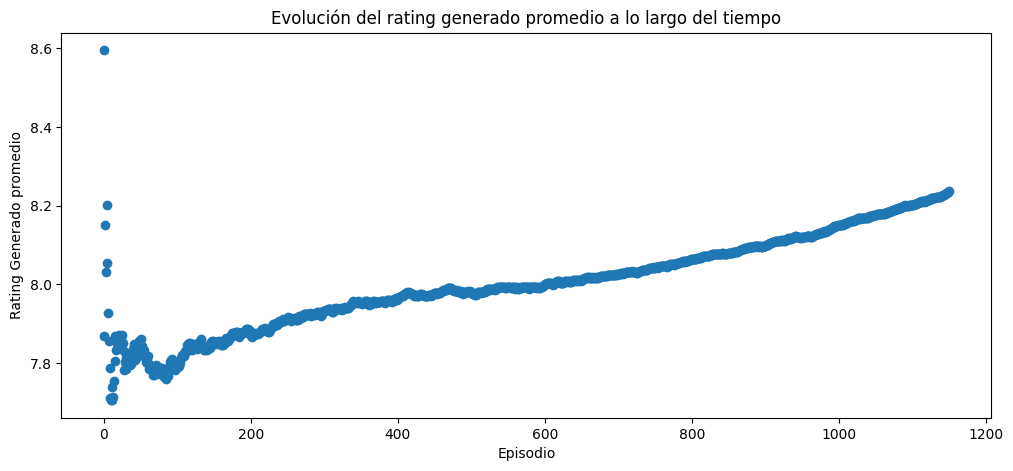

In [104]:
r_total = 0
cantidad = 0
rating_promedio = []
for r in list(ratings.values()):
    r_total += r
    cantidad += 1
    rating_promedio.append(r_total/cantidad)

x = range(cantidad)
y = rating_promedio

# plot de distribución

plt.figure(figsize=(12, 5))

plt.subplot(1, 1, 1)

plt.scatter(x, y)

plt.xlabel("Episodio")
plt.ylabel("Rating Generado promedio")
plt.title("Evolución del rating generado promedio a lo largo del tiempo")

# Betweenness a lo largo del tiempo

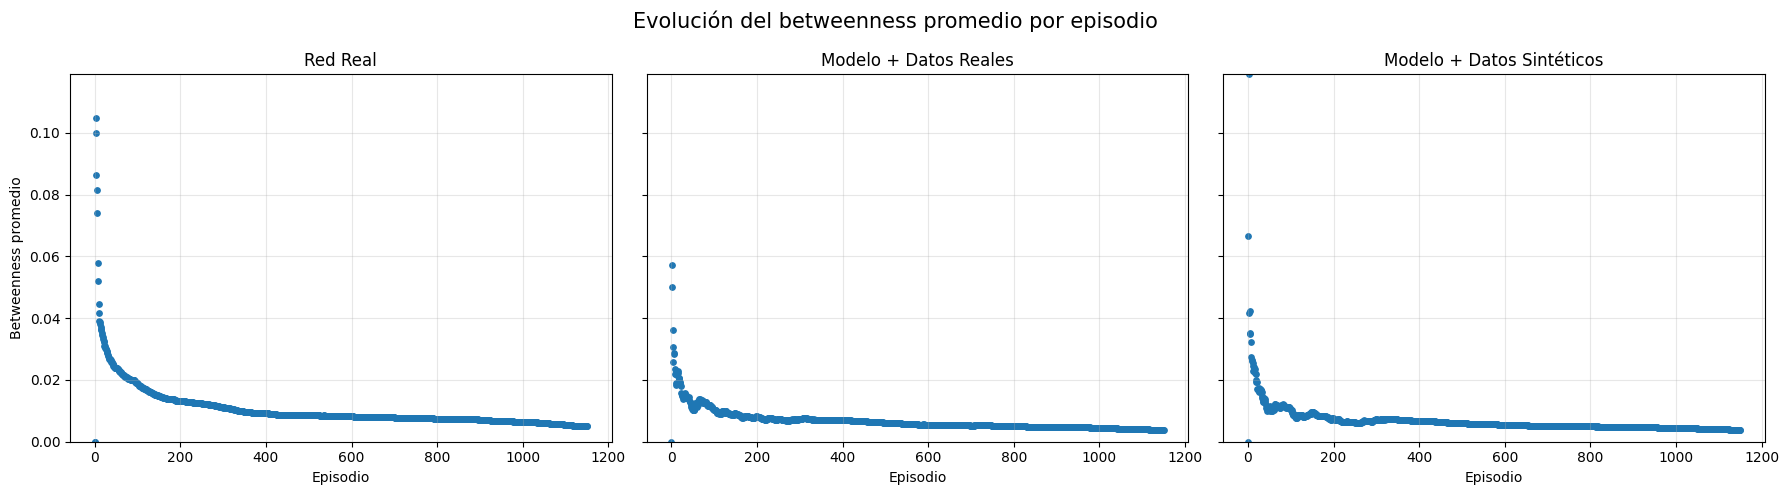

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_betweenness),
    np.min(avg_betweenness_syn),
    np.min(avg_betweenness_syn_rl)
)

y_max = max(
    np.max(avg_betweenness),
    np.max(avg_betweenness_syn),
    np.max(avg_betweenness_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_betweenness, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Betweenness promedio")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_betweenness_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_betweenness_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle("Evolución del betweenness promedio por episodio", fontsize=15)
plt.tight_layout()
plt.show()

# Closeness a lo largo del tiempo

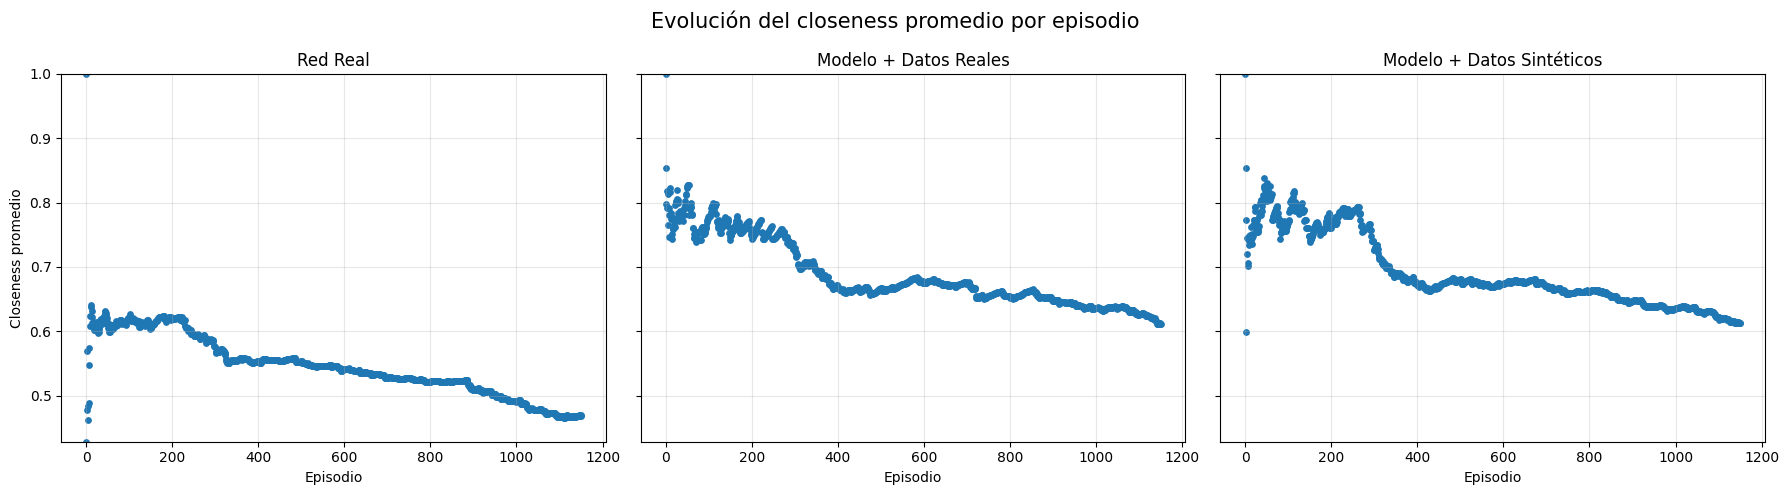

In [106]:
# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_closeness),
    np.min(avg_closeness_syn),
    np.min(avg_closeness_syn_rl)
)

y_max = max(
    np.max(avg_closeness),
    np.max(avg_closeness_syn),
    np.max(avg_closeness_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_closeness, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Closeness promedio")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_closeness_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_closeness_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle("Evolución del closeness promedio por episodio", fontsize=15)
plt.tight_layout()
plt.show()

# Grado normalizado promedio a lo largo del tiempo

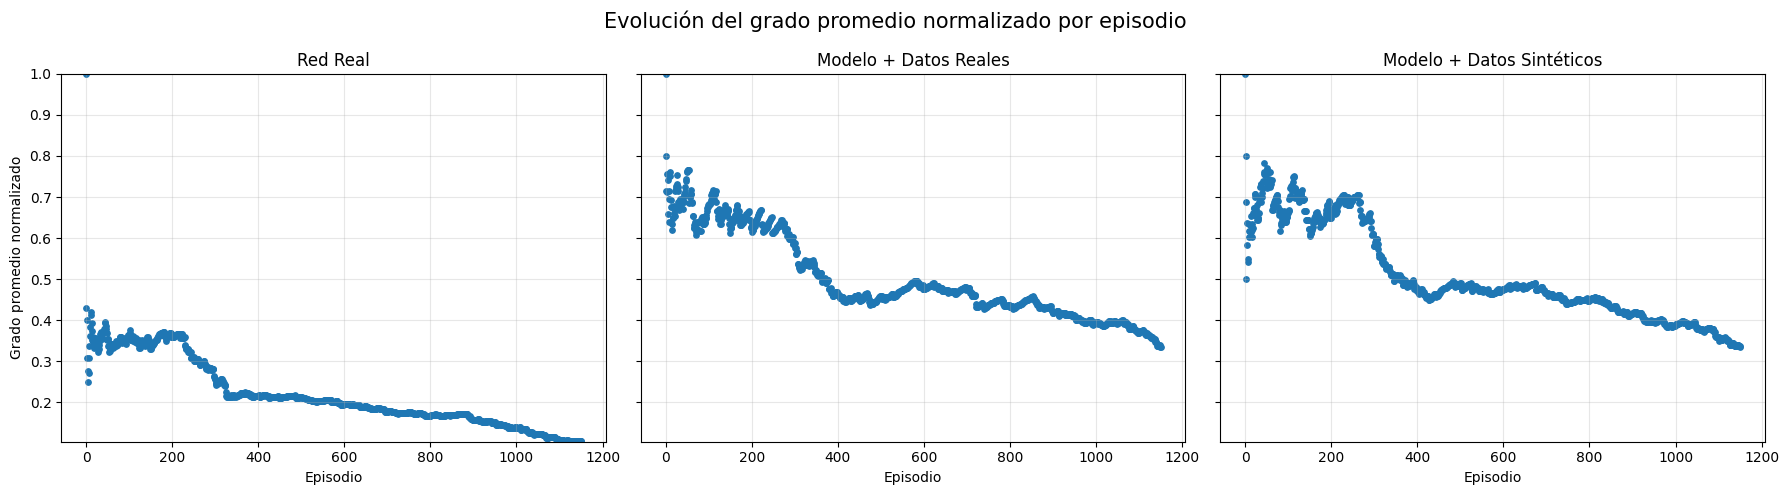

In [107]:
# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_degree_normalized),
    np.min(avg_degree_normalized_syn),
    np.min(avg_degree_normalized_syn_rl)
)

y_max = max(
    np.max(avg_degree_normalized),
    np.max(avg_degree_normalized_syn),
    np.max(avg_degree_normalized_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_degree_normalized, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Grado promedio normalizado")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_degree_normalized_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_degree_normalized_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle("Evolución del grado promedio normalizado por episodio", fontsize=15)
plt.tight_layout()
plt.show()

# Grado promedio a lo largo del tiempo

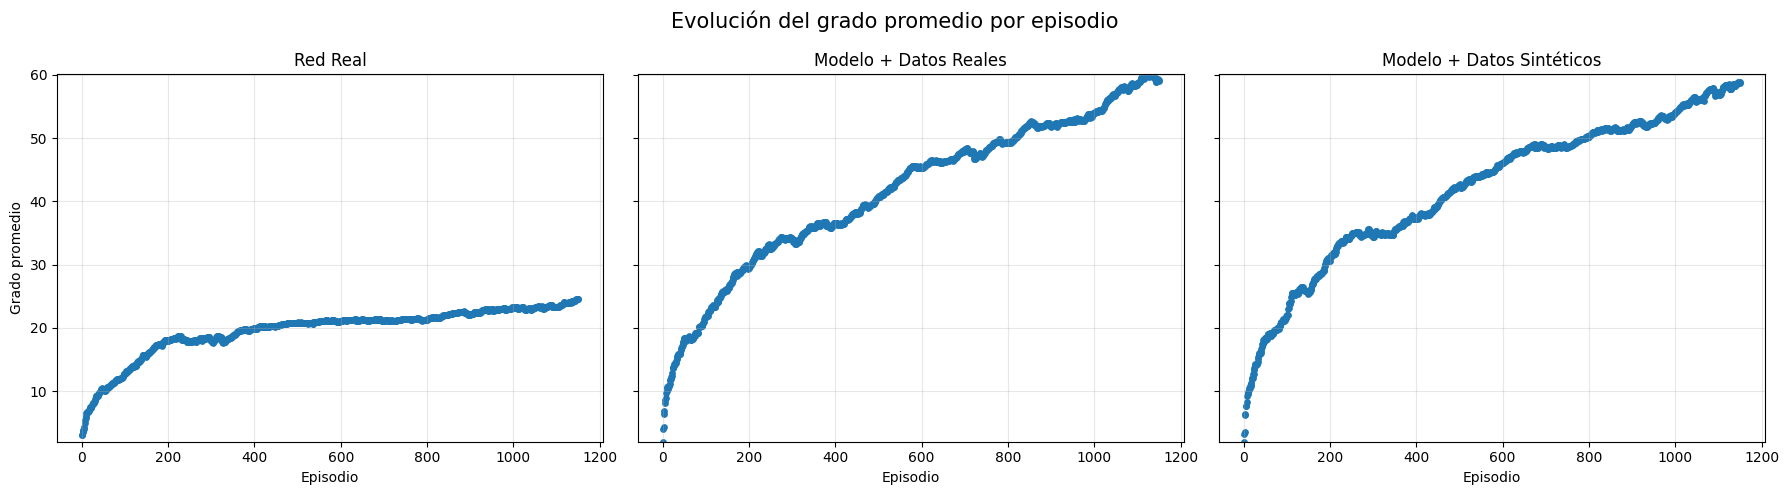

In [108]:
# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_degree),
    np.min(avg_degree_syn),
    np.min(avg_degree_syn_rl)
)

y_max = max(
    np.max(avg_degree),
    np.max(avg_degree_syn),
    np.max(avg_degree_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_degree, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Grado promedio")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_degree_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_degree_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle("Evolución del grado promedio por episodio", fontsize=15)
plt.tight_layout()
plt.show()

# Largo del camino caracteristico a lo largo del tiempo

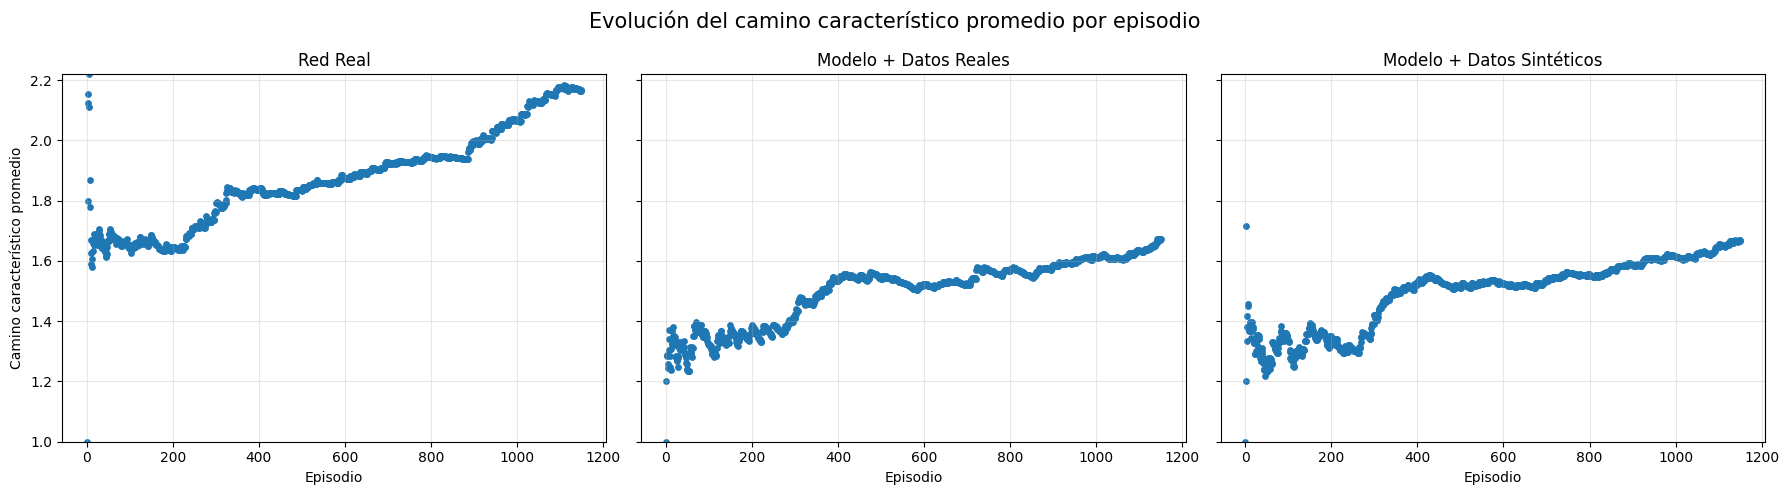

In [125]:

# Calcular límites comunes del eje Y
y_min = min(
    np.nanmin(np.array(avg_path_len, dtype=float)),
    np.min(avg_path_len_syn),
    np.min(avg_path_len_syn_rl)
)

y_max = max(
    np.nanmax(np.array(avg_path_len, dtype=float)),
    np.max(avg_path_len_syn),
    np.max(avg_path_len_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_path_len, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Camino característico promedio")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_path_len_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_path_len_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle("Evolución del camino característico promedio por episodio", fontsize=15)
plt.tight_layout()
plt.show()

# Metricas de Viana en el modelo por episodio, para datos reales y sintéticos en comparación al grafo original

# Experiencia previa promedio por equipo por episodio

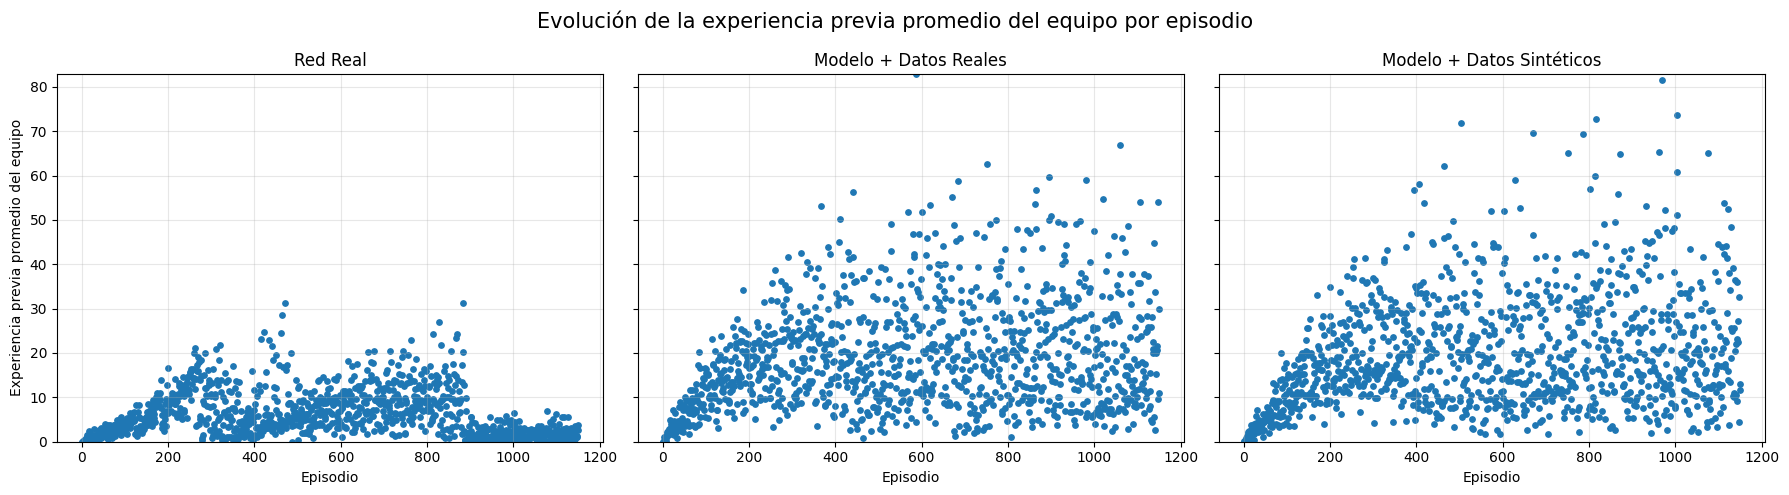

In [110]:
# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_previous_tm_exp_list),
    np.min(avg_previous_tm_exp_list_syn),
    np.min(avg_previous_tm_exp_list_syn_rl)
)

y_max = max(
    np.max(avg_previous_tm_exp_list),
    np.max(avg_previous_tm_exp_list_syn),
    np.max(avg_previous_tm_exp_list_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_previous_tm_exp_list, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Experiencia previa promedio del equipo")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_previous_tm_exp_list_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_previous_tm_exp_list_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle("Evolución de la experiencia previa promedio del equipo por episodio", fontsize=15)
plt.tight_layout()
plt.show()

# Promedio de colaboraciones previas por equipo

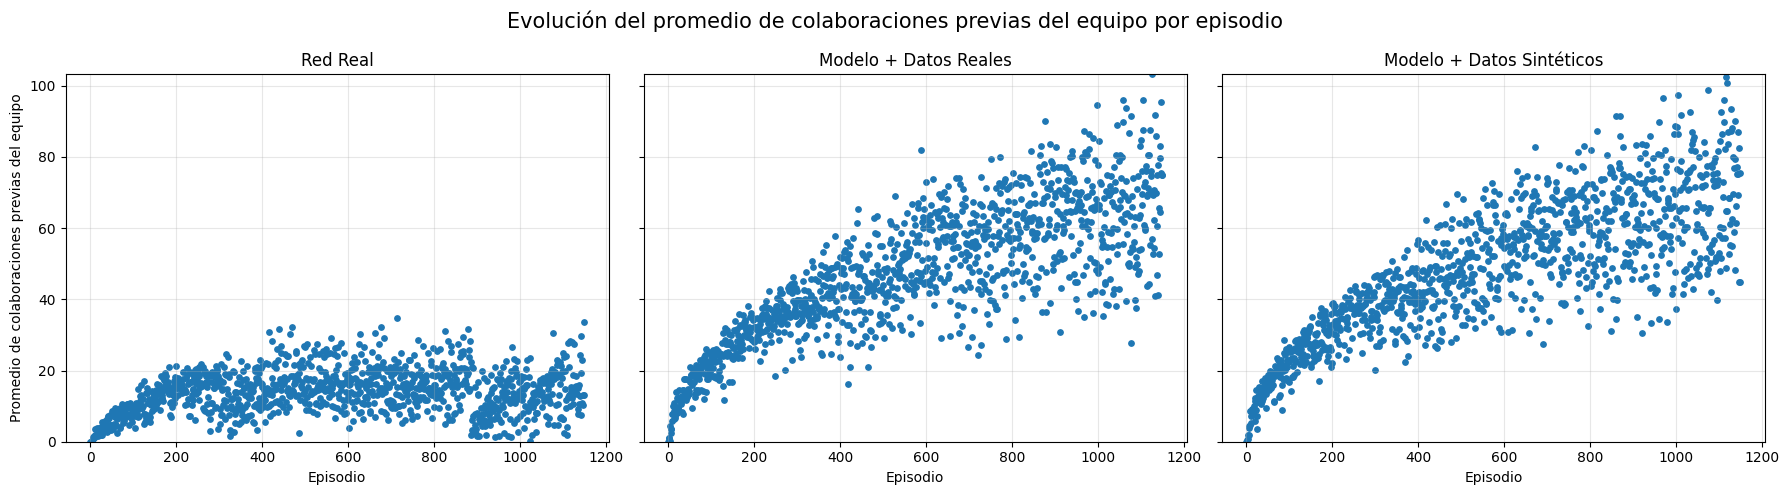

In [111]:
# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_previous_tm_shared_colabs_list),
    np.min(avg_previous_tm_shared_colabs_list_syn),
    np.min(avg_previous_tm_shared_colabs_list_syn_rl)
)

y_max = max(
    np.max(avg_previous_tm_shared_colabs_list),
    np.max(avg_previous_tm_shared_colabs_list_syn),
    np.max(avg_previous_tm_shared_colabs_list_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_previous_tm_shared_colabs_list, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Promedio de colaboraciones previas del equipo")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_previous_tm_shared_colabs_list_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_previous_tm_shared_colabs_list_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle("Evolución del promedio de colaboraciones previas del equipo por episodio", fontsize=15)
plt.tight_layout()
plt.show()

# Clustering Coeff

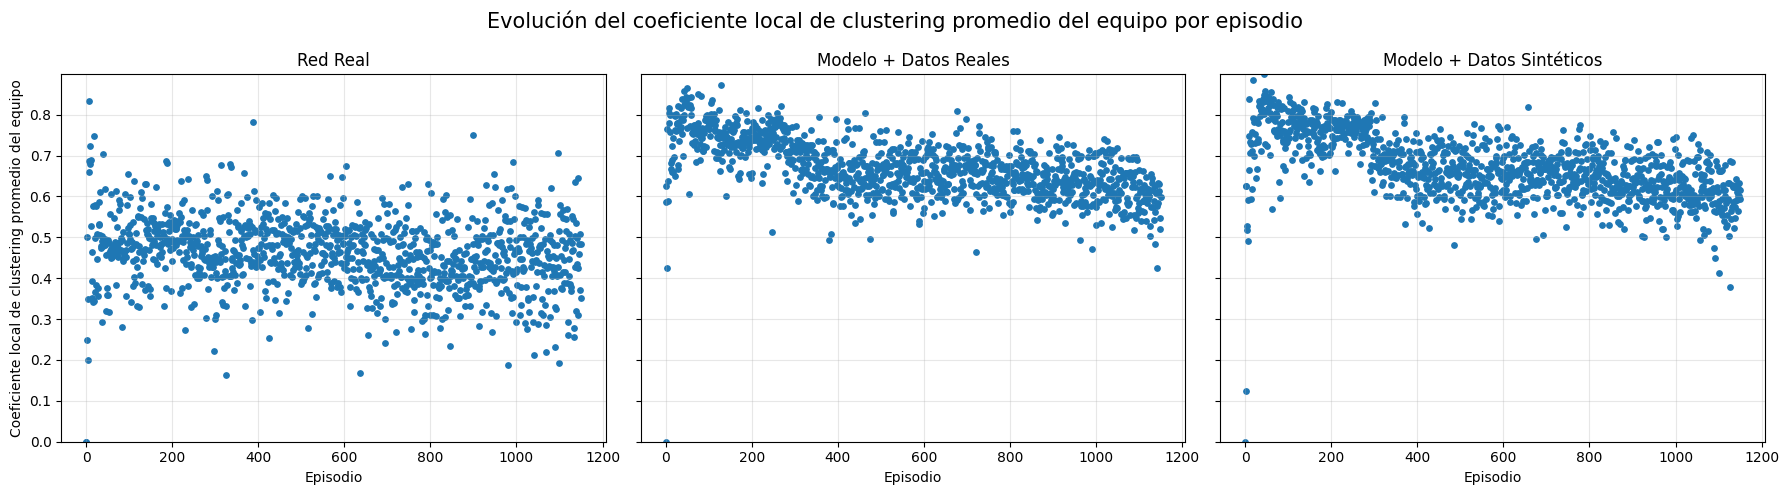

In [112]:
# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_previous_tm_clustering_coeff_list),
    np.min(avg_previous_tm_clustering_coeff_list_syn),
    np.min(avg_previous_tm_clustering_coeff_list_syn_rl)
)

y_max = max(
    np.max(avg_previous_tm_clustering_coeff_list),
    np.max(avg_previous_tm_clustering_coeff_list_syn),
    np.max(avg_previous_tm_clustering_coeff_list_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_previous_tm_clustering_coeff_list, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Coeficiente local de clustering promedio del equipo")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_previous_tm_clustering_coeff_list_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_previous_tm_clustering_coeff_list_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Evolución del coeficiente local de clustering promedio del equipo por episodio",
    fontsize=15
)

plt.tight_layout()
plt.show()

# Team Closeness

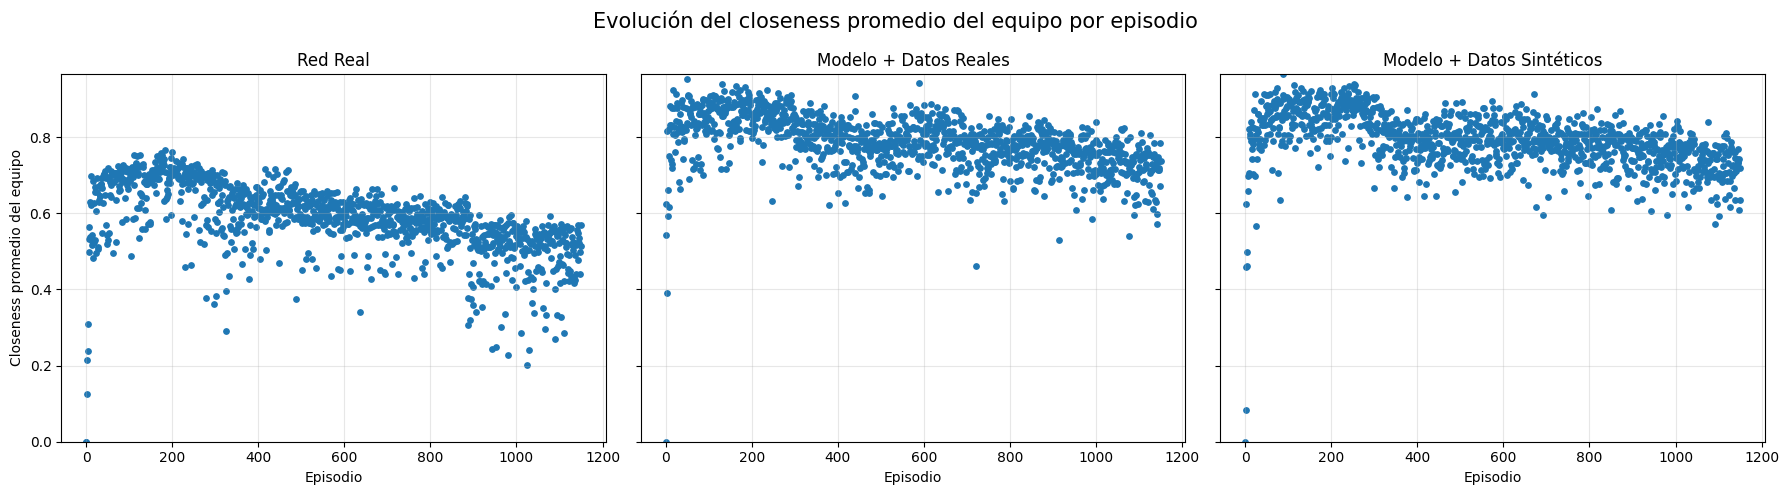

In [113]:
# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_previous_tm_closeness_list),
    np.min(avg_previous_tm_closeness_list_syn),
    np.min(avg_previous_tm_closeness_list_syn_rl)
)

y_max = max(
    np.max(avg_previous_tm_closeness_list),
    np.max(avg_previous_tm_closeness_list_syn),
    np.max(avg_previous_tm_closeness_list_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_previous_tm_closeness_list, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Closeness promedio del equipo")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_previous_tm_closeness_list_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_previous_tm_closeness_list_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Evolución del closeness promedio del equipo por episodio",
    fontsize=15
)

plt.tight_layout()
plt.show()

# Team Betweenness

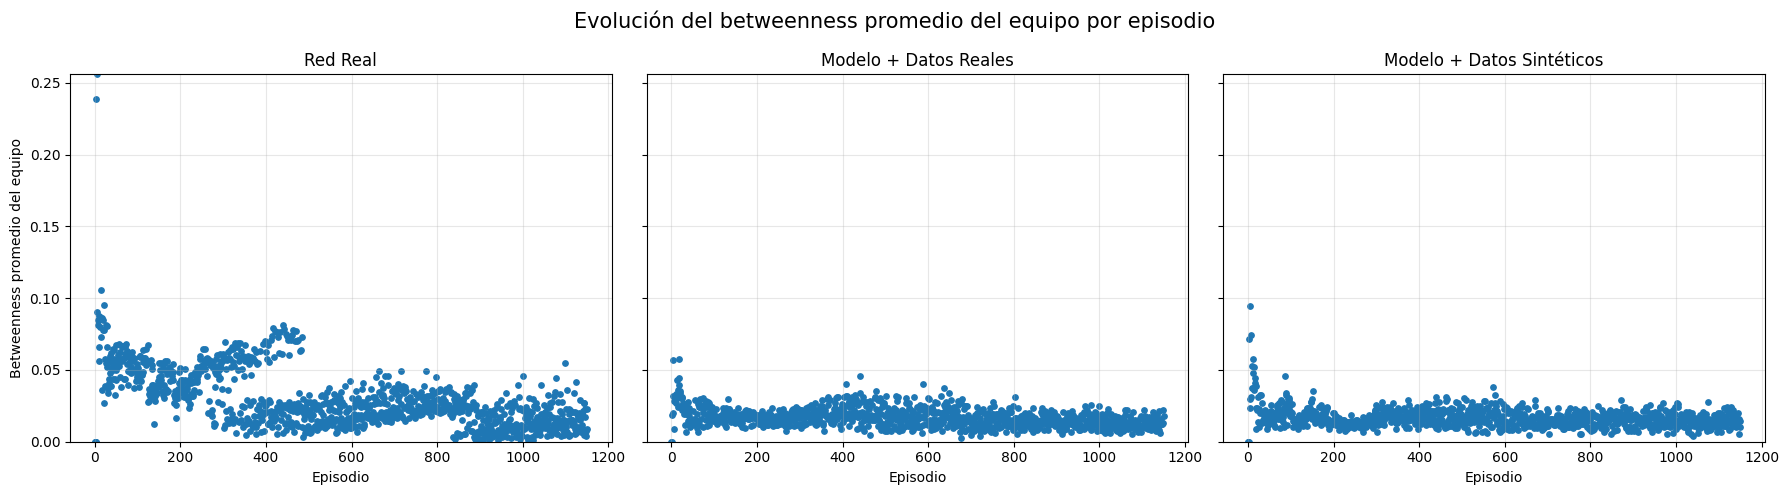

In [114]:
# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_previous_tm_betweenness_list),
    np.min(avg_previous_tm_betweenness_list_syn),
    np.min(avg_previous_tm_betweenness_list_syn_rl)
)

y_max = max(
    np.max(avg_previous_tm_betweenness_list),
    np.max(avg_previous_tm_betweenness_list_syn),
    np.max(avg_previous_tm_betweenness_list_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_previous_tm_betweenness_list, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Betweenness promedio del equipo")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_previous_tm_betweenness_list_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_previous_tm_betweenness_list_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Evolución del betweenness promedio del equipo por episodio",
    fontsize=15
)

plt.tight_layout()
plt.show()

# AVG Team Individual Exp 

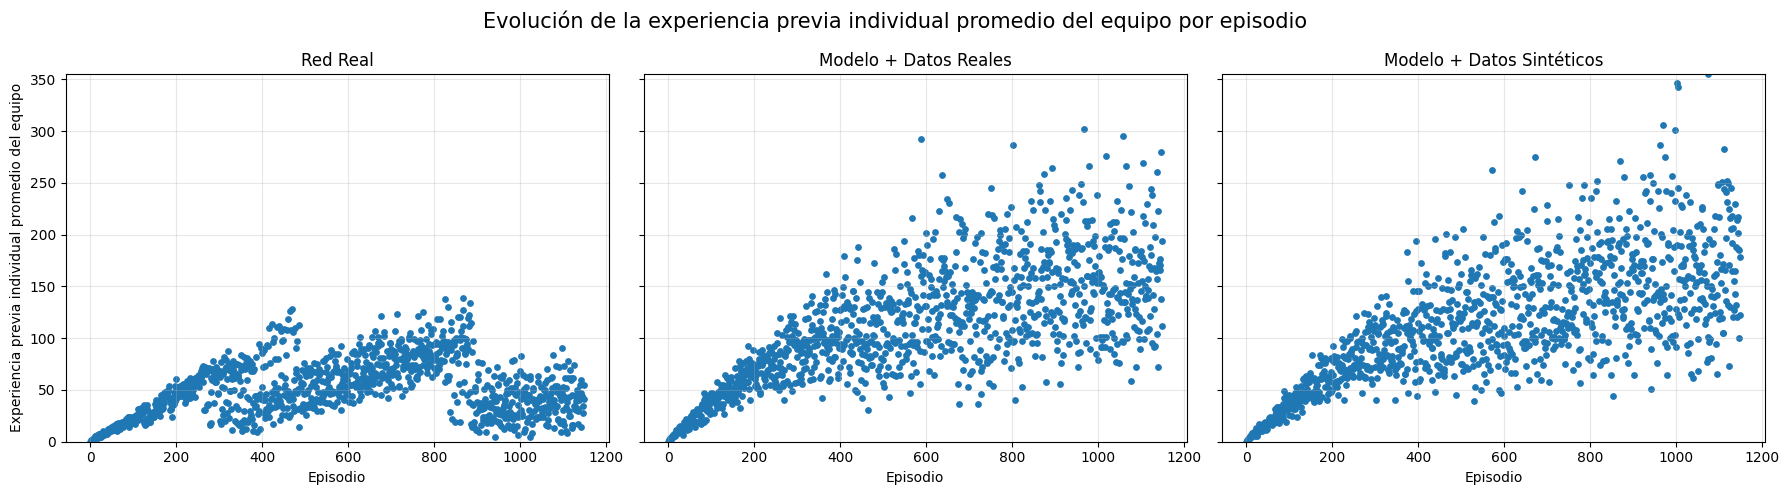

In [115]:
# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_previous_individual_exp_list),
    np.min(avg_previous_individual_exp_list_syn),
    np.min(avg_previous_individual_exp_list_syn_rl)
)

y_max = max(
    np.max(avg_previous_individual_exp_list),
    np.max(avg_previous_individual_exp_list_syn),
    np.max(avg_previous_individual_exp_list_syn_rl)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x, avg_previous_individual_exp_list, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Experiencia previa individual promedio del equipo")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x, avg_previous_individual_exp_list_syn_rl, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x, avg_previous_individual_exp_list_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Evolución de la experiencia previa individual promedio del equipo por episodio",
    fontsize=15
)

plt.tight_layout()
plt.show()

# AVG Team Rating

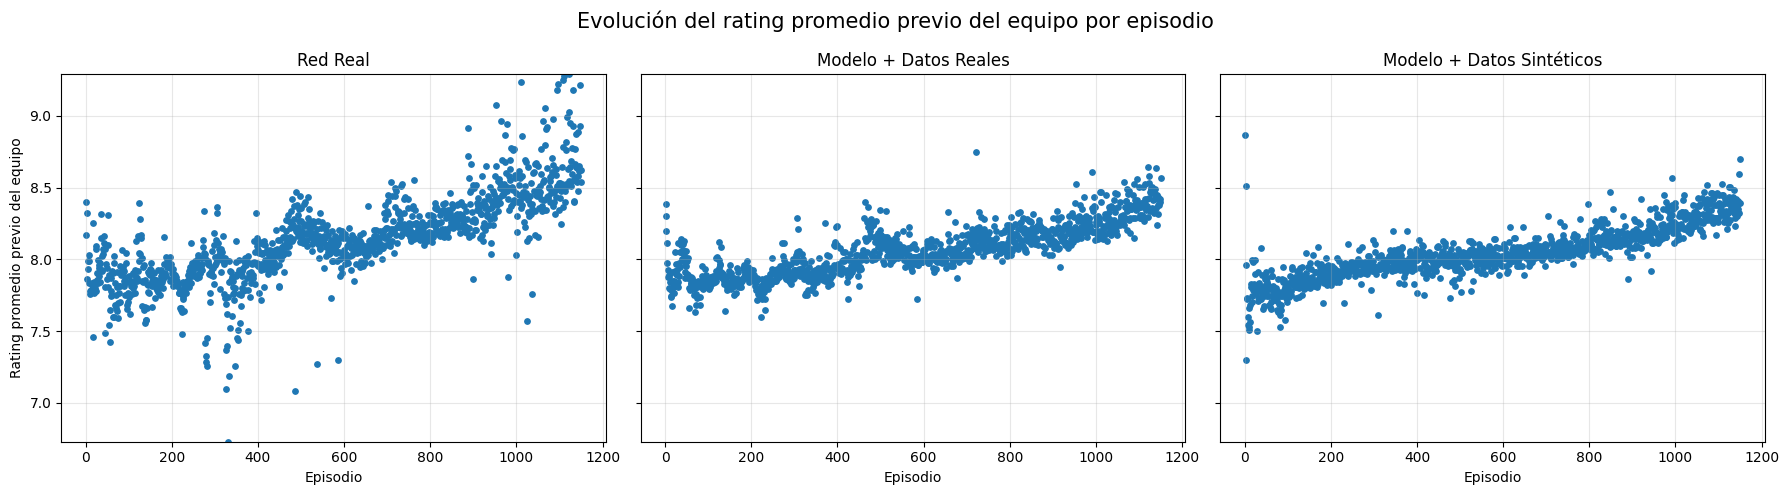

In [116]:
# Ignorar el primer episodio
x1 = x[1:]

# Calcular límites comunes del eje Y
y_min = min(
    np.min(avg_previous_team_rating_list[1:]),
    np.min(avg_previous_team_rating_list_syn[1:]),
    np.min(avg_previous_team_rating_list_syn_rl[1:])
)

y_max = max(
    np.max(avg_previous_team_rating_list[1:]),
    np.max(avg_previous_team_rating_list_syn[1:]),
    np.max(avg_previous_team_rating_list_syn_rl[1:])
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x1, avg_previous_team_rating_list[1:], s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Episodio")
axs[0].set_ylabel("Rating promedio previo del equipo")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x1, avg_previous_team_rating_list_syn_rl[1:], s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Episodio")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x1, avg_previous_team_rating_list_syn[1:], s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Episodio")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Evolución del rating promedio previo del equipo por episodio",
    fontsize=15
)

plt.tight_layout()
plt.show()

# Metricas de Viana en el modelo vs el rating, para datos reales y sintéticos en comparación al grafo original

# Experiencia previa promedio por equipo por episodio

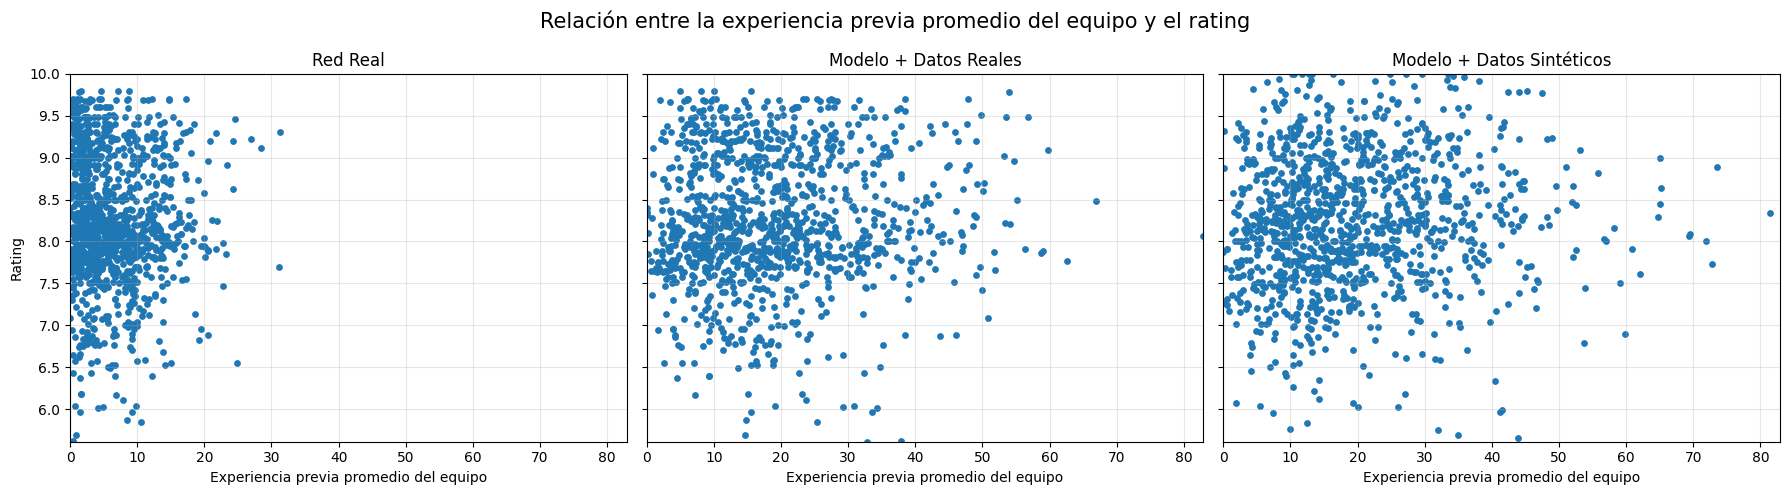

In [117]:
# Datos
y_real = df["rating"].to_list()
y_syn = list(ratings.values())

# Límites comunes
x_min = min(
    np.min(avg_previous_tm_exp_list),
    np.min(avg_previous_tm_exp_list_syn),
    np.min(avg_previous_tm_exp_list_syn_rl)
)

x_max = max(
    np.max(avg_previous_tm_exp_list),
    np.max(avg_previous_tm_exp_list_syn),
    np.max(avg_previous_tm_exp_list_syn_rl)
)

y_min = min(np.min(y_real), np.min(y_syn))
y_max = max(np.max(y_real), np.max(y_syn))

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(avg_previous_tm_exp_list, y_real, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Experiencia previa promedio del equipo")
axs[0].set_ylabel("Rating")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(avg_previous_tm_exp_list_syn_rl, y_real, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Experiencia previa promedio del equipo")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(avg_previous_tm_exp_list_syn, y_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Experiencia previa promedio del equipo")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Relación entre la experiencia previa promedio del equipo y el rating",
    fontsize=15
)

plt.tight_layout()
plt.show()

# Promedio de colaboraciones previas por equipo

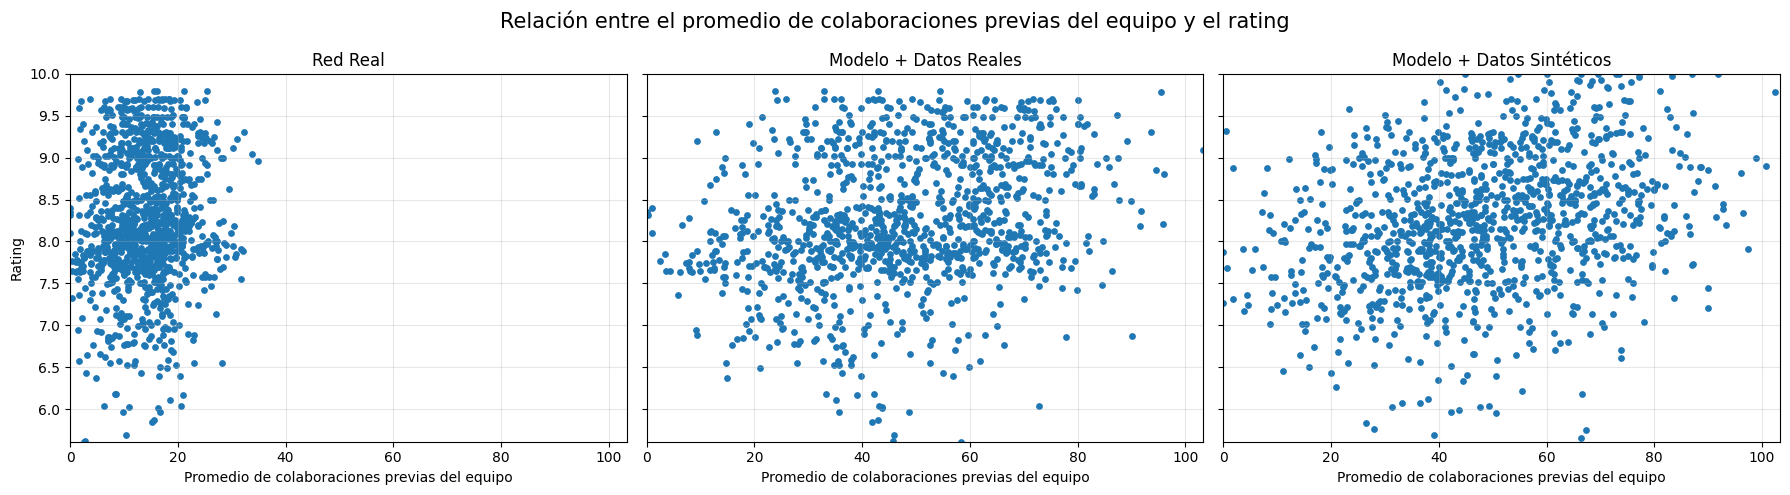

In [118]:
# Datos
y_real = df["rating"].to_list()
y_syn = list(ratings.values())

# Límites comunes
x_min = min(
    np.min(avg_previous_tm_shared_colabs_list),
    np.min(avg_previous_tm_shared_colabs_list_syn),
    np.min(avg_previous_tm_shared_colabs_list_syn_rl)
)

x_max = max(
    np.max(avg_previous_tm_shared_colabs_list),
    np.max(avg_previous_tm_shared_colabs_list_syn),
    np.max(avg_previous_tm_shared_colabs_list_syn_rl)
)

y_min = min(np.min(y_real), np.min(y_syn))
y_max = max(np.max(y_real), np.max(y_syn))

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(avg_previous_tm_shared_colabs_list, y_real, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Promedio de colaboraciones previas del equipo")
axs[0].set_ylabel("Rating")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(avg_previous_tm_shared_colabs_list_syn_rl, y_real, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Promedio de colaboraciones previas del equipo")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(avg_previous_tm_shared_colabs_list_syn, y_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Promedio de colaboraciones previas del equipo")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Relación entre el promedio de colaboraciones previas del equipo y el rating",
    fontsize=15
)

plt.tight_layout()
plt.show()

# Clustering Coeff vs Rating

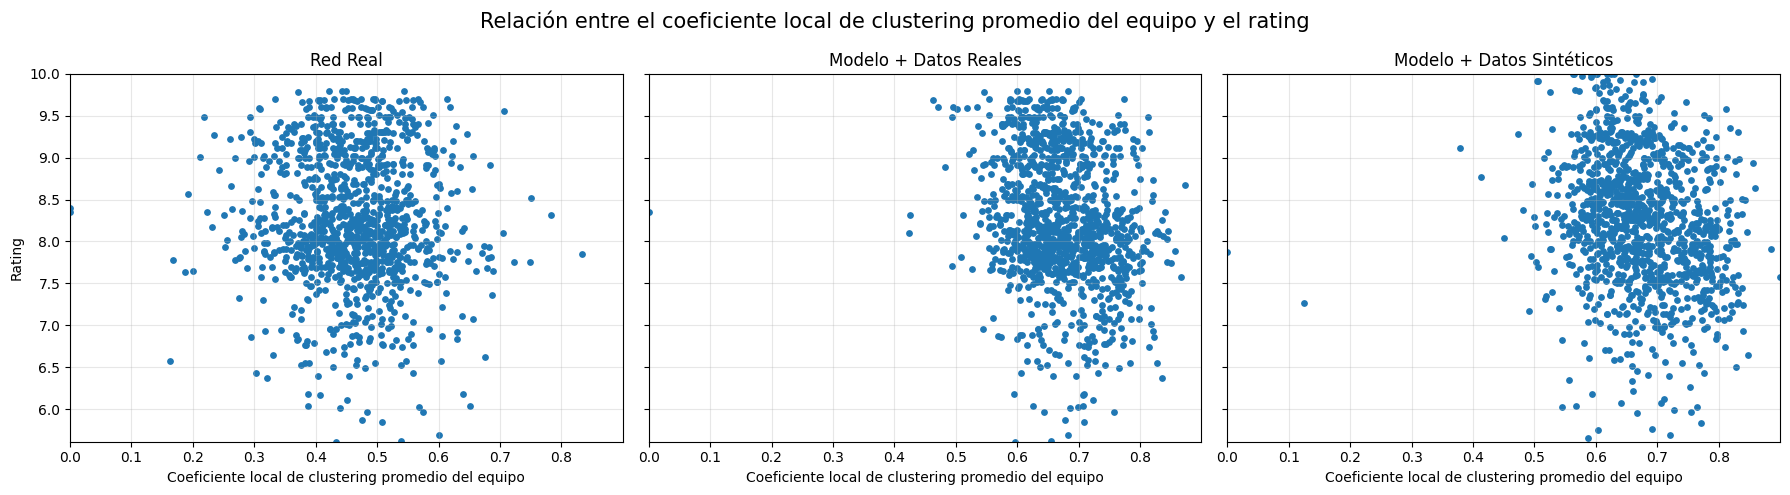

In [119]:
# Datos
y_real = df["rating"].to_list()
y_syn = list(ratings.values())

# Límites comunes
x_min = min(
    np.min(avg_previous_tm_clustering_coeff_list),
    np.min(avg_previous_tm_clustering_coeff_list_syn),
    np.min(avg_previous_tm_clustering_coeff_list_syn_rl)
)

x_max = max(
    np.max(avg_previous_tm_clustering_coeff_list),
    np.max(avg_previous_tm_clustering_coeff_list_syn),
    np.max(avg_previous_tm_clustering_coeff_list_syn_rl)
)

y_min = min(np.min(y_real), np.min(y_syn))
y_max = max(np.max(y_real), np.max(y_syn))

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(avg_previous_tm_clustering_coeff_list, y_real, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Coeficiente local de clustering promedio del equipo")
axs[0].set_ylabel("Rating")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(avg_previous_tm_clustering_coeff_list_syn_rl, y_real, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Coeficiente local de clustering promedio del equipo")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(avg_previous_tm_clustering_coeff_list_syn, y_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Coeficiente local de clustering promedio del equipo")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Relación entre el coeficiente local de clustering promedio del equipo y el rating",
    fontsize=15
)

plt.tight_layout()
plt.show()

# TM Closeness vs Rating

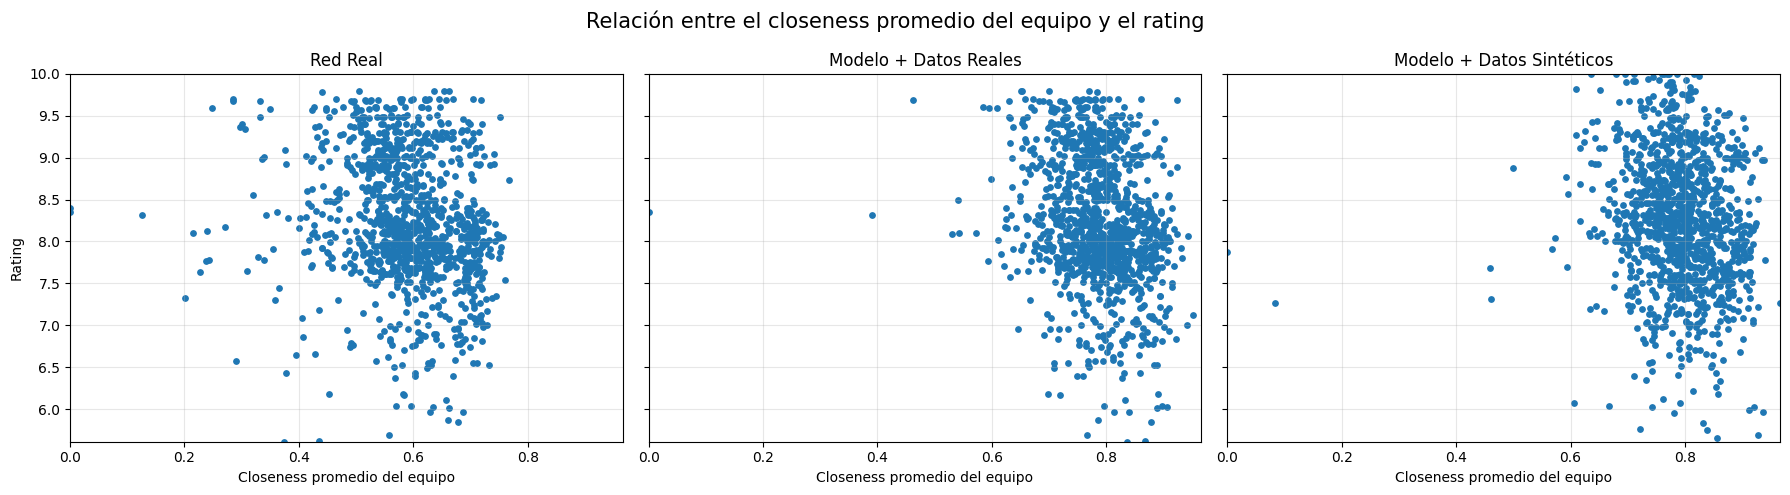

In [120]:
# Datos
y_real = df["rating"].to_list()
y_syn = list(ratings.values())

# Límites comunes
x_min = min(
    np.min(avg_previous_tm_closeness_list),
    np.min(avg_previous_tm_closeness_list_syn),
    np.min(avg_previous_tm_closeness_list_syn_rl)
)

x_max = max(
    np.max(avg_previous_tm_closeness_list),
    np.max(avg_previous_tm_closeness_list_syn),
    np.max(avg_previous_tm_closeness_list_syn_rl)
)

y_min = min(np.min(y_real), np.min(y_syn))
y_max = max(np.max(y_real), np.max(y_syn))

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(avg_previous_tm_closeness_list, y_real, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Closeness promedio del equipo")
axs[0].set_ylabel("Rating")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(avg_previous_tm_closeness_list_syn_rl, y_real, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Closeness promedio del equipo")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(avg_previous_tm_closeness_list_syn, y_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Closeness promedio del equipo")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Relación entre el closeness promedio del equipo y el rating",
    fontsize=15
)

plt.tight_layout()
plt.show()

# TM Betweenness vs Rating

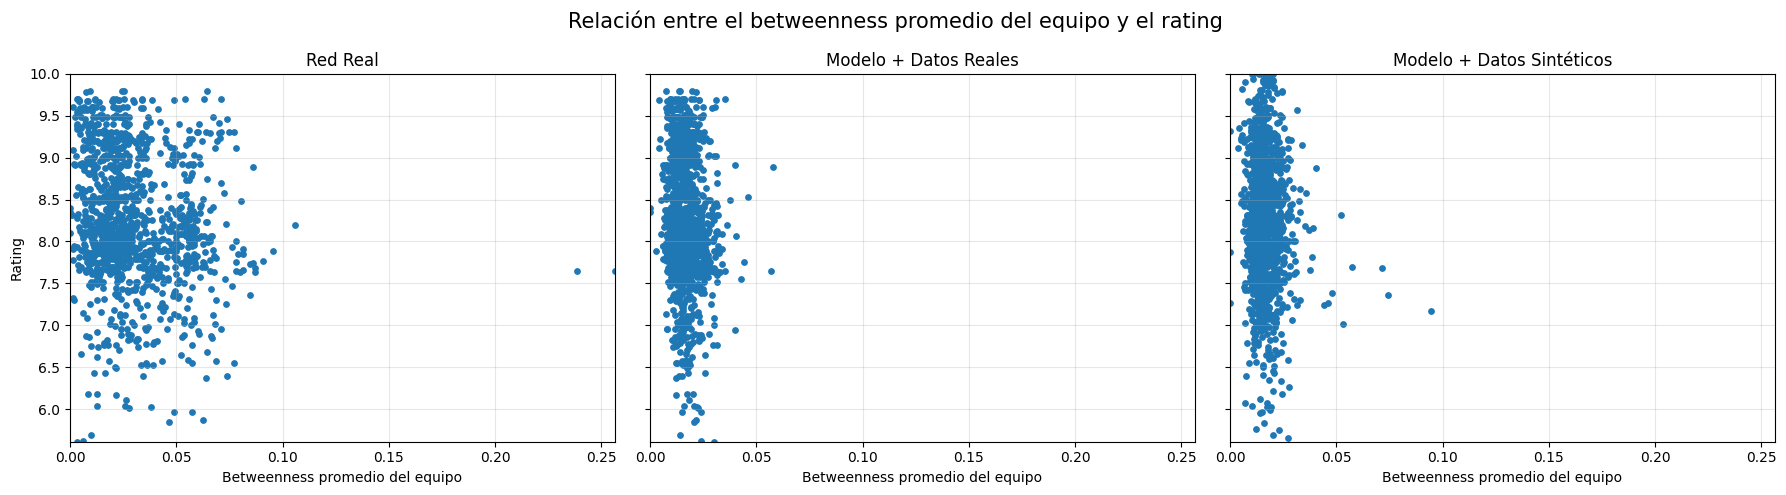

In [121]:
# Datos
y_real = df["rating"].to_list()
y_syn = list(ratings.values())

# Límites comunes
x_min = min(
    np.min(avg_previous_tm_betweenness_list),
    np.min(avg_previous_tm_betweenness_list_syn),
    np.min(avg_previous_tm_betweenness_list_syn_rl)
)

x_max = max(
    np.max(avg_previous_tm_betweenness_list),
    np.max(avg_previous_tm_betweenness_list_syn),
    np.max(avg_previous_tm_betweenness_list_syn_rl)
)

y_min = min(np.min(y_real), np.min(y_syn))
y_max = max(np.max(y_real), np.max(y_syn))

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(avg_previous_tm_betweenness_list, y_real, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Betweenness promedio del equipo")
axs[0].set_ylabel("Rating")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(avg_previous_tm_betweenness_list_syn_rl, y_real, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Betweenness promedio del equipo")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(avg_previous_tm_betweenness_list_syn, y_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Betweenness promedio del equipo")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Relación entre el betweenness promedio del equipo y el rating",
    fontsize=15
)

plt.tight_layout()
plt.show()

# AVG Team Individual Exp vs Rating

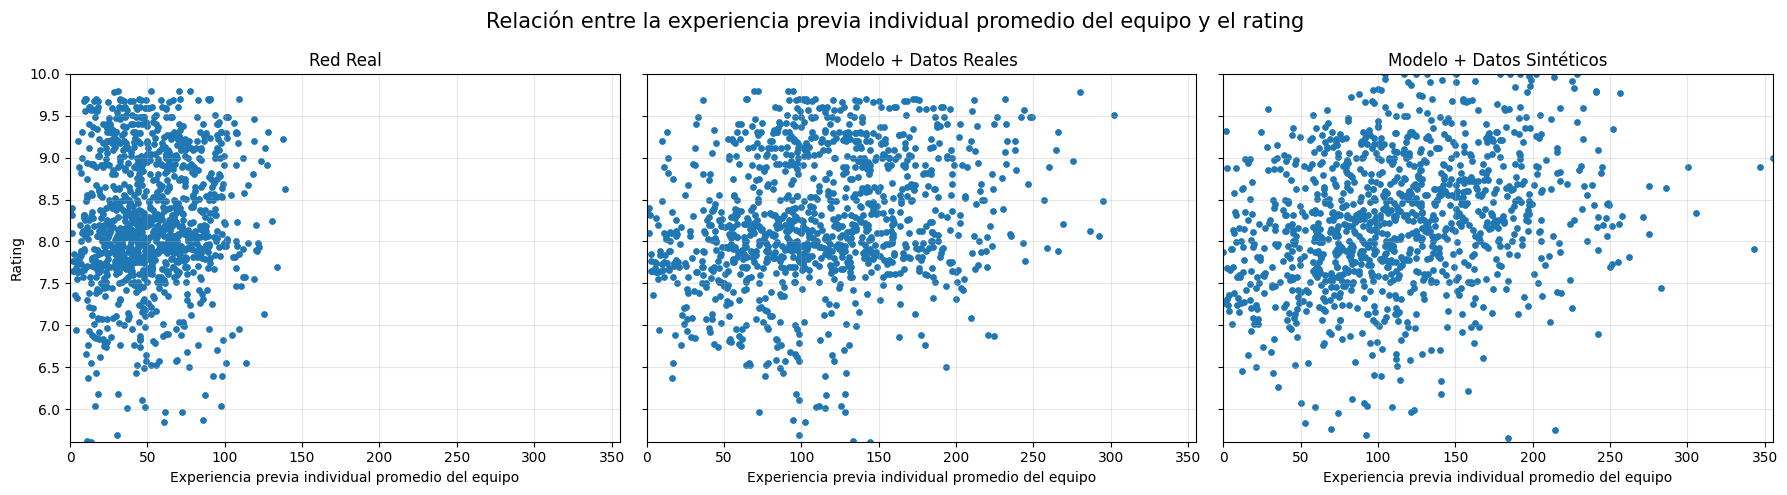

In [122]:
# Datos
y_real = df["rating"].to_list()
y_syn = list(ratings.values())

# Límites comunes
x_min = min(
    np.min(avg_previous_individual_exp_list),
    np.min(avg_previous_individual_exp_list_syn),
    np.min(avg_previous_individual_exp_list_syn_rl)
)

x_max = max(
    np.max(avg_previous_individual_exp_list),
    np.max(avg_previous_individual_exp_list_syn),
    np.max(avg_previous_individual_exp_list_syn_rl)
)

y_min = min(np.min(y_real), np.min(y_syn))
y_max = max(np.max(y_real), np.max(y_syn))

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(avg_previous_individual_exp_list, y_real, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Experiencia previa individual promedio del equipo")
axs[0].set_ylabel("Rating")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(avg_previous_individual_exp_list_syn_rl, y_real, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Experiencia previa individual promedio del equipo")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(avg_previous_individual_exp_list_syn, y_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Experiencia previa individual promedio del equipo")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Relación entre la experiencia previa individual promedio del equipo y el rating",
    fontsize=15
)

plt.tight_layout()
plt.show()

# AVG Team Rating vs Rating

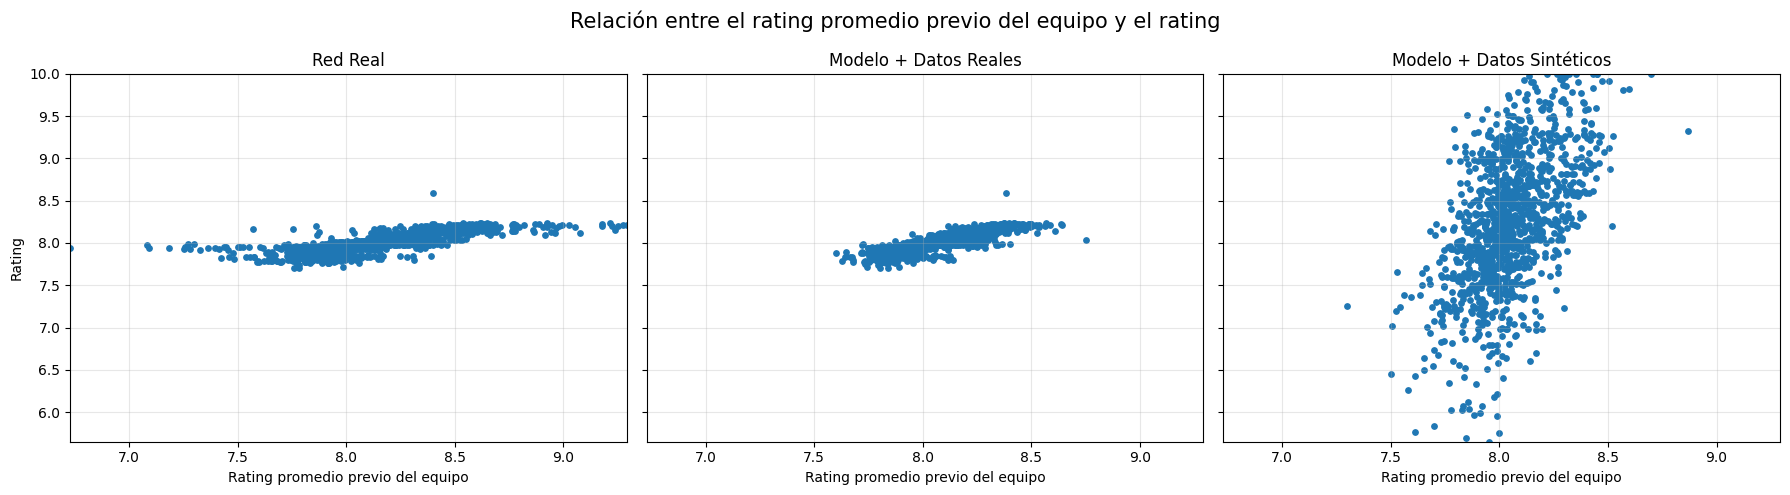

In [123]:
# Datos (se omite el primer episodio)
x_real = avg_previous_team_rating_list[1:]
x_syn = avg_previous_team_rating_list_syn[1:]
x_syn_rl = avg_previous_team_rating_list_syn_rl[1:]

y_real = y[1:]
y_syn = y_syn[1:]

# Límites comunes
x_min = min(
    np.min(x_real),
    np.min(x_syn),
    np.min(x_syn_rl)
)

x_max = max(
    np.max(x_real),
    np.max(x_syn),
    np.max(x_syn_rl)
)

y_min = min(
    np.min(y_real),
    np.min(y_syn)
)

y_max = max(
    np.max(y_real),
    np.max(y_syn)
)

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Red real
axs[0].scatter(x_real, y_real, s=15)
axs[0].set_title("Red Real")
axs[0].set_xlabel("Rating promedio previo del equipo")
axs[0].set_ylabel("Rating")
axs[0].grid(alpha=0.3)

# Modelo + datos reales
axs[1].scatter(x_syn_rl, y_real, s=15)
axs[1].set_title("Modelo + Datos Reales")
axs[1].set_xlabel("Rating promedio previo del equipo")
axs[1].grid(alpha=0.3)

# Modelo + datos sintéticos
axs[2].scatter(x_syn, y_syn, s=15)
axs[2].set_title("Modelo + Datos Sintéticos")
axs[2].set_xlabel("Rating promedio previo del equipo")
axs[2].grid(alpha=0.3)

# Mismos límites para todos
for ax in axs:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

fig.suptitle(
    "Relación entre el rating promedio previo del equipo y el rating",
    fontsize=15
)

plt.tight_layout()
plt.show()